In [9]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gaze_path = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub3\log\predict\gaze.pkl"
gaze_out = pd.read_pickle(gaze_path)

In [15]:
gaze_out

,timestamp,c_eye,r_eye,c_eye2d,r_eye2d,c_pupil,gaze,hor,ver,r_pupil,entpup_el,diameter_3d,location,diameter,confidence,model_confidence,norm_pos
0,50.018706,"[-2.209374719891905, 4.943459846359803, 69.441...",10.392305,"[74.97707390263092, 101.7121285539759]",104.275049,"[1.2983243045430348, 2.637777857539523, 59.934...","[0.33752849599895, -0.22186435281851008, -0.91...",-1.217326,1.794522,1.676616,"[2.6543871208234955, [108.03678305966129, 84.2...",3.353232,"[108.03678305966129, 84.25827504719197]",39.222879,0.994311,1.0,"[0.5746637396790494, 0.2978477079400669, 0.702..."
1,50.023237,"[-2.209374719891905, 4.943459846359803, 69.441...",10.392305,"[74.97707390263092, 101.7121285539759]",104.275049,"[1.2970524186994523, 2.636632627432374, 59.934...","[0.3374061087265882, -0.22197455263695118, -0....",-1.217450,1.794635,1.678415,"[2.6539609356284446, [108.02354286475203, 84.2...",3.356830,"[108.02354286475203, 84.24682703267516]",39.260524,0.994401,1.0,"[0.5745933131103832, 0.2979431080610404, 0.702..."
2,50.027768,"[-2.209374719891905, 4.943459846359803, 69.441...",10.392305,"[74.97707390263092, 101.7121285539759]",104.275049,"[1.2884943878933326, 2.6344256284697787, 59.93...","[0.33658261182831384, -0.2221869212111438, -0....",-1.218332,1.794853,1.678464,"[2.65242926038272, [107.9359475490799, 84.2256...",3.356927,"[107.9359475490799, 84.22568141656971]",39.262090,0.993958,1.0,"[0.5741273805802122, 0.29811932152858567, 0.70..."
3,50.032298,"[-2.209374719891905, 4.943459846359803, 69.441...",10.392305,"[74.97707390263092, 101.7121285539759]",104.275049,"[1.2815148460581303, 2.6424925526987084, 59.92...","[0.33591100510208477, -0.22141068106529296, -0...",-1.219133,1.794057,1.676647,"[2.653581163158394, [107.86536545810681, 84.31...",3.353294,"[107.86536545810681, 84.31008783074384]",39.225296,0.993672,1.0,"[0.5737519439261001, 0.29741593474380135, 0.70..."
4,50.036829,"[-2.209374719891905, 4.943459846359803, 69.441...",10.392305,"[74.97707390263092, 101.7121285539759]",104.275049,"[1.2787414612396968, 2.643486578906847, 59.925...","[0.3356441360235033, -0.2213150308488179, -0.9...",-1.219432,1.793959,1.676811,"[2.6535002243540027, [107.83708219865147, 84.3...",3.353622,"[107.83708219865147, 84.32087565757942]",39.229036,0.993932,1.0,"[0.5736015010566567, 0.29732603618683817, 0.70..."
5,50.041360,"[-2.209374719891905, 4.943459846359803, 69.441...",10.392305,"[74.97707390263092, 101.7121285539759]",104.275049,"[1.2759681623958787, 2.644884390591309, 59.924...","[0.335377275217833, -0.22118052635676785, -0.9...",-1.219735,1.793821,1.678391,"[2.6535174312331855, [107.8086978486936, 84.33...",3.356782,"[107.8086978486936, 84.33592626001149]",39.262438,0.993594,1.0,"[0.5734505204717745, 0.2972006144999042, 0.702..."
6,50.045890,"[-2.209374719891905, 4.943459846359803, 69.441...",10.392305,"[74.97707390263092, 101.7121285539759]",104.275049,"[1.2702497144152325, 2.6421702521558097, 59.92...","[0.3348270173043375, -0.22144169444949338, -0....",-1.220314,1.794089,1.677997,"[2.652184718526244, [107.75011380061443, 84.30...",3.355994,"[107.75011380061443, 84.30897314196568]",39.254461,0.995133,1.0,"[0.5731389031947576, 0.2974252238169527, 0.702..."
7,50.050421,"[-2.209374719891905, 4.943459846359803, 69.441...",10.392305,"[74.97707390263092, 101.7121285539759]",104.275049,"[1.2636717136858642, 2.643817463874503, 59.920...","[0.3341940488890325, -0.22128319142796007, -0....",-1.221018,1.793926,1.675052,"[2.6518163725772643, [107.68328101776542, 84.3...",3.350105,"[107.68328101776542, 84.3269951058947]",39.193526,0.996337,1.0,"[0.572783409668965, 0.29727504078421085, 0.702..."
8,50.054952,"[-2.209374719891905, 4.943459846359803, 69.441...",10.392305,"[74.97707390263092, 101.7121285539759]",104.275049,"[1.2594264671237476, 2.6430401280017897, 59.91...","[0.3337855498481301, -0.22135799060718703, -0....",-1.221458,1.794003,1.676429,"[2.651125733040256, [107.63972126553018, 84.31...",3.352858,"[107.63972126553018, 84.31986410072165]",39.222612

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def interpolate_nan(data):
    """Interpolate NaN values in a 1D array."""
    nans = np.isnan(data)
    if np.any(nans):
        not_nan = ~nans
        data[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(not_nan), data[not_nan])
    return data

from scipy.ndimage import uniform_filter1d
def smooth_with_window(data, win_size):
    """Apply moving average smoothing with a fixed output size."""
    win_size = int(win_size)
    if win_size < 1:
        return data  # return original if window is too small
    return uniform_filter1d(data, size=win_size, mode='nearest')

def bandpass_filter(fs, lowcut, highcut, order, input_signal):
    """Apply Butterworth bandpass filter to retain key torsional frequencies."""
    nyq = 0.5 * fs
    low, high = lowcut / nyq, highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, input_signal)

def clean_signal(signal_raw, fps, drift_removal=True, drift_window=10, lowcut=0.1, highcut=2.0, order=4):
    """
    Full torsion signal cleaning pipeline:
    - NaN interpolation
    - drift removal (moving average)
    - bandpass filtering
    """
    signal_interp = interpolate_nan(np.asarray(signal_raw, dtype=float).copy())

    if drift_removal:
        drift = smooth_with_window(signal_interp, win_size=int(fps * drift_window))
        signal_detrended = signal_interp - drift
    else:
        signal_detrended = signal_interp

    # bandpass filter ALWAYS applied
    nyq = 0.5 * fps
    low, high = lowcut / nyq, highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    cleaned = signal.filtfilt(b, a, signal_detrended)

    return cleaned

# def compute_SPV(gaze, fs, fc=30):   #Fs is sampling frequency, fc is cutoff frequency
#     x = gaze.copy()
#     x[(x > np.nanquantile(x, 0.985)) | (x < np.nanquantile(x, 0.025))] = np.nan
#     if np.sum(np.isnan(x))/len(x) > 0.8: return x, np.nan   #more than 80% of the data is NaN
#     else:
#         v = np.gradient(interpolate_nans(x), edge_order=2) * fs
#         vf = gaussian_filter1d(v, sigma=fs / (2 * np.pi * fc), mode='nearest')
#         vf[np.abs(np.gradient(vf, edge_order=2) * fs) > 700] = np.nan
#         vf = interpolate_nans(vf)
#         win = int(0.5 * fs)
#         if win % 2 == 0: win += 1
#         v_med = medfilt(vf, kernel_size=win)
#     return v_med, np.nanmedian(v_med)


torsion_path = r"D:\jzhao\DeepVOG-project\video_test\from_ZUMUTU\predict_results\torsion.pkl"
torsion_out = pd.read_pickle(torsion_path)
torsion_out = np.array(torsion_out)

In [ ]:
import cv2

video_path = r"D:\jzhao\DeepVOG-project\video_test\from_ZUMUTU\MVS_SMP_test-Left.avi"

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"FPS: {fps}")
print(f"Total frames: {frame_count}")
print(f"Duration (sec): {frame_count / fps if fps > 0 else 'unknown'}")

FPS: 150.22
Total frames: 29116
Duration (sec): 193.82239382239382


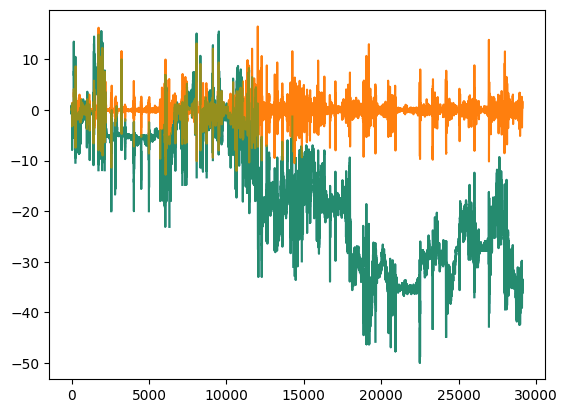

In [34]:
plt.plot(torsion_out)
fs = fps
torsion_clean = clean_signal(torsion_out, fps= fs, drift_removal=True, drift_window=20, lowcut=2, highcut=20.0, order=4)
plt.plot(torsion_clean, label='Filtered Torsion Signal')
plt.plot(torsion_out, label='Raw Torsion Signal', alpha=0.5)

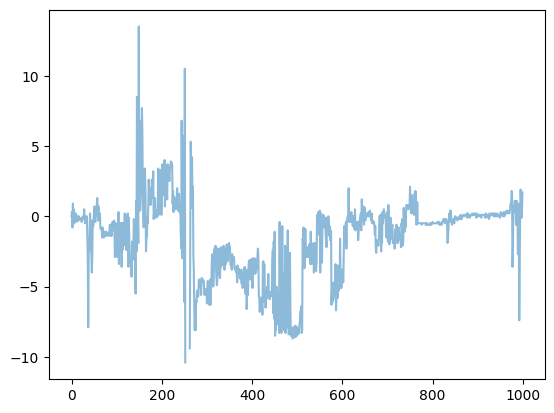

In [18]:
plt.plot(torsion_out[:1000], label='Raw Torsion Signal', alpha=0.5)

In [25]:
gaze_path = r"D:\jzhao\DeepVOG-project\video_test\from_ZUMUTU\predict_results\gaze.pkl"
df_gaze_out = pd.read_pickle(gaze_path)
# torsion_out = np.array(torsion_out)

In [40]:
blink_ix = np.array(df_gaze_out['confidence'])<0.97

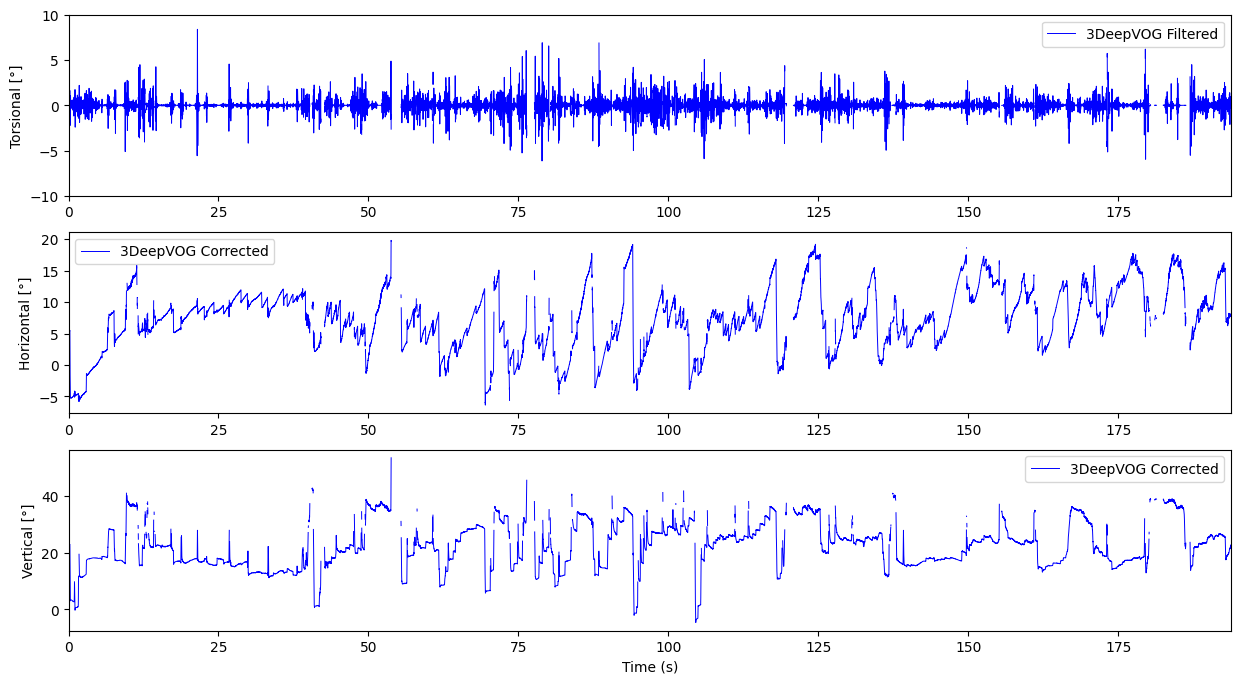

In [56]:
from scipy.optimize import minimize
def cart2sph_batch_PL(N, eps=1e-8):
    N /= np.where((norms := np.linalg.norm(N, axis=0, keepdims=True)) < eps, 1.0, norms)
    phi = np.arctan2(N[2], N[0]) + np.pi / 2
    theta = np.arccos(N[1]) - np.pi / 2
    return -np.rad2deg(phi), np.rad2deg(theta)

def opt_transform_v2(df_GT, normals, conf, thr_confidence=0.96, default_M = np.eye(3), opt_flag = True):
    GT_x, GT_y = np.rad2deg(df_GT.hor), -np.rad2deg(df_GT.ver)
    GT_x = GT_x - np.nanmean(GT_x)
    GT_y = GT_y - np.nanmean(GT_y)
    pred_full = np.full_like(GT_x, np.nan)
    pred_y_full = np.full_like(GT_y, np.nan)

    valid = ~np.isnan(GT_x) & ~np.isnan(GT_y) & ~np.isnan(normals).any(0)
    GT_x, GT_y, normals, conf = GT_x[valid], GT_y[valid], normals[:, valid], conf[valid]

    def loss(params):
        M = params.reshape(3, 3)
        pred_x, pred_y = cart2sph_batch_PL(M @ normals)
        pred_x[conf < thr_confidence] = np.nan
        pred_y[conf < thr_confidence] = np.nan
        pred_x -= np.nanmean(pred_x)
        pred_y -= np.nanmean(pred_y)
        err_x = np.abs(pred_x - GT_x)
        err_y = np.abs(pred_y - GT_y)
        # err_x, err_y = extract_range(np.abs(pred_x - GT_x), np.abs(pred_y - GT_y), mov_ranges)
        return np.nanmedian(err_x) + np.nanmedian(err_y)
    
    if opt_flag:
        res = minimize(loss, default_M.flatten(), method='L-BFGS-B')
        M_opt = res.x.reshape(3, 3)
    else:
        M_opt = default_M

    pred = M_opt @ normals
    fx, fy = np.zeros_like(GT_x), np.zeros_like(GT_y)
    fx[:], fy[:] = cart2sph_batch_PL(pred)
    fx[conf < thr_confidence] = np.nan
    fy[conf < thr_confidence] = np.nan
    fx -= np.nanmean(fx)
    fy -= np.nanmean(fy)
    # Insert predictions into full-length arrays
    pred_full[valid] = fx
    pred_y_full[valid] = fy
    return pred_full, pred_y_full, M_opt

# df_gaze_GT = pd.read_csv(r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub3\trial.csv")
# GT_x, GT_y = np.rad2deg(df_gaze_GT.hor), -np.rad2deg(df_gaze_GT.ver)
# GT_x = GT_x - np.nanmean(GT_x)
# GT_y = GT_y - np.nanmean(GT_y)
# fs = 220.717424
# frame_time = np.arange(len(GT_x)) / fs
frame_time = np.arange(len(torsion_out)) / fs

# df_gaze_out = df_gaze_out.loc[:len(GT_x)-1, :]
normals = np.array([row['normal'] for row in df_gaze_out['circle_3d']]).T
final_x, final_y = cart2sph_batch_PL(normals)
final_x[blink_ix]  = np.nan
final_y[blink_ix]  = np.nan


# gaze_x, gaze_y = gaze_extract_LG(df_gaze_out)
# normals = df_gaze_out.loc[:, ['pupil_3D_norm_x', 'pupil_3D_norm_y', 'pupil_3D_norm_z']].values.T
# conf = df_gaze_out.loc[:, 'confidence'].values
# final_x, final_y, opt_M = opt_transform_v2(df_gaze_GT, normals, conf, thr_confidence=0.96, default_M=np.eye(3), opt_flag=True)

plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
clean_torsion = clean_signal(torsion_out, fps= fs, drift_removal=True, drift_window=20, lowcut=5, highcut=20.0, order=4)
clean_torsion[blink_ix] = np.nan
# plt.plot(frame_time, torsion_out[:len(frame_time)], label='3DeepVOG Raw', alpha=0.5, linewidth=0.7)
plt.plot(frame_time, clean_torsion[:len(frame_time)], label='3DeepVOG Filtered', linewidth=0.7, color='blue')
# plt.xlabel('Time (s)')
plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.ylabel('Torsional [°]')
plt.legend()

plt.subplot(3, 1, 2)
# plt.plot(frame_time, df_gaze_out.model_confidence * 10)
# ax_hor.axvspan(start_f, end_f, color='gray', alpha=0.3)
# plt.plot(frame_time, gaze_x[:len(frame_time)], label='Predicted')
# plt.plot(frame_time, GT_x[:len(frame_time)], label='EyeSeeCam', linewidth=0.7, color='red')
plt.plot(frame_time, final_x[:len(frame_time)], label='3DeepVOG Corrected', linewidth=0.7, color='blue')
# plt.xlabel('Time (s)')
plt.ylabel('Horizontal [°]')
# plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.legend()

plt.subplot(3, 1, 3)
# plt.plot(frame_time, df_gaze_out.model_confidence * 10)
# plt.plot(frame_time, gaze_y[:len(frame_time)], label='Predicted')
# plt.plot(frame_time, -GT_y[:len(frame_time)], label='EyeSeeCam', linewidth=0.7, color='red')
plt.plot(frame_time, -final_y[:len(frame_time)], label='3DeepVOG Corrected', linewidth=0.7, color='blue')
plt.xlabel('Time (s)')
plt.ylabel('Vertical [°]')
# plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.legend()

plt.savefig(r"C:\Users\jzhao\Downloads\patient_ex3_torsion.pdf", format='pdf')

In [50]:
(len(clean_torsion)/fs)/60

3.2303732303732304

In [58]:
import numpy as np
from scipy.signal import savgol_filter

def hampel_filter(x, window_size=15, n_sigmas=3.0):
    """Replace impulse outliers using Hampel filter (median + MAD)."""
    x = np.asarray(x, dtype=float).copy()
    n = len(x)
    k = window_size // 2
    for i in range(n):
        i0, i1 = max(0, i-k), min(n, i+k+1)
        w = x[i0:i1]
        w = w[~np.isnan(w)]
        if w.size < 5:
            continue
        med = np.median(w)
        mad = np.median(np.abs(w - med)) + 1e-12
        sigma = 1.4826 * mad
        if np.abs(x[i] - med) > n_sigmas * sigma:
            x[i] = med
    return x

def smooth_torsion(x, fs, hampel_win_sec=0.15, sg_win_sec=0.25, sg_poly=3):
    x = np.asarray(x, dtype=float).copy()

    # 1) remove impulses
    hampel_win = max(5, int(round(hampel_win_sec * fs)) | 1)  # odd
    x1 = hampel_filter(x, window_size=hampel_win, n_sigmas=3.0)

    # 2) smooth
    sg_win = max(5, int(round(sg_win_sec * fs)) | 1)          # odd
    x2 = savgol_filter(x1, window_length=sg_win, polyorder=sg_poly, mode="interp")

    return x2

In [63]:
import numpy as np
from scipy.signal import butter, filtfilt

def hampel_filter(x, win, n_sigmas=3.0):
    """Hampel filter removes impulse spikes."""
    x = np.asarray(x, float).copy()
    n = len(x)
    k = win // 2
    for i in range(n):
        i0, i1 = max(0, i-k), min(n, i+k+1)
        w = x[i0:i1]
        w = w[~np.isnan(w)]
        if w.size < 5:
            continue
        med = np.median(w)
        mad = np.median(np.abs(w - med)) + 1e-12
        sigma = 1.4826 * mad
        if np.abs(x[i] - med) > n_sigmas * sigma:
            x[i] = med
    return x

def interp_nan_1d(x, fill_ends=False):
    x = np.asarray(x, float).copy()
    n = len(x)
    nans = np.isnan(x)
    if not nans.any():
        return x
    good = ~nans
    if good.sum() < 2:
        return x
    idx = np.arange(n)
    left = x[good][0] if fill_ends else np.nan
    right = x[good][-1] if fill_ends else np.nan
    x[nans] = np.interp(idx[nans], idx[good], x[good], left=left, right=right)
    return x

def lowpass(x, fs, cutoff_hz=3.0, order=2):
    x = np.asarray(x, float)
    b, a = butter(order, cutoff_hz/(0.5*fs), btype="low")
    return filtfilt(b, a, x)

def smooth_torsion_robust(x_deg, fs, blink_ix=None,
                          hampel_win_sec=0.20,
                          step_thr_deg=2.0,
                          cutoff_hz=3.0):
    """
    1) remove impulse spikes (Hampel)
    2) mask step-jumps using derivative threshold
    3) interpolate (optionally) and low-pass
    """
    x = np.asarray(x_deg, float).copy()
    if blink_ix is not None:
        x[blink_ix] = np.nan

    # (1) Hampel for impulses
    win = max(5, int(round(hampel_win_sec * fs)) | 1)
    x1 = hampel_filter(x, win=win, n_sigmas=3.0)

    # (2) mask step jumps via derivative threshold (deg/frame)
    dx = np.abs(np.diff(x1, prepend=x1[0]))
    bad_steps = dx > step_thr_deg
    x1[bad_steps] = np.nan

    # Interpolate NaNs for filtering; keep ends as NaN if you want
    x2 = interp_nan_1d(x1, fill_ends=False)

    # (3) low-pass for jitter
    # If ends are NaN, fill them temporarily for filtfilt stability
    x2_f = x2.copy()
    if np.isnan(x2_f[0]):
        first = np.flatnonzero(~np.isnan(x2_f))
        if first.size:
            x2_f[:first[0]] = x2_f[first[0]]
    if np.isnan(x2_f[-1]):
        last = np.flatnonzero(~np.isnan(x2_f))
        if last.size:
            x2_f[last[-1]+1:] = x2_f[last[-1]]

    x3 = lowpass(x2_f, fs, cutoff_hz=cutoff_hz, order=2)

    # restore blink NaNs if desired
    if blink_ix is not None:
        x3[blink_ix] = np.nan

    return x3

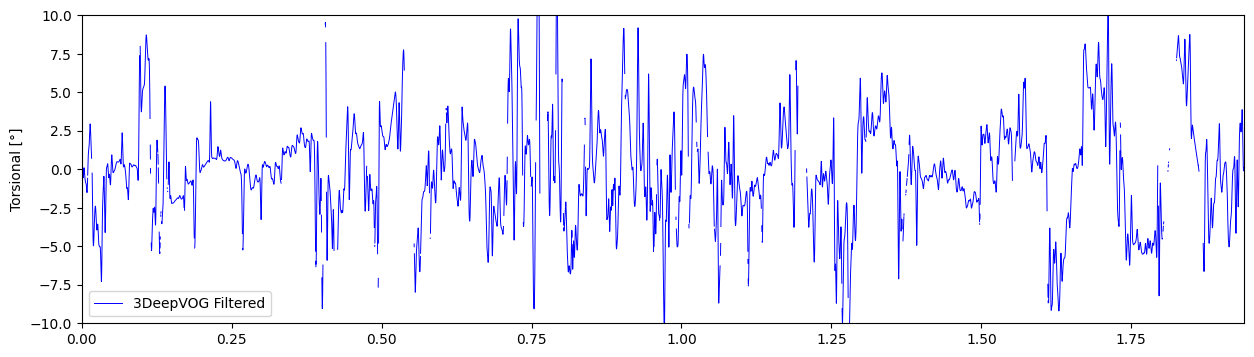

In [65]:
# Don't use 5–20 Hz if you want smooth torsion.
# Use a low-pass like 2–5 Hz.
clean_torsion = clean_signal(torsion_out, fps=fs, drift_removal=True,
                             drift_window=20, lowcut=0.05, highcut=5.0, order=4)

torsion_smooth = smooth_torsion_robust(clean_torsion, fs,
                                       blink_ix=blink_ix,
                                       hampel_win_sec=0.15,
                                       step_thr_deg=1.5,   # tune
                                       cutoff_hz=3.0)      # tune

plt.figure(figsize=(15, 4))
frame_time = (np.arange(len(torsion_out)) / fs)/100
plt.plot(frame_time, torsion_smooth[:len(frame_time)], label='3DeepVOG Filtered', linewidth=0.7, color='blue')
# plt.xlabel('Time (s)')
plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.ylabel('Torsional [°]')
plt.legend()

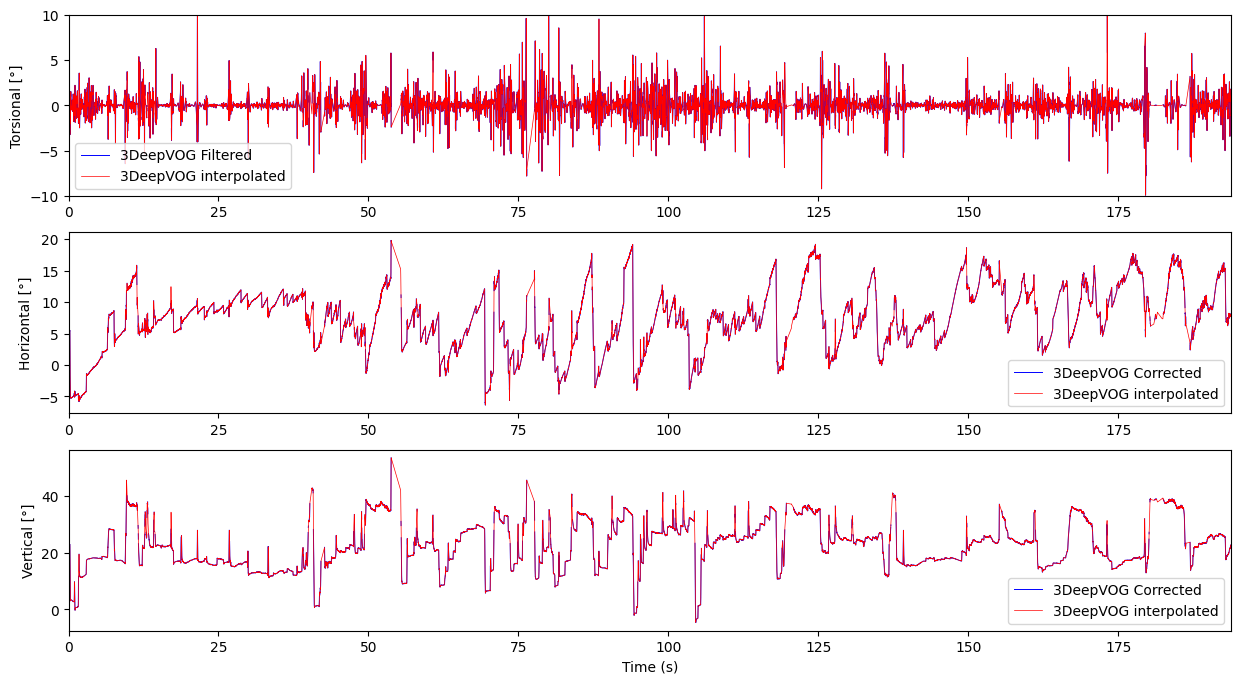

In [43]:
import numpy as np

def interp_nan_1d(x, fill_ends=True):
    x = np.asarray(x, dtype=float).copy()
    n = x.size
    if n == 0:
        return x

    nans = np.isnan(x)
    if not nans.any():
        return x

    idx = np.arange(n)
    good = ~nans
    if good.sum() < 2:
        return x  # not enough points to interpolate

    left = x[good][0] if fill_ends else np.nan
    right = x[good][-1] if fill_ends else np.nan

    x[nans] = np.interp(idx[nans], idx[good], x[good], left=left, right=right)
    return x

final_x_i = interp_nan_1d(final_x)
final_y_i = interp_nan_1d(final_y)
torsion_i = interp_nan_1d(clean_torsion)


plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
# plt.plot(frame_time, torsion_out[:len(frame_time)], label='3DeepVOG Raw', alpha=0.5, linewidth=0.7)
plt.plot(frame_time, clean_torsion[:len(frame_time)], label='3DeepVOG Filtered', linewidth=0.7, color='blue')
plt.plot(frame_time, torsion_i[:len(frame_time)], label='3DeepVOG interpolated', linewidth=0.5, color='red')
# plt.xlabel('Time (s)')
plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.ylabel('Torsional [°]')
plt.legend()

plt.subplot(3, 1, 2)
# plt.plot(frame_time, df_gaze_out.model_confidence * 10)
# ax_hor.axvspan(start_f, end_f, color='gray', alpha=0.3)
# plt.plot(frame_time, gaze_x[:len(frame_time)], label='Predicted')
# plt.plot(frame_time, GT_x[:len(frame_time)], label='EyeSeeCam', linewidth=0.7, color='red')
plt.plot(frame_time, final_x[:len(frame_time)], label='3DeepVOG Corrected', linewidth=0.7, color='blue')
plt.plot(frame_time, final_x_i[:len(frame_time)], label='3DeepVOG interpolated', linewidth=0.5, color='red')
# plt.xlabel('Time (s)')
plt.ylabel('Horizontal [°]')
# plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.legend()

plt.subplot(3, 1, 3)
# plt.plot(frame_time, df_gaze_out.model_confidence * 10)
# plt.plot(frame_time, gaze_y[:len(frame_time)], label='Predicted')
# plt.plot(frame_time, -GT_y[:len(frame_time)], label='EyeSeeCam', linewidth=0.7, color='red')
plt.plot(frame_time, -final_y[:len(frame_time)], label='3DeepVOG Corrected', linewidth=0.7, color='blue')
plt.plot(frame_time, -final_y_i[:len(frame_time)], label='3DeepVOG interpolated', linewidth=0.5, color='red')
plt.xlabel('Time (s)')
plt.ylabel('Vertical [°]')
# plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.legend()

plt.savefig(r"C:\Users\jzhao\Downloads\patient_ex3_torsion.pdf", format='pdf')

In [24]:
df_gaze_out

NameError: name 'df_gaze_out' is not defined

In [ ]:
'''
This script processes the datasetC videos to estimate gaze vectors using the three gaze estimation models:
 Pupil Labs, DeepVOG, and Legacy code from DeepVOG project.
The script processes the videos sequentially and saves the gaze vectors
and the frames per second (fps) of each model in a pickle file.

author: Jingkang Zhao
date: 22/12/2024
'''

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
import pandas as pd

from pye3d.detector_3d import CameraModel, Detector3D, DetectorMode
from pupil_detectors import Detector2D
from tqdm import tqdm
import time
from pye3d.detector_3d import CameraModel, Detector3D, DetectorMode
from pupil_detectors import Detector2D
from concurrent.futures import ThreadPoolExecutor, as_completed
from .utils.gaze_process import gaze_extract_LG, gaze_extract_PL, gaze_extract_GT, gaze_comp_vis, cut_unstable_period
from .utils.read_and_save import get_video_info, save_pkl

In [6]:
from fast_deepvog3D.model3D.segmentation_model import AttentionUnet_3in3out_model, Unet_3in4out_model
from utils.read_and_save import get_video_info_cv2
from deepvog_processer import deepvog_processer
  
# def deepvog_info_generator(set_param, sample_vid, calib_vid):
#     # sample_vid = torsion_sample_vid
#     root_path = os.path.dirname(sample_vid)
#     print("Root Path:", root_path)
#     df_ellipses, df_gaze_out, seg_roi_all, torsion_out, current_iris_imgs_out, template_iris_imgs_out, params \
#         = deepvog_processer(calib_vid = calib_vid, ff_vid = sample_vid, eyeball_path = [], set_param = set_param, mode = 'predict')
#     return df_ellipses, df_gaze_out, params


### Estimate gaze and save it for each subject and each video type

In [8]:
deepPL_flag = True
# PL_flag = False
# LG_flag = True

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

ff_vid = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\w00001p48065u001s001e010c001m002.avi"
calib_vid = ff_vid
set_param = {
    'is_parallel': True,   #True: multithread, False: single thread (sequential)
    'device': device,   #default is gpu if available
    'segmentation_model': None,
    # 'segmentation_model': AttentionUnet_3in3out_model(),
    'segmentation_model_weights_path': None,
    'extract_segment_map': False,
    'do_gaze_tracking': True,
    'eyeball_model': 'PL', #simple or LeGrand or PL
    'do_torsion_tracking': True,
    'torsion_collecte_detail': False,
    'focal_length': 16,  # mm
    'viz_segmentation': False,
    'viz_gaze': False,
    'viz_torsion': False
}

# eyeball_path = os.path.join(save_path, f'{calib_vid_name}_EyeModel.json')
df_ellipses, df_gaze_out, seg_roi_all, torsion_out, current_iris_imgs_out, template_iris_imgs_out, params \
    = deepvog_processer(calib_vid = calib_vid, ff_vid = ff_vid, eyeball_path = [], set_param = set_param, mode = 'predict')
# df_ellipses, df_gaze_out, params = deepvog_info_generator(set_param, ff_vid, calib_vid)

df_gaze_out.to_csv(ff_vid.replace('.avi', '_gaze.csv'), index=False)
np.save(ff_vid.replace('.avi', '_torsion.npy'), torsion_out)
save_pkl(ff_vid.replace('.avi', '_params.pkl'), params)
# save_pkl(os.path.join(save_path, f"{calib_vid_name}_params.pkl"), params)
# torch.cuda.empty_cache()  # Free GPU memory
torch.cuda.synchronize()  # Ensure all operations complete





**********  STARTING VIDEO **********
D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\w00001p48065u001s001e010c001m002.avi
*************************************

Prediction Mode
Device: cuda
OS: Windows
Running in parallel (multithread) mode
Video info: 240x376, 120.818326 fps, 6462 frames.


Processing Frames: 100%|██████████| 6462/6462 [00:20<00:00, 311.35frame/s]


Closing thread: model_inference (avg/frame: 1416.16 fps)
Closing thread: post_processing (avg/frame: 241.84 fps)
Closing thread: ellipse_fitting (avg/frame: 711.32 fps)
Closing thread: gaze_tracker (avg/frame: 1218.68 fps)
Closing thread: torsion_tracker (avg/frame: 289.18 fps)
torsion_tracker detail: Polar Transform (avg/frame: 341.08 fps)
torsion_tracker detail: Template Matching (avg/frame: 2106.74 fps)
Elapsed time total: 28.05 sec. (avg/frame: 0.004 sec = 230.36 fps.)


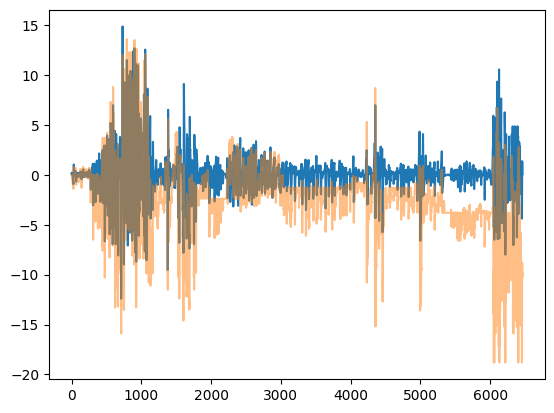

In [64]:
fs = 120.818326
plt.plot(clean_signal(torsion_out, fps= fs, drift_removal=True, drift_window=20, lowcut=2, highcut=20.0, order=4), label='Filtered Torsion Signal')
plt.plot(torsion_out, label='Raw Torsion Signal', alpha=0.5)

In [6]:
ff_vid = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\w00001p48065u001s001e010c001m001.avi"
calib_vid = ff_vid
df_ellipses, df_gaze_out, seg_roi_all, torsion_out, current_iris_imgs_out, template_iris_imgs_out, params \
    = deepvog_processer(calib_vid = calib_vid, ff_vid = ff_vid, eyeball_path = [], set_param = set_param, mode = 'predict')
torch.cuda.synchronize()  # Ensure all operations complete
df_gaze_out.to_csv(ff_vid.replace('.avi', '_gaze.csv'), index=False)
np.save(ff_vid.replace('.avi', '_torsion.npy'), torsion_out)
save_pkl(ff_vid.replace('.avi', '_params.pkl'), params)




**********  STARTING VIDEO **********
D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\w00001p48065u001s001e010c001m001.avi
*************************************

Prediction Mode
Device: cuda
OS: Windows
Running in parallel (multithread) mode
Video info: 240x376, 120.818326 fps, 3222 frames.


Processing Frames: 100%|██████████| 3222/3222 [00:03<00:00, 810.45frame/s] 


Closing thread: model_inference (avg/frame: 1138.04 fps)
Closing thread: post_processing (avg/frame: 310.73 fps)
Closing thread: ellipse_fitting (avg/frame: 1021.46 fps)
Closing thread: gaze_tracker (avg/frame: 889.92 fps)
Closing thread: torsion_tracker (avg/frame: 261.79 fps)
torsion_tracker detail: Polar Transform (avg/frame: 297.76 fps)
torsion_tracker detail: Template Matching (avg/frame: 2482.79 fps)
Elapsed time total: 12.49 sec. (avg/frame: 0.004 sec = 258.04 fps.)


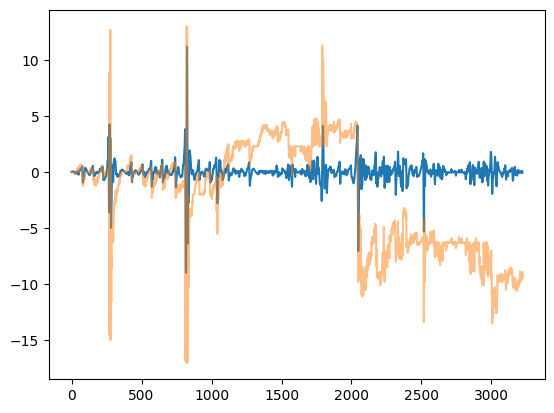

In [66]:
fs = 120.818326
plt.plot(clean_signal(torsion_out, fps= fs, drift_removal=True, drift_window=20, lowcut=2, highcut=20.0, order=4), label='Filtered Torsion Signal')
plt.plot(torsion_out, label='Raw Torsion Signal', alpha=0.5)

In [9]:
ff_vid = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub3\p00294s001e004c001t003.avi"

calib_vid = ff_vid
# df_ellipses, df_gaze_out, seg_roi_all, torsion_out, current_iris_imgs_out, template_iris_imgs_out, params \
#     = deepvog_processer(calib_vid = calib_vid, ff_vid = ff_vid, eyeball_path = [], set_param = set_param, mode = 'predict')
# torch.cuda.synchronize()  # Ensure all operations complete
set_param = {
    'is_parallel': True,   #True: multithread, False: single thread (sequential)
    'device': device,   #default is gpu if available
    'segmentation_model': None,
    # 'segmentation_model': AttentionUnet_3in3out_model(),
    'segmentation_model_weights_path': None,
    'extract_segment_map': False,
    'do_gaze_tracking': True,
    'eyeball_model': 'simple', #simple or LeGrand or PL
    'do_torsion_tracking': True,
    'torsion_collecte_detail': False,
    'focal_length': 16,  # mm
    'viz_segmentation': False,
    'viz_gaze': False,
    'viz_torsion': False
}

eyeball_path = calib_vid.replace('.avi', '_EyeModel.json')
# deepvog_processer(calib_vid = calib_vid, ff_vid = ff_vid, eyeball_path = eyeball_path, set_param = set_param, mode = 'fit')
df_ellipses, df_gaze_out, seg_roi_all, torsion_out, current_iris_imgs_out, template_iris_imgs_out, params \
    = deepvog_processer(calib_vid = calib_vid, ff_vid = ff_vid, eyeball_path = eyeball_path, set_param = set_param, mode = 'predict')




**********  STARTING VIDEO **********
D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub3\p00294s001e004c001t003.avi
*************************************

Fitting Mode: simple Eyeball Model
Device: cuda
OS: Windows
Running in parallel (multithread) mode
Video info: 120x188, 220.717424 fps, 11054 frames.


Processing Frames: 100%|██████████| 11054/11054 [00:10<00:00, 1025.36frame/s]

GPU overloading detected. You should reduce the number of samples to fit.


Closing thread: model_inference (avg/frame: 1427.64 fps)
Closing thread: post_processing (avg/frame: 883.84 fps)
Closing thread: ellipse_fitting (avg/frame: 1264.69 fps)
Elapsed time total: 12.59 sec. (avg/frame: 0.001 sec = 877.91 fps.)



**********  STARTING VIDEO **********
D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub3\p00294s001e004c001t003.avi
*************************************

Prediction Mode
Device: cuda
OS: Windows
Running in parallel (multithread) mode
Video info: 120x188, 220.717424 fps, 11054 frames.


Processing Frames: 100%|██████████| 11054/11054 [00:23<00:00, 468.36frame/s]


Closing thread: model_inference (avg/frame: 1497.86 fps)
Closing thread: post_processing (avg/frame: 889.21 fps)
Closing thread: ellipse_fitting (avg/frame: 1275.20 fps)
Closing thread: gaze_tracker (avg/frame: 961.56 fps)
Closing thread: torsion_tracker (avg/frame: 326.89 fps)
torsion_tracker detail: Polar Transform (avg/frame: 379.61 fps)
torsion_tracker detail: Template Matching (avg/frame: 2685.97 fps)
Elapsed time total: 33.94 sec. (avg/frame: 0.003 sec = 325.71 fps.)


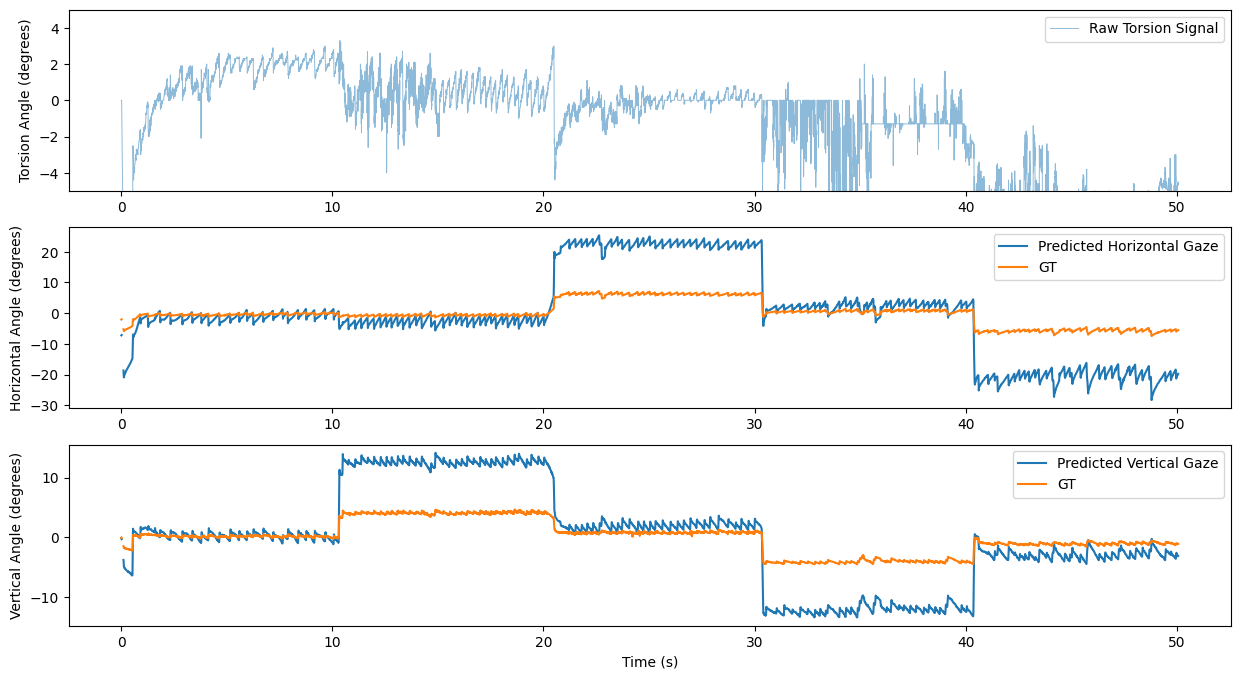

In [12]:
gaze_x, gaze_y = gaze_extract_LG(df_gaze_out)
df_gaze_GT = pd.read_csv(r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub3\trial.csv")
GT_x, GT_y = np.rad2deg(df_gaze_GT.hor), -np.rad2deg(df_gaze_GT.ver)
GT_x = GT_x - np.nanmean(GT_x)
GT_y = GT_y - np.nanmean(GT_y)

fs = 220.717424
frame_time = np.arange(len(GT_x)) / fs

plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
fs = 120.818326
# clean_torsion = clean_signal(torsion_out, fps= fs, drift_removal=True, drift_window=20, lowcut=2, highcut=20.0, order=4)
# plt.plot(frame_time, clean_torsion[:len(frame_time)], label='Filtered Torsion Signal', linewidth=0.7)
plt.plot(frame_time, torsion_out[:len(frame_time)], label='Raw Torsion Signal', alpha=0.5, linewidth=0.7)
# plt.xlabel('Time (s)')
plt.ylim(-5, 5)
plt.ylabel('Torsion Angle (degrees)')
plt.legend()

plt.subplot(3, 1, 2)
# plt.plot(frame_time, df_gaze_out.model_confidence * 10)
# ax_hor.axvspan(start_f, end_f, color='gray', alpha=0.3)
plt.plot(frame_time, gaze_x[:len(frame_time)], label='Predicted Horizontal Gaze')
plt.plot(frame_time, GT_x[:len(frame_time)], label='GT')
# plt.xlabel('Time (s)')
plt.ylabel('Horizontal Angle (degrees)')
plt.legend()

plt.subplot(3, 1, 3)
# plt.plot(frame_time, df_gaze_out.model_confidence * 10)
plt.plot(frame_time, gaze_y[:len(frame_time)], label='Predicted Vertical Gaze')
plt.plot(frame_time, GT_y[:len(frame_time)], label='GT')
plt.xlabel('Time (s)')
plt.ylabel('Vertical Angle (degrees)')
plt.legend()

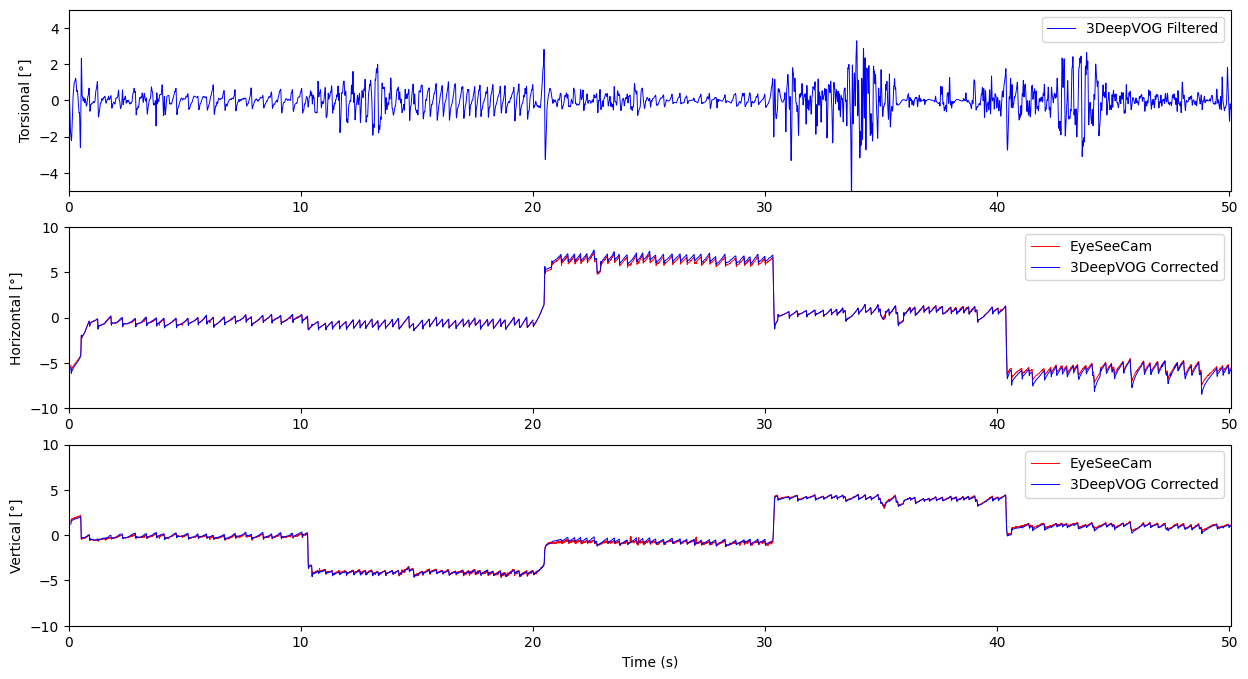

In [15]:

def round_up_to_odd_int(f):
    return int(np.ceil(f) // 2 * 2 + 1)

def interpolate_nan(data):
    """Interpolate NaN values in a 1D array."""
    nans = np.isnan(data)
    if np.any(nans):
        not_nan = ~nans
        data[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(not_nan), data[not_nan])
    return data

from scipy.ndimage import uniform_filter1d
def smooth_with_window(data, win_size):
    """Apply moving average smoothing with a fixed output size."""
    win_size = int(win_size)
    if win_size < 1:
        return data  # return original if window is too small
    return uniform_filter1d(data, size=win_size, mode='nearest')

def clean_signal(signal_raw, fps, drift_removal=True, drift_window=10, lowcut=0.1, highcut=2.0, order=4):
    """
    Full torsion signal cleaning pipeline:
    - NaN interpolation
    - 10s drift removal
    - Bandpass filtering (0.2–2.0 Hz)
    """
    signal_interp = interpolate_nan(signal_raw.copy())
    if drift_removal:
        drift = smooth_with_window(signal_interp, win_size=int(fps * drift_window))
        signal_detrended = signal_interp - drift
    else:
        signal_detrended = signal_interp
    # cleaned = bandpass_filter(fps, lowcut=lowcut, highcut=highcut, order=order, input_signal=signal_detrended)
        """Apply Butterworth bandpass filter to retain key torsional frequencies."""
    nyq = 0.5 * fps
    low, high = lowcut / nyq, highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, signal_detrended)
    # return cleaned

from scipy.optimize import minimize
def cart2sph_batch_PL(N, eps=1e-8):
    N /= np.where((norms := np.linalg.norm(N, axis=0, keepdims=True)) < eps, 1.0, norms)
    phi = np.arctan2(N[2], N[0]) + np.pi / 2
    theta = np.arccos(N[1]) - np.pi / 2
    return -np.rad2deg(phi), np.rad2deg(theta)

def opt_transform_v2(df_GT, normals, conf, thr_confidence=0.96, default_M = np.eye(3), opt_flag = True):
    GT_x, GT_y = np.rad2deg(df_GT.hor), -np.rad2deg(df_GT.ver)
    GT_x = GT_x - np.nanmean(GT_x)
    GT_y = GT_y - np.nanmean(GT_y)
    pred_full = np.full_like(GT_x, np.nan)
    pred_y_full = np.full_like(GT_y, np.nan)

    valid = ~np.isnan(GT_x) & ~np.isnan(GT_y) & ~np.isnan(normals).any(0)
    GT_x, GT_y, normals, conf = GT_x[valid], GT_y[valid], normals[:, valid], conf[valid]

    def loss(params):
        M = params.reshape(3, 3)
        pred_x, pred_y = cart2sph_batch_PL(M @ normals)
        pred_x[conf < thr_confidence] = np.nan
        pred_y[conf < thr_confidence] = np.nan
        pred_x -= np.nanmean(pred_x)
        pred_y -= np.nanmean(pred_y)
        err_x = np.abs(pred_x - GT_x)
        err_y = np.abs(pred_y - GT_y)
        # err_x, err_y = extract_range(np.abs(pred_x - GT_x), np.abs(pred_y - GT_y), mov_ranges)
        return np.nanmedian(err_x) + np.nanmedian(err_y)
    
    if opt_flag:
        res = minimize(loss, default_M.flatten(), method='L-BFGS-B')
        M_opt = res.x.reshape(3, 3)
    else:
        M_opt = default_M

    pred = M_opt @ normals
    fx, fy = np.zeros_like(GT_x), np.zeros_like(GT_y)
    fx[:], fy[:] = cart2sph_batch_PL(pred)
    fx[conf < thr_confidence] = np.nan
    fy[conf < thr_confidence] = np.nan
    fx -= np.nanmean(fx)
    fy -= np.nanmean(fy)
    # Insert predictions into full-length arrays
    pred_full[valid] = fx
    pred_y_full[valid] = fy
    return pred_full, pred_y_full, M_opt

df_gaze_GT = pd.read_csv(r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub3\trial.csv")
GT_x, GT_y = np.rad2deg(df_gaze_GT.hor), -np.rad2deg(df_gaze_GT.ver)
GT_x = GT_x - np.nanmean(GT_x)
GT_y = GT_y - np.nanmean(GT_y)
fs = 220.717424
frame_time = np.arange(len(GT_x)) / fs

df_gaze_out = df_gaze_out.loc[:len(GT_x)-1, :]
gaze_x, gaze_y = gaze_extract_LG(df_gaze_out)
normals = df_gaze_out.loc[:, ['pupil_3D_norm_x', 'pupil_3D_norm_y', 'pupil_3D_norm_z']].values.T
conf = df_gaze_out.loc[:, 'confidence'].values
final_x, final_y, opt_M = opt_transform_v2(df_gaze_GT, normals, conf, thr_confidence=0.96, default_M=np.eye(3), opt_flag=True)

plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
clean_torsion = clean_signal(torsion_out, fps= fs, drift_removal=True, drift_window=20, lowcut=2, highcut=20.0, order=4)
# plt.plot(frame_time, torsion_out[:len(frame_time)], label='3DeepVOG Raw', alpha=0.5, linewidth=0.7)
plt.plot(frame_time, clean_torsion[:len(frame_time)], label='3DeepVOG Filtered', linewidth=0.7, color='blue')
# plt.xlabel('Time (s)')
plt.ylim(-5, 5)
plt.xlim(0, frame_time[-1])
plt.ylabel('Torsional [°]')
plt.legend()

plt.subplot(3, 1, 2)
# plt.plot(frame_time, df_gaze_out.model_confidence * 10)
# ax_hor.axvspan(start_f, end_f, color='gray', alpha=0.3)
# plt.plot(frame_time, gaze_x[:len(frame_time)], label='Predicted')
plt.plot(frame_time, GT_x[:len(frame_time)], label='EyeSeeCam', linewidth=0.7, color='red')
plt.plot(frame_time, final_x[:len(frame_time)], label='3DeepVOG Corrected', linewidth=0.7, color='blue')
# plt.xlabel('Time (s)')
plt.ylabel('Horizontal [°]')
plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.legend()

plt.subplot(3, 1, 3)
# plt.plot(frame_time, df_gaze_out.model_confidence * 10)
# plt.plot(frame_time, gaze_y[:len(frame_time)], label='Predicted')
plt.plot(frame_time, -GT_y[:len(frame_time)], label='EyeSeeCam', linewidth=0.7, color='red')
plt.plot(frame_time, -final_y[:len(frame_time)], label='3DeepVOG Corrected', linewidth=0.7, color='blue')
plt.xlabel('Time (s)')
plt.ylabel('Vertical [°]')
plt.ylim(-10, 10)
plt.xlim(0, frame_time[-1])
plt.legend()

plt.savefig(r"C:\Users\jzhao\Downloads\patient_ex3_torsion.pdf", format='pdf')

In [62]:
df_gaze_out = df_gaze_out.loc[:len(GT_x)-1, :]
len(df_gaze_out), len(GT_x)

(11053, 11053)




**********  STARTING VIDEO **********
D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\w00001p48065u001s002e010c001m001.avi
*************************************

Prediction Mode
Device: cuda
OS: Windows
Running in parallel (multithread) mode
Video info: 240x376, 120.818326 fps, 2808 frames.


Processing Frames: 100%|██████████| 2808/2808 [00:02<00:00, 1024.12frame/s]


Closing thread: model_inference (avg/frame: 1492.12 fps)
Closing thread: post_processing (avg/frame: 319.19 fps)
Closing thread: ellipse_fitting (avg/frame: 985.78 fps)
Closing thread: gaze_tracker (avg/frame: 1068.33 fps)
Closing thread: torsion_tracker (avg/frame: 284.82 fps)
torsion_tracker detail: Polar Transform (avg/frame: 332.50 fps)
torsion_tracker detail: Template Matching (avg/frame: 2283.66 fps)
Elapsed time total: 10.28 sec. (avg/frame: 0.004 sec = 273.09 fps.)


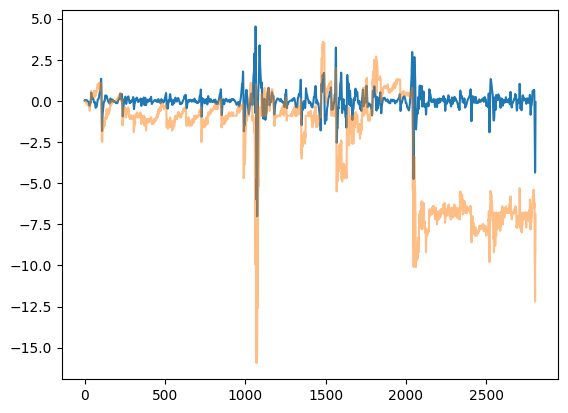

In [ ]:
ff_vid = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\w00001p48065u001s002e010c001m001.avi"

calib_vid = ff_vid
df_ellipses, df_gaze_out, seg_roi_all, torsion_out, current_iris_imgs_out, template_iris_imgs_out, params \
    = deepvog_processer(calib_vid = calib_vid, ff_vid = ff_vid, eyeball_path = [], set_param = set_param, mode = 'predict')
torch.cuda.synchronize()  # Ensure all operations complete

fs = 120.818326
plt.plot(clean_signal(torsion_out, fps= fs, drift_removal=True, drift_window=20, lowcut=2, highcut=20.0, order=4), label='Filtered Torsion Signal')
plt.plot(torsion_out, label='Raw Torsion Signal', alpha=0.5)
df_gaze_out.to_csv(ff_vid.replace('.avi', '_gaze.csv'), index=False)
np.save(ff_vid.replace('.avi', '_torsion.npy'), torsion_out)
save_pkl(ff_vid.replace('.avi', '_params.pkl'), params)

In [ ]:
ff_vid = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\trial.avi"

set_param['do_gaze_tracking'] = True
calib_vid = ff_vid
df_ellipses, df_gaze_out, seg_roi_all, torsion_out, current_iris_imgs_out, template_iris_imgs_out, params \
    = deepvog_processer(calib_vid = calib_vid, ff_vid = ff_vid, eyeball_path = [], set_param = set_param, mode = 'predict')
df_gaze_out.to_csv(ff_vid.replace('.avi', '_gaze.csv'), index=False)
np.save(ff_vid.replace('.avi', '_torsion.npy'), torsion_out)
save_pkl(ff_vid.replace('.avi', '_params.pkl'), params)




**********  STARTING VIDEO **********
D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\trial.avi
*************************************

Prediction Mode
Device: cuda
OS: Windows
Running in parallel (multithread) mode
Video info: 240x376, 120.818326 fps, 35362 frames.


Processing Frames: 100%|██████████| 35362/35362 [02:15<00:00, 261.05frame/s]


Closing thread: model_inference (avg/frame: 2220.75 fps)
Closing thread: post_processing (avg/frame: 247.88 fps)
Closing thread: ellipse_fitting (avg/frame: 993.07 fps)
Closing thread: gaze_tracker (avg/frame: 1590.80 fps)
Closing thread: torsion_tracker (avg/frame: 338.16 fps)
torsion_tracker detail: Polar Transform (avg/frame: 395.99 fps)
torsion_tracker detail: Template Matching (avg/frame: 2632.94 fps)
Elapsed time total: 142.99 sec. (avg/frame: 0.004 sec = 247.31 fps.)


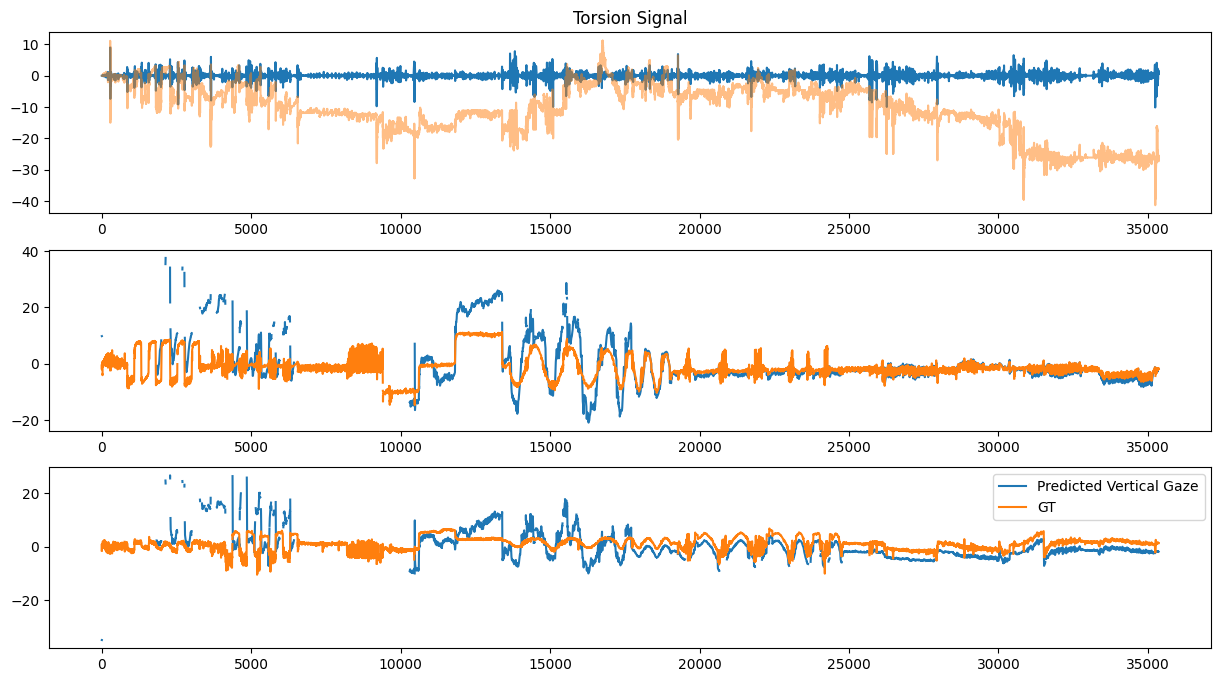

In [69]:
# from utils.gaze_process import gaze_extract_LG, gaze_extract_PL, gaze_extract_GT, gaze_comp_vis, cut_unstable_period
gaze_x, gaze_y = gaze_extract_PL(df_gaze_out)
df_gaze_GT = pd.read_csv(r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\trial.csv")

plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
fs = 120.818326
plt.plot(clean_signal(torsion_out, fps= fs, drift_removal=True, drift_window=20, lowcut=2, highcut=20.0, order=4), label='Filtered Torsion Signal')
plt.plot(torsion_out, label='Raw Torsion Signal', alpha=0.5)
plt.title('Torsion Signal')

plt.subplot(3, 1, 2)
plt.plot(gaze_x, label='Predicted Horizontal Gaze')
plt.plot(np.rad2deg(df_gaze_GT.hor), label='GT')

plt.subplot(3, 1, 3)
plt.plot(gaze_y, label='Predicted Vertical Gaze')
plt.plot(-np.rad2deg(df_gaze_GT.ver), label='GT')
plt.legend()

In [ ]:
ff_vid = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub2\w00001p44858u001s002e010c001m001.avi"

# set_param['do_gaze_tracking'] = False
calib_vid = ff_vid
df_ellipses, df_gaze_out, seg_roi_all, torsion_out, current_iris_imgs_out, template_iris_imgs_out, params \
    = deepvog_processer(calib_vid = calib_vid, ff_vid = ff_vid, eyeball_path = [], set_param = set_param, mode = 'predict')
df_gaze_out.to_csv(ff_vid.replace('.avi', '_gaze.csv'), index=False)
np.save(ff_vid.replace('.avi', '_torsion.npy'), torsion_out)
save_pkl(ff_vid.replace('.avi', '_params.pkl'), params)





**********  STARTING VIDEO **********
D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub2\w00001p44858u001s002e010c001m001.avi
*************************************

Prediction Mode
Device: cuda
OS: Windows
Running in parallel (multithread) mode
Video info: 240x376, 120.818394 fps, 5866 frames.


Processing Frames: 100%|██████████| 5866/5866 [00:13<00:00, 443.02frame/s] 


Closing thread: model_inference (avg/frame: 1566.63 fps)
Closing thread: post_processing (avg/frame: 303.07 fps)
Closing thread: ellipse_fitting (avg/frame: 883.51 fps)
Closing thread: gaze_tracker (avg/frame: 1040.66 fps)
Closing thread: torsion_tracker (avg/frame: 261.03 fps)
torsion_tracker detail: Polar Transform (avg/frame: 299.42 fps)
torsion_tracker detail: Template Matching (avg/frame: 2305.54 fps)
Elapsed time total: 22.68 sec. (avg/frame: 0.004 sec = 258.60 fps.)


Text(0.5, 1.0, 'Torsion Signal')

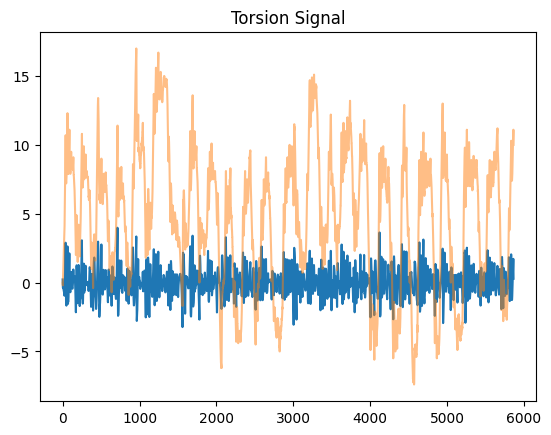

In [71]:
plt.plot(clean_signal(torsion_out, fps= fs, drift_removal=True, drift_window=20, lowcut=2, highcut=20.0, order=4), label='Filtered Torsion Signal')
plt.plot(torsion_out, label='Raw Torsion Signal', alpha=0.5)
plt.title('Torsion Signal')

In [ ]:
ff_vid = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub2\trial.avi"

set_param['do_gaze_tracking'] = True
calib_vid = ff_vid
df_ellipses, df_gaze_out, seg_roi_all, torsion_out, current_iris_imgs_out, template_iris_imgs_out, params \
    = deepvog_processer(calib_vid = calib_vid, ff_vid = ff_vid, eyeball_path = [], set_param = set_param, mode = 'predict')
df_gaze_out.to_csv(ff_vid.replace('.avi', '_gaze.csv'), index=False)
np.save(ff_vid.replace('.avi', '_torsion.npy'), torsion_out)
save_pkl(ff_vid.replace('.avi', '_params.pkl'), params)




**********  STARTING VIDEO **********
D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub2\trial.avi
*************************************

Prediction Mode
Device: cuda
OS: Windows
Running in parallel (multithread) mode
Video info: 240x376, 120.818394 fps, 35687 frames.


Processing Frames: 100%|██████████| 35687/35687 [01:57<00:00, 302.80frame/s]


Closing thread: model_inference (avg/frame: 1900.68 fps)
Closing thread: post_processing (avg/frame: 329.68 fps)
Closing thread: ellipse_fitting (avg/frame: 945.10 fps)
Closing thread: gaze_tracker (avg/frame: 1353.65 fps)
Closing thread: torsion_tracker (avg/frame: 276.58 fps)
torsion_tracker detail: Polar Transform (avg/frame: 313.71 fps)
torsion_tracker detail: Template Matching (avg/frame: 2669.86 fps)
Elapsed time total: 129.24 sec. (avg/frame: 0.004 sec = 276.13 fps.)


In [97]:
len(df_gaze_out)

5866




**********  STARTING VIDEO **********
D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub2\w00001p44858u001s002e010c001m001.avi
*************************************

Prediction Mode
Device: cuda
OS: Windows
Running in parallel (multithread) mode
Video info: 240x376, 120.818394 fps, 5866 frames.


Processing Frames: 100%|██████████| 5866/5866 [00:19<00:00, 298.45frame/s]]


Closing thread: model_inference (avg/frame: 1097.76 fps)
Closing thread: post_processing (avg/frame: 245.23 fps)
Closing thread: ellipse_fitting (avg/frame: 698.75 fps)
Closing thread: gaze_tracker (avg/frame: 558.08 fps)
Closing thread: torsion_tracker (avg/frame: 171.64 fps)
torsion_tracker detail: Polar Transform (avg/frame: 206.83 fps)
torsion_tracker detail: Template Matching (avg/frame: 1082.30 fps)
Elapsed time total: 34.44 sec. (avg/frame: 0.006 sec = 170.33 fps.)


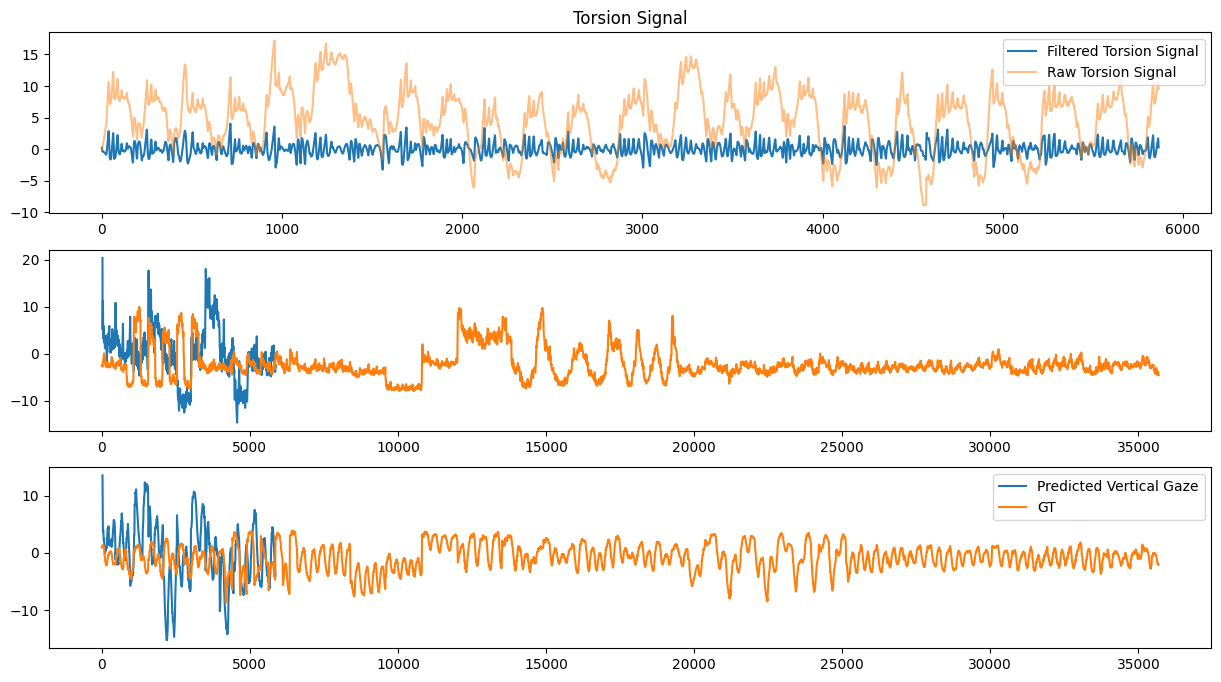

In [ ]:
ff_vid = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub2\w00001p44858u001s002e010c001m001.avi"
# torsion = np.load(vid_path.replace('.avi', '_torsion.npy'))
set_param['do_gaze_tracking'] = True
calib_vid = ff_vid
df_ellipses, df_gaze_out, seg_roi_all, torsion_out, current_iris_imgs_out, template_iris_imgs_out, params \
    = deepvog_processer(calib_vid = ff_vid, ff_vid = ff_vid, eyeball_path = [], set_param = set_param, mode = 'predict')

filtered = clean_signal(torsion_out, fps=fs, drift_removal=True, drift_window=20, lowcut=0.5, highcut=10.0, order=4)

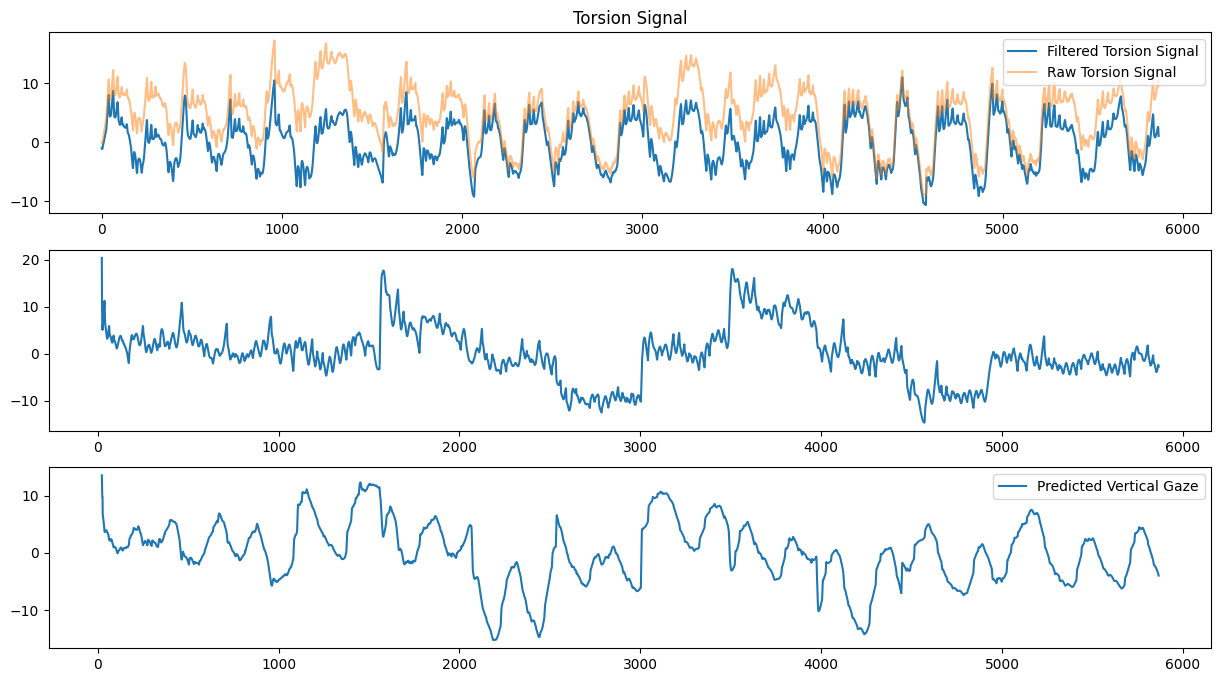

In [101]:
# from utils.gaze_process import gaze_extract_LG, gaze_extract_PL, gaze_extract_GT, gaze_comp_vis, cut_unstable_period
gaze_x, gaze_y = gaze_extract_PL(df_gaze_out)
# df_gaze_GT = pd.read_csv(r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub2\trial.csv")
fs = 120.818326
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
plt.plot(clean_signal(torsion_out, fps= fs, drift_removal=True, drift_window=20, lowcut=0.2, highcut=20.0, order=4), label='Filtered Torsion Signal')
plt.plot(torsion_out, label='Raw Torsion Signal', alpha=0.5)
plt.legend()
# plt.xlim(0, 4000)
plt.title('Torsion Signal')

plt.subplot(3, 1, 2)
plt.plot(gaze_x, label='Predicted Horizontal Gaze')
# plt.plot(np.rad2deg(df_gaze_GT.hor), label='GT')

plt.subplot(3, 1, 3)
plt.plot(gaze_y, label='Predicted Vertical Gaze')
# plt.plot(-np.rad2deg(df_gaze_GT.ver), label='GT')
plt.legend()

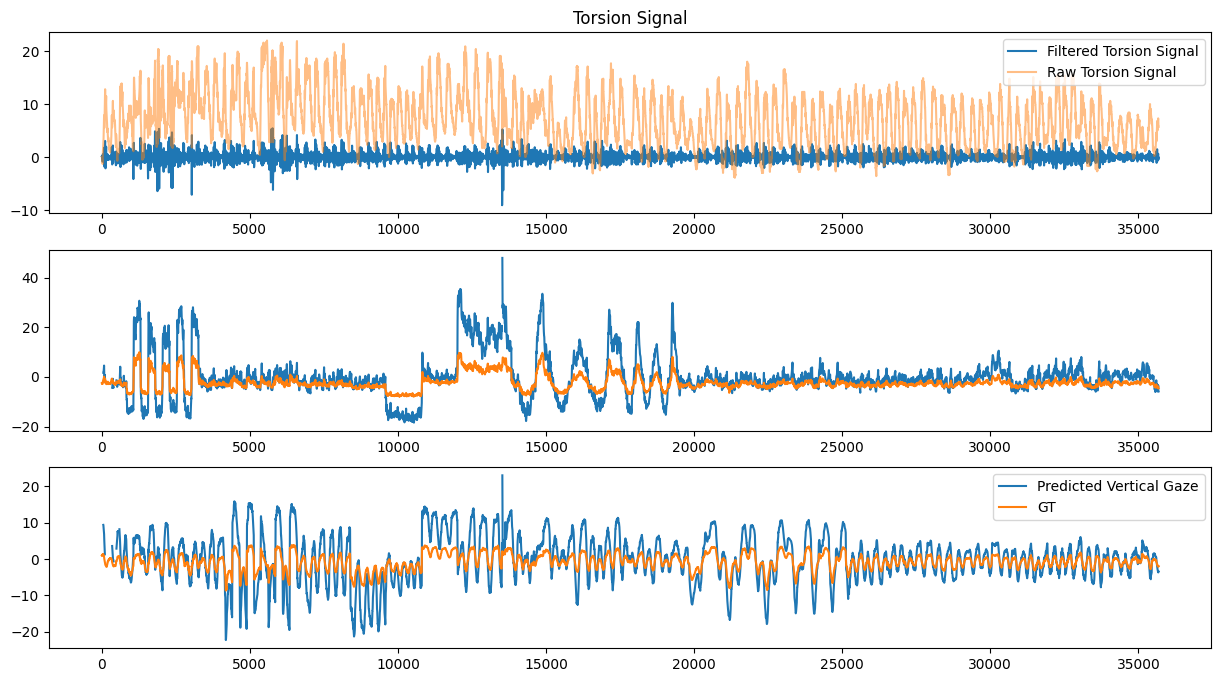

In [ ]:
# from utils.gaze_process import gaze_extract_LG, gaze_extract_PL, gaze_extract_GT, gaze_comp_vis, cut_unstable_period
gaze_x, gaze_y = gaze_extract_PL(df_gaze_out)
df_gaze_GT = pd.read_csv(r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub2\trial.csv")
fs = 120.818326
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
plt.plot(clean_signal(torsion_out, fps= fs, drift_removal=True, drift_window=20, lowcut=2, highcut=20.0, order=4), label='Filtered Torsion Signal')
plt.plot(torsion_out, label='Raw Torsion Signal', alpha=0.5)
plt.legend()
# plt.xlim(0, 4000)
plt.title('Torsion Signal')

plt.subplot(3, 1, 2)
plt.plot(gaze_x, label='Predicted Horizontal Gaze')
plt.plot(np.rad2deg(df_gaze_GT.hor), label='GT')

plt.subplot(3, 1, 3)
plt.plot(gaze_y, label='Predicted Vertical Gaze')
plt.plot(-np.rad2deg(df_gaze_GT.ver), label='GT')
plt.legend()

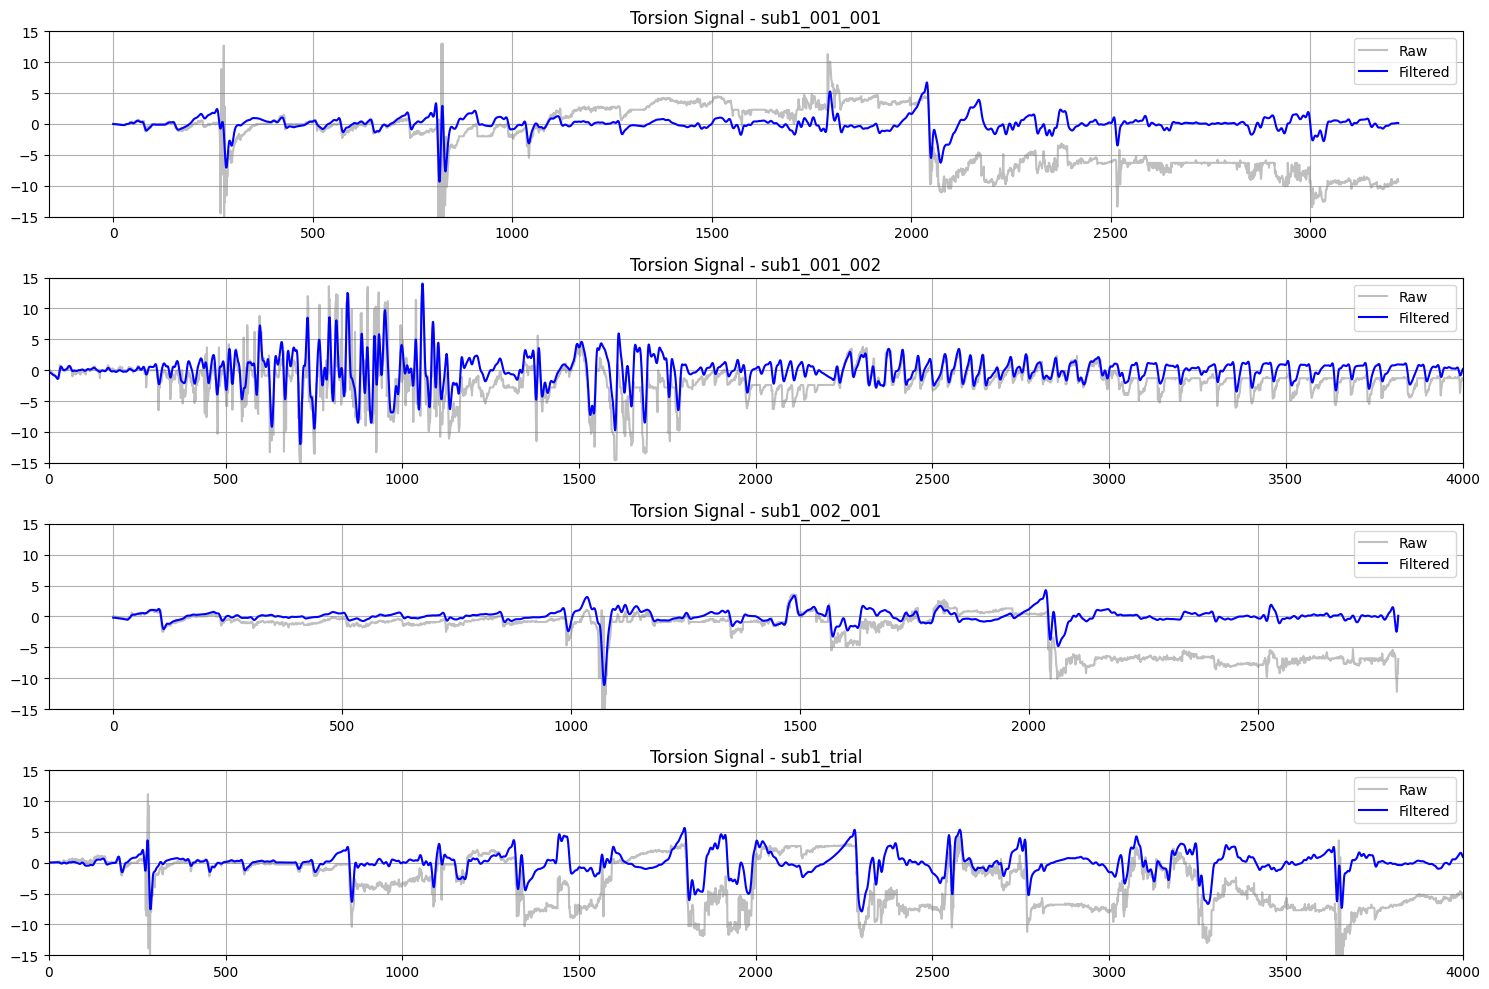

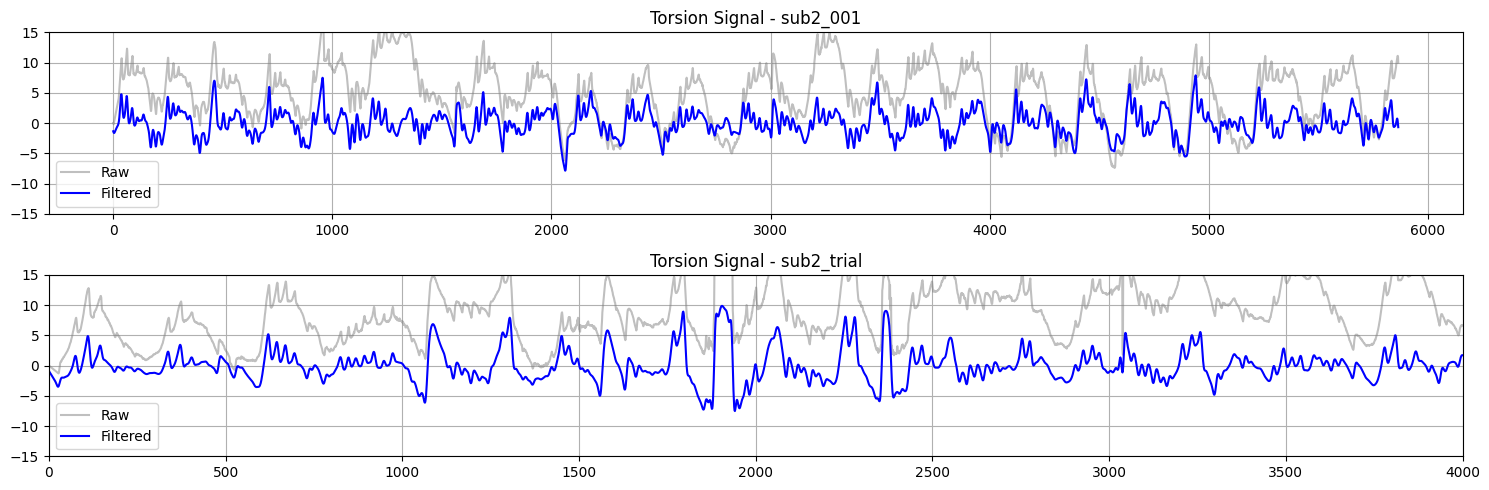

In [ ]:
ff_vid_sub2_trial = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub2\trial.avi"
ff_vid_sub2_001 = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub2\w00001p44858u001s002e010c001m001.avi"
ff_vid_sub1_trial = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\trial.avi"
ff_vid_sub1_002_001 = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\w00001p48065u001s002e010c001m001.avi"
ff_vid_sub1_001_001 = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\w00001p48065u001s001e010c001m001.avi"
ff_vid_sub1_001_002 = r"D:\jzhao\DeepVOG-project\datasets\Patientrecording\sub1\w00001p48065u001s001e010c001m002.avi"

import numpy as np
import matplotlib.pyplot as plt

# === Define signals and labels ===
video_files = [
    (ff_vid_sub1_001_001, "sub1_001_001", (0, None)),
    (ff_vid_sub1_001_002, "sub1_001_002", (0, 4000)),
    (ff_vid_sub1_002_001, "sub1_002_001", (0, None)),
    (ff_vid_sub1_trial, "sub1_trial", (0, 4000)),
]

video_files_sub2 = [
    (ff_vid_sub2_001, "sub2_001", (0, None)),
    (ff_vid_sub2_trial, "sub2_trial", (0, 4000)),
]

def plot_torsion_set(video_set, title_prefix=""):
    fig, axs = plt.subplots(len(video_set), 1, figsize=(15, 2.5 * len(video_set)), sharey=True)
    if len(video_set) == 1:
        axs = [axs]

    for ax, (vid_path, label, xlim_range) in zip(axs, video_set):
        torsion = np.load(vid_path.replace('.avi', '_torsion.npy'))
        filtered = clean_signal(torsion, fps=fs, drift_removal=True, drift_window=20, lowcut=0.5, highcut=10.0, order=4)
        
        ax.plot(torsion, label="Raw", alpha=0.5, color='gray')
        ax.plot(filtered, label="Filtered", color='blue')
        ax.set_title(f"Torsion Signal - {title_prefix}{label}")
        ax.set_ylim(-15, 15)
        if xlim_range[1]:
            ax.set_xlim(*xlim_range)
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

# === Plot both groups ===
plot_torsion_set(video_files, title_prefix="")
plot_torsion_set(video_files_sub2, title_prefix="")


### Extract Interval of 4 Types of Stimuli for Each Subject
**Stimulation Types:**
1. Saccades
2. Fixation Nystagmus
3. Smooth Pursuit
4. Optokinetic Nystagmus

**Note:** Each subject has different stimuli periods.
Save stimuli interval information in dict: st_range_dicts

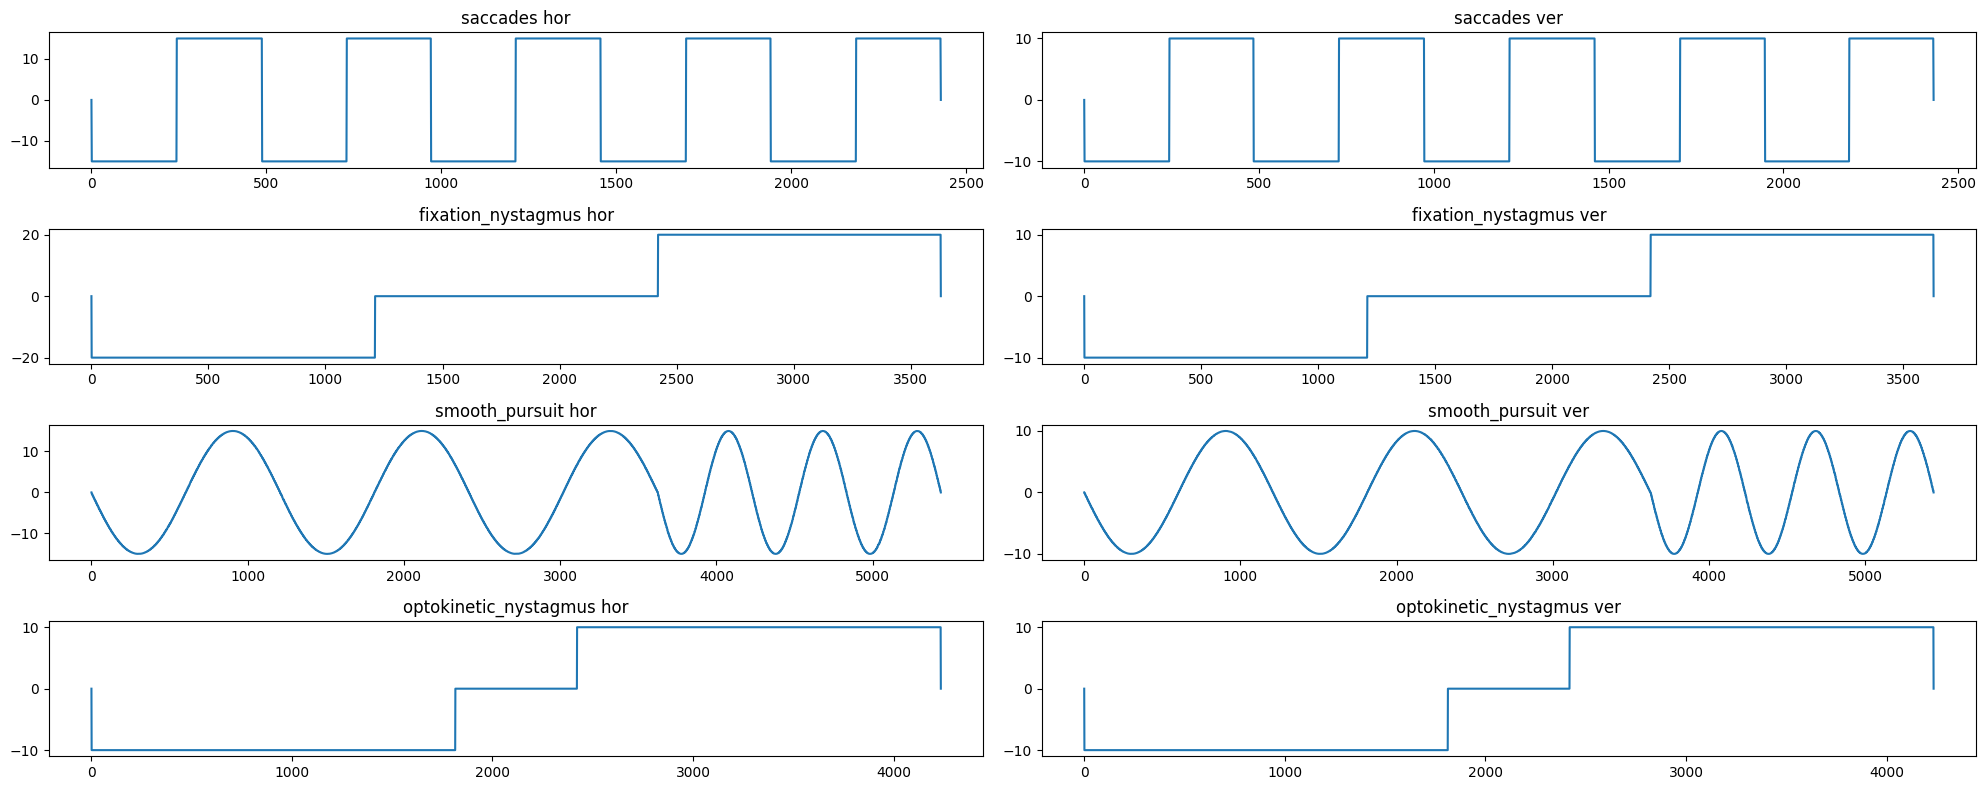

In [10]:
GT_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated\GT"
dataset_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated"
GT_trial_folders = glob.glob(os.path.join(GT_root, "*trial*"))
calibME_folders = glob.glob(os.path.join(GT_root, "*calibME*"))
freelook_folders = glob.glob(os.path.join(GT_root, "*freelook*"))
narrowranged_folders = glob.glob(os.path.join(GT_root, "*narrowranged*"))

subjects = []
for GT_trial_folder in GT_trial_folders:
    subjects.append(os.path.basename(GT_trial_folder).split("_")[0])
# subjects = np.unique(subjects).tolist()

st_range_dicts = dict()
saccades_interval = []
fixation_nystagmus_interval = []
smooth_pursuit_interval = []
optokinetic_nystagmus_interval = []

# for sub in enumerate(subjects):
for GT_trial_folder in GT_trial_folders:
    sub = os.path.basename(GT_trial_folder).split("_")[0]
    # df_GT_gaze_out = pd.read_csv(gaze_dict[sub]['calibME-trial']['GT_gaze'])
    df_GT = pd.read_csv(GT_trial_folder)
    gaze_y_ST = df_GT.TargetVer_Units.values
    ST_x = df_GT.TargetHor_Units.values

    # Find indices where the difference is not zero
    diff_x = np.diff(ST_x)
    diff_y = np.diff(gaze_y_ST)
    ix_x = np.where(diff_x != 0)[0]
    ix_y = np.where(diff_y != 0)[0]
    st_range_dicts[sub] = {
        'saccades': {
            'H': [ix_x[0], ix_x[10]+2],
            'V': [ix_y[0], ix_y[10]+2]
        },
        'fixation_nystagmus': {
            'H': [ix_x[11], ix_x[14]+2],
            'V': [ix_y[11], ix_y[14]+2]
        },
        'smooth_pursuit': {
            'H': [ix_x[15], ix_x[-5]+2],
            'V': [ix_y[15], ix_y[-5]+2]
        },
        'optokinetic_nystagmus': {
            'H': [ix_x[-4], ix_x[-1]+2],
            'V': [ix_y[-4], ix_y[-1]+2]
        }
    }

plt.figure(figsize=(20,8))
plt.subplot(4,2,1)
plt.title('saccades hor')
plt.plot(ST_x[st_range_dicts[sub]['saccades']['H'][0]:st_range_dicts[sub]['saccades']['H'][1]])
plt.subplot(4,2,2)
plt.title('saccades ver')
plt.plot(gaze_y_ST[st_range_dicts[sub]['saccades']['V'][0]:st_range_dicts[sub]['saccades']['V'][1]])
plt.subplot(4,2,3)
plt.title('fixation_nystagmus hor')
plt.plot(ST_x[st_range_dicts[sub]['fixation_nystagmus']['H'][0]:st_range_dicts[sub]['fixation_nystagmus']['H'][1]])
plt.subplot(4,2,4)
plt.title('fixation_nystagmus ver')
plt.plot(gaze_y_ST[st_range_dicts[sub]['fixation_nystagmus']['V'][0]:st_range_dicts[sub]['fixation_nystagmus']['V'][1]])
plt.subplot(4,2,5)
plt.title('smooth_pursuit hor')
plt.plot(ST_x[st_range_dicts[sub]['smooth_pursuit']['H'][0]:st_range_dicts[sub]['smooth_pursuit']['H'][1]])
plt.subplot(4,2,6)
plt.title('smooth_pursuit ver')
plt.plot(gaze_y_ST[st_range_dicts[sub]['smooth_pursuit']['V'][0]:st_range_dicts[sub]['smooth_pursuit']['V'][1]])
plt.subplot(4,2,7)
plt.title('optokinetic_nystagmus hor')
plt.plot(ST_x[st_range_dicts[sub]['optokinetic_nystagmus']['H'][0]:st_range_dicts[sub]['optokinetic_nystagmus']['H'][1]])
plt.subplot(4,2,8)
plt.title('optokinetic_nystagmus ver')
plt.plot(gaze_y_ST[st_range_dicts[sub]['optokinetic_nystagmus']['V'][0]:st_range_dicts[sub]['optokinetic_nystagmus']['V'][1]])
plt.tight_layout()

st_range_path = os.path.join(dataset_root, 'st_range_dicts.pkl')
df_st_range_dicts = pd.DataFrame.from_dict(st_range_dicts, orient='index')
df_st_range_dicts.to_pickle(st_range_path)  

In [4]:
import numpy as np
import pandas as pd
import os
import glob, cv2
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from utils.gaze_process import gaze_extract_LG, gaze_extract_PL, gaze_extract_GT, gaze_comp_vis, gaze_extract_GT_v2
from utils.read_and_save import get_video_info, save_pkl

def cart2sph_batch_PL(N, eps=1e-8):
    N /= np.where((norms := np.linalg.norm(N, axis=0, keepdims=True)) < eps, 1.0, norms)
    phi = np.arctan2(N[2], N[0]) + np.pi / 2
    theta = np.arccos(N[1]) - np.pi / 2
    return -np.rad2deg(phi), np.rad2deg(theta)

def extract_range(x, y, df_ranges):
    # # Compute absolute errors for each movement type
    saccades_err_x = x[df_ranges['saccades']['H'][0]:df_ranges['saccades']['H'][1]]
    saccades_err_y = y[df_ranges['saccades']['V'][0]:df_ranges['saccades']['V'][1]]
    fixation_nystagmus_err_x = x[df_ranges['fixation_nystagmus']['H'][0]:df_ranges['fixation_nystagmus']['H'][1]]
    fixation_nystagmus_err_y = y[df_ranges['fixation_nystagmus']['V'][0]:df_ranges['fixation_nystagmus']['V'][1]]
    smooth_pursuit_err_x = x[df_ranges['smooth_pursuit']['H'][0]:df_ranges['smooth_pursuit']['H'][1]]
    smooth_pursuit_err_y = y[df_ranges['smooth_pursuit']['V'][0]:df_ranges['smooth_pursuit']['V'][1]]
    optokinetic_nystagmus_err_x = x[df_ranges['optokinetic_nystagmus']['H'][0]:df_ranges['optokinetic_nystagmus']['H'][1]]
    optokinetic_nystagmus_err_y = y[df_ranges['optokinetic_nystagmus']['V'][0]:df_ranges['optokinetic_nystagmus']['V'][1]]
    # Concatenate all 'x' errors and 'y' errors
    x_interest = np.concatenate([saccades_err_x, fixation_nystagmus_err_x,smooth_pursuit_err_x, optokinetic_nystagmus_err_x])
    y_interest = np.concatenate([saccades_err_y, fixation_nystagmus_err_y,smooth_pursuit_err_y, optokinetic_nystagmus_err_y])
    return x_interest, y_interest   


def opt_transform(df_GT, df_PL, mov_ranges, thr_confidence=0.96, default_M = np.eye(3), opt_flag = True):
    GT_x, GT_y = gaze_extract_GT_v2(df_GT)
    pred_full = np.full_like(GT_x, np.nan)
    pred_y_full = np.full_like(GT_y, np.nan)
    normals = np.vstack([eval(x)['normal'] for x in df_PL['circle_3d']]).T.astype(np.float32)
    conf = df_PL['confidence'].values

    valid = ~np.isnan(GT_x) & ~np.isnan(GT_y) & ~np.isnan(normals).any(0)
    GT_x, GT_y, normals, conf = GT_x[valid], GT_y[valid], normals[:, valid], conf[valid]

    def loss(params):
        M = params.reshape(3, 3)
        pred_x, pred_y = cart2sph_batch_PL(M @ normals)
        pred_x[conf < thr_confidence] = np.nan
        pred_y[conf < thr_confidence] = np.nan
        pred_x -= np.nanmean(pred_x)
        pred_y -= np.nanmean(pred_y)
        err_x, err_y = extract_range(np.abs(pred_x - GT_x), np.abs(pred_y - GT_y), mov_ranges)
        return np.nanmedian(err_x) + np.nanmedian(err_y)
    
    if opt_flag:
        res = minimize(loss, default_M.flatten(), method='L-BFGS-B')
        M_opt = res.x.reshape(3, 3)
    else:
        M_opt = default_M

    pred = M_opt @ normals
    fx, fy = np.zeros_like(GT_x), np.zeros_like(GT_y)
    fx[:], fy[:] = cart2sph_batch_PL(pred)
    fx[conf < thr_confidence] = np.nan
    fy[conf < thr_confidence] = np.nan
    fx -= np.nanmean(fx)
    fy -= np.nanmean(fy)
    # Insert predictions into full-length arrays
    pred_full[valid] = fx
    pred_y_full[valid] = fy
    return pred_full, pred_y_full, M_opt


def opt_transform_v2(df_GT, normals, conf, mov_ranges, thr_confidence=0.96, default_M = np.eye(3), opt_flag = True):
    GT_x, GT_y = gaze_extract_GT_v2(df_GT)
    pred_full = np.full_like(GT_x, np.nan)
    pred_y_full = np.full_like(GT_y, np.nan)

    valid = ~np.isnan(GT_x) & ~np.isnan(GT_y) & ~np.isnan(normals).any(0)
    GT_x, GT_y, normals, conf = GT_x[valid], GT_y[valid], normals[:, valid], conf[valid]

    def loss(params):
        M = params.reshape(3, 3)
        pred_x, pred_y = cart2sph_batch_PL(M @ normals)
        pred_x[conf < thr_confidence] = np.nan
        pred_y[conf < thr_confidence] = np.nan
        pred_x -= np.nanmean(pred_x)
        pred_y -= np.nanmean(pred_y)
        err_x, err_y = extract_range(np.abs(pred_x - GT_x), np.abs(pred_y - GT_y), mov_ranges)
        return np.nanmedian(err_x) + np.nanmedian(err_y)
    
    if opt_flag:
        res = minimize(loss, default_M.flatten(), method='L-BFGS-B')
        M_opt = res.x.reshape(3, 3)
    else:
        M_opt = default_M

    pred = M_opt @ normals
    fx, fy = np.zeros_like(GT_x), np.zeros_like(GT_y)
    fx[:], fy[:] = cart2sph_batch_PL(pred)
    fx[conf < thr_confidence] = np.nan
    fy[conf < thr_confidence] = np.nan
    fx -= np.nanmean(fx)
    fy -= np.nanmean(fy)
    # Insert predictions into full-length arrays
    pred_full[valid] = fx
    pred_y_full[valid] = fy
    return pred_full, pred_y_full, M_opt

In [5]:
pred_base_name = dict()
calib_types = ["calibME", "freelook", "narrowranged"]
# calib_types = ["calibME"]
fcl = ["06", "12", "16"]
select_calib_num = "001"   #for Dataset C

GT_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated\GT"
GT_trial_folders = glob.glob(os.path.join(GT_root, "*trial*"))
subjects = []
for GT_trial_folder in GT_trial_folders:
    subjects.append(os.path.basename(GT_trial_folder).split("_")[0])
    
# subjects = np.unique(subjects).tolist()
for sub in subjects:
    pred_base_name[sub] = dict()
    for calib_type in calib_types:
        if ('p101' in sub):
            calib_name = f"{select_calib_num}_{calib_type}"
        else:
            calib_name = calib_type
        pred_base_name[sub][calib_type] = f"{sub}_{calib_name}_gaze.csv"
print(pred_base_name.keys())
print(pred_base_name["ffilipopulus"].keys())
print(pred_base_name["p10119"].keys())
print(pred_base_name[sub][calib_type])

dict_keys(['ekierig', 'ffilipopulus', 'fwuhlenweber', 'jgerb', 'jzhao', 'kmoehwald', 'lboborzi', 'mnaeher', 'mwuehr', 'p10119', 'p10120', 'p10121', 'p10122', 'p10123', 'p10124', 'p10125', 'p10126', 'p10127', 'skollmansperger'])
dict_keys(['calibME', 'freelook', 'narrowranged'])
dict_keys(['calibME', 'freelook', 'narrowranged'])
skollmansperger_narrowranged_gaze.csv


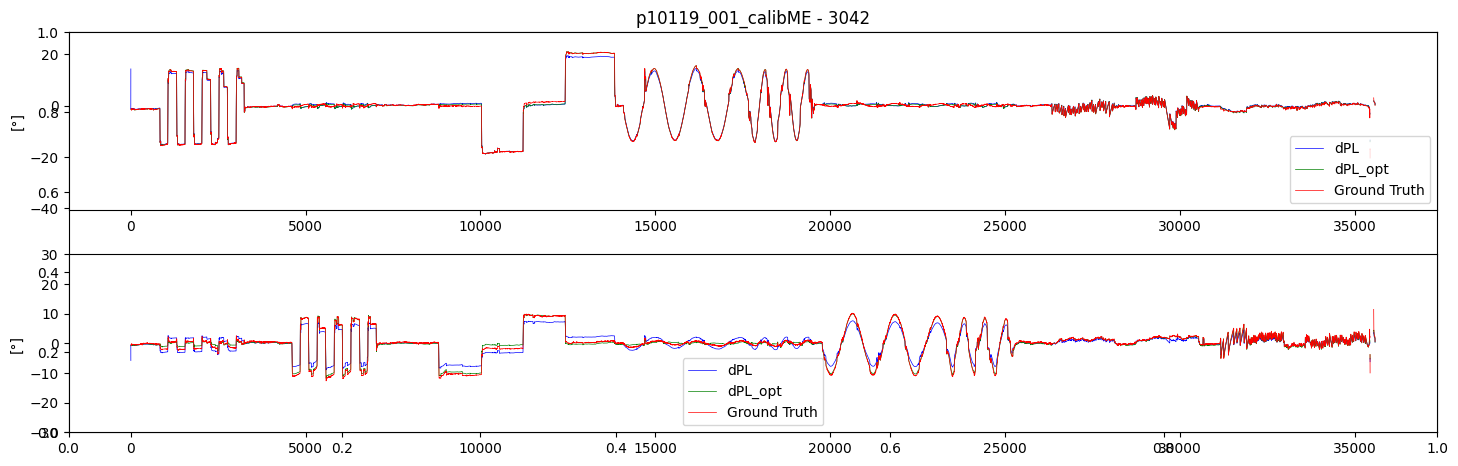

In [8]:
calib_vid_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated\calib_videos"
vid_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated\concatenated_videos_01"
GT_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated\GT"
dataset_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated"

result_root = r"D:\jzhao\DeepVOG-project\result\gaze_estimation\integration\fcl06_PL"
df_st_range_dicts = pd.read_pickle(os.path.join(dataset_root, 'st_range_dicts.pkl'))
# gaze_pred_folders = glob.glob(os.path.join(result_root, "*_gaze.csv"))

sub = "p10119"
# sub = "ffilipopulus"
# subjects = ["p10119", "ffilipopulus"]
# for sub in subjects:
mov_ranges =  df_st_range_dicts.loc[sub]
df_GT =  pd.read_csv(glob.glob(os.path.join(GT_root, f"*{sub}*trial*"))[0])

calib_type = "calibME"
gaze_out_path = os.path.join(result_root, pred_base_name[sub][calib_type])
df_PL = pd.read_csv(gaze_out_path)
calib_vid_name = os.path.basename(gaze_out_path).split("_gaze.csv")[0]  # Extract the common prefix (e.g., "p10119")
max_calib = len(df_PL)-len(df_GT)
pred_x, pred_y = gaze_extract_PL(df_PL[max_calib:])
GT_x, GT_y = gaze_extract_GT_v2(df_GT)
final_x, final_y, opt_M = opt_transform(df_GT, df_PL[max_calib:], mov_ranges, thr_confidence=0.96, default_M=np.eye(3), opt_flag=True)
err_x, err_y = extract_range(np.abs(final_x - GT_x), np.abs(final_y - GT_y), mov_ranges)
# errors.append((np.nanmedian(err_x) + np.nanmedian(err_y), err_x, err_y))

# Create a figure with two subplots
plt.figure(figsize=(15, 5))
plt.title(f"{calib_vid_name} - {max_calib}")
plt.subplot(2, 1, 1)
plt.plot(pred_x, label = "dPL", color='blue', linewidth = 0.5)
plt.plot(final_x, label = "dPL_opt", color='green', linewidth = 0.5)
plt.plot(GT_x, label = "Ground Truth", color='red', linewidth = 0.5)
plt.ylabel('[°]')
plt.legend()
# plt.title('Horizontal Gaze')

plt.subplot(2, 1, 2)
plt.plot(pred_y, label = "dPL", color='blue', linewidth = 0.5)
plt.plot(final_y, label = "dPL_opt", color='green', linewidth = 0.5)
plt.plot(GT_y, label = "Ground Truth", color='red', linewidth = 0.5)
plt.ylim([-30, 30])
plt.ylabel('[°]')
plt.legend()
# plt.title('Vertical Gaze')
plt.tight_layout()
plt.show()

In [56]:
len(df_GT), normals.shape

(35580, (3, 35580))

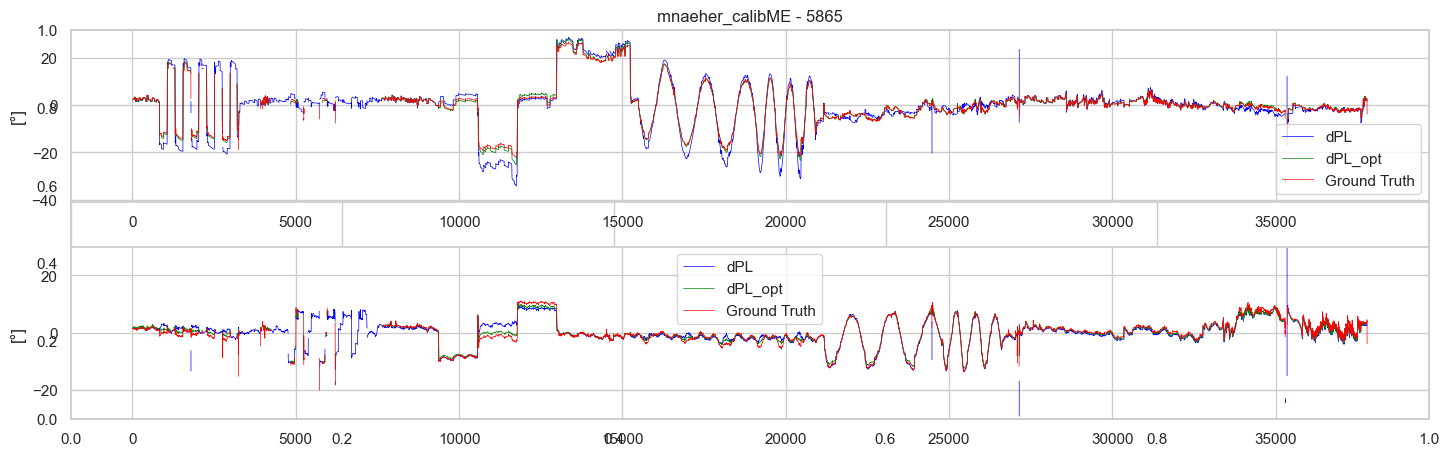

In [482]:
calib_vid_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated\calib_videos"
vid_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated\concatenated_videos_01"
GT_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated\GT"
dataset_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated"

result_root = r"D:\jzhao\DeepVOG-project\result\gaze_estimation\integration\fcl06_simple"
df_st_range_dicts = pd.read_pickle(os.path.join(dataset_root, 'st_range_dicts.pkl'))
# gaze_pred_folders = glob.glob(os.path.join(result_root, "*_gaze.csv"))

# sub = "p10119"su
sub = subjects[7]
# sub = "ffilipopulus"
# subjects = ["p10119", "ffilipopulus"]
# for sub in subjects:
mov_ranges =  df_st_range_dicts.loc[sub]
df_GT =  pd.read_csv(glob.glob(os.path.join(GT_root, f"*{sub}*trial*"))[0])

calib_type = "calibME"
gaze_out_path = os.path.join(result_root, pred_base_name[sub][calib_type])
df_LG = pd.read_csv(gaze_out_path)
calib_vid_name = os.path.basename(gaze_out_path).split("_gaze.csv")[0]  # Extract the common prefix (e.g., "p10119")
max_calib = len(df_LG)-len(df_GT)
pred_x, pred_y = gaze_extract_LG(df_LG[max_calib:])
GT_x, GT_y = gaze_extract_GT_v2(df_GT)

normals = df_LG.loc[max_calib:, ['pupil_3D_norm_x', 'pupil_3D_norm_y', 'pupil_3D_norm_z']].values.T
conf = df_LG.loc[max_calib:, 'confidence'].values
final_x, final_y, opt_M = opt_transform_v2(df_GT, normals, conf, mov_ranges, thr_confidence=0.96, default_M=np.eye(3), opt_flag=True)
err_x, err_y = extract_range(np.abs(final_x - GT_x), np.abs(final_y - GT_y), mov_ranges)
# errors.append((np.nanmedian(err_x) + np.nanmedian(err_y), err_x, err_y))

# Create a figure with two subplots
plt.figure(figsize=(15, 5))
plt.title(f"{calib_vid_name} - {max_calib}")
plt.subplot(2, 1, 1)
plt.plot(pred_x, label = "dPL", color='blue', linewidth = 0.5)
plt.plot(final_x, label = "dPL_opt", color='green', linewidth = 0.5)
plt.plot(GT_x, label = "Ground Truth", color='red', linewidth = 0.5)
plt.ylabel('[°]')
plt.legend()
# plt.title('Horizontal Gaze')

plt.subplot(2, 1, 2)
plt.plot(pred_y, label = "dPL", color='blue', linewidth = 0.5)
plt.plot(final_y, label = "dPL_opt", color='green', linewidth = 0.5)
plt.plot(GT_y, label = "Ground Truth", color='red', linewidth = 0.5)
plt.ylim([-30, 30])
plt.ylabel('[°]')
plt.legend()
# plt.title('Vertical Gaze')
plt.tight_layout()
plt.show()

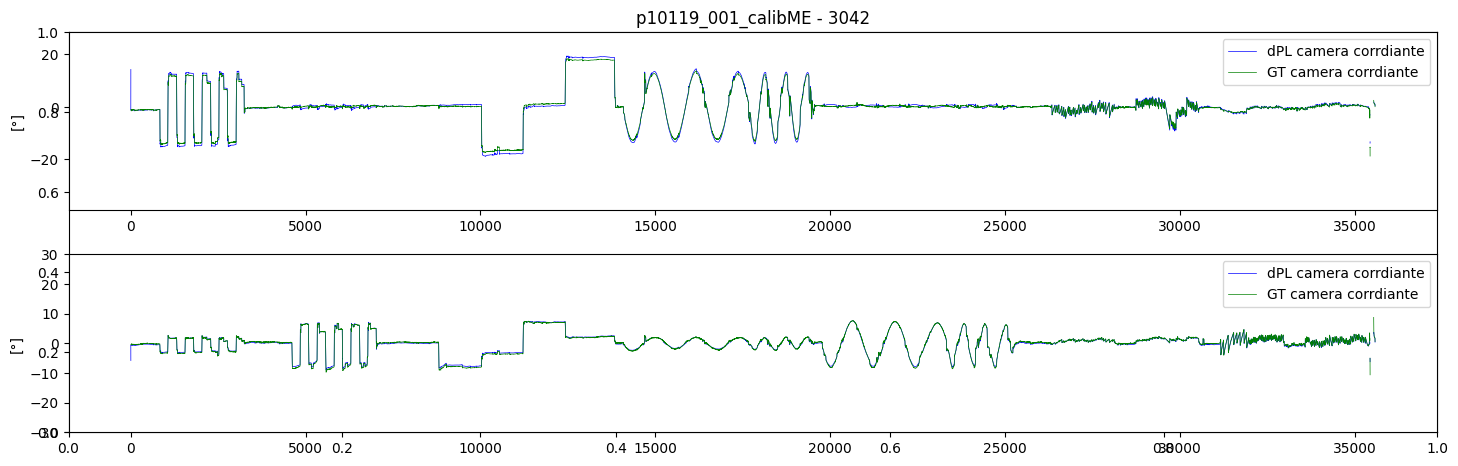

In [11]:
def sph2cart_batch_PL(phi, theta):
    phi = -np.deg2rad(phi) - np.pi / 2
    theta = np.deg2rad(theta) + np.pi / 2
    y = np.cos(theta)
    r = np.sin(theta)
    x = r * np.cos(phi)
    z = r * np.sin(phi)
    return np.stack([x, y, z], axis=0)  # shape: (3, N)


def rot2deg_GT(df_GT):
    return np.degrees(2*np.arctan(df_GT.LeftEyeHor_Rot.values)), -np.degrees(2*np.arctan(df_GT.LeftEyeVer_Rot.values))

sub_ix = subjects.index(sub)
M = opt_M
normals = np.vstack([eval(x)['normal'] for x in df_PL['circle_3d']]).T.astype(np.float32)
x_GT_raw, y_GT_raw = rot2deg_GT(df_GT)
GT_cam_x, GT_cam_y = cart2sph_batch_PL(np.linalg.inv(M) @ sph2cart_batch_PL(x_GT_raw, y_GT_raw))
GT_cam_x -= np.nanmean(GT_cam_x)
GT_cam_y -= np.nanmean(GT_cam_y)

# Create a figure with two subplots
plt.figure(figsize=(15, 5))
plt.title(f"{calib_vid_name} - {max_calib}")
plt.subplot(2, 1, 1)
plt.plot(pred_x, label = "dPL camera corrdiante", color='blue', linewidth = 0.5)
plt.plot(GT_cam_x, label = "GT camera corrdiante", color='green', linewidth = 0.5)
plt.ylabel('[°]')
plt.legend()
# plt.title('Horizontal Gaze')

plt.subplot(2, 1, 2)
plt.plot(pred_y, label = "dPL camera corrdiante", color='blue', linewidth = 0.5)
plt.plot(GT_cam_y, label = "GT camera corrdiante", color='green', linewidth = 0.5)
plt.ylim([-30, 30])
plt.ylabel('[°]')
plt.legend()
# plt.title('Vertical Gaze')
plt.tight_layout()
plt.show()

In [400]:
import pandas as pd
import glob, os

# --- Settings ---
GT_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated\GT"
result_root_base = r"D:\jzhao\DeepVOG-project\result\gaze_estimation\integration"
fcl_versions = ['fcl06', 'fcl12', 'fcl16']
# fcl_versions = ['fcl16']
calib_all = ["calibME", "freelook", "narrowranged"]
# calib_all = ["calibME"]
calib_prefix = "001"

# --- Get subjects ---
GT_paths = glob.glob(os.path.join(GT_root, "*trial*"))
subjects = [os.path.basename(p).split("_")[0] for p in GT_paths]

# --- Build mapping DataFrame ---
rows = []
for sub in subjects:
    GT_path = glob.glob(os.path.join(GT_root, f"{sub}*trial*"))[0]
    for calib in calib_all:
        calib_name = f"{calib_prefix}_{calib}" if "p101" in sub else calib
        pred_name = f"{sub}_{calib_name}_gaze.csv"
        for fcl in fcl_versions:
            PL_pred_path = os.path.join(result_root_base, f"{fcl}_PL", pred_name)
            LG_pred_path = os.path.join(result_root_base, f"{fcl}_simple", pred_name)
            if os.path.exists(PL_pred_path):  # optional safety check
                rows.append({
                    "subject": sub,
                    "calib": calib,
                    "fcl": fcl,
                    "GT_path": GT_path,
                    "PL_path": PL_pred_path,
                    "LG_path": LG_pred_path
                })

df_paths = pd.DataFrame(rows)
df_paths

,subject,calib,fcl,GT_path,PL_path,LG_path
0,ekierig,calibME,fcl06,D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeC...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...
1,ekierig,calibME,fcl12,D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeC...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...
2,ekierig,calibME,fcl16,D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeC...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...
3,ekierig,freelook,fcl06,D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeC...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...
4,ekierig,freelook,fcl12,D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeC...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...
...,...,...,...,...,...,...
166,skollmansperger,freelook,fcl12,D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeC...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...
167,skollmansperger,freelook,fcl16,D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeC...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...
168,skollmansperger,narrowranged,fcl06,D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeC...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...
169,skollmansperger,narrowranged,fcl12,D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeC...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...,D:\jzhao\DeepVOG-project\result\gaze_estimatio...


In [423]:
import numpy as np, pandas as pd, os
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

save_flag = False
# ---- Assume df_paths is already created ----
# Columns: subject, calib, fcl, GT_path, PL_path
df_st_range_dicts = pd.read_pickle(os.path.join(r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated", 'st_range_dicts.pkl'))
thr_confidence = 0.96
analysis_root = r"D:\jzhao\DeepVOG-project\result\gaze_estimation\analysis"
# Store results
gaze_error_all = {c: [] for c in df_paths['calib'].unique()}
M_opt_all = {c: [] for c in df_paths['calib'].unique()}
icc_data = {c: {"hor": [], "ver": []} for c in df_paths['calib'].unique()}

# ========== Define core process ==========
def process_row(row):
    df_GT = pd.read_csv(row.GT_path)
    df_PL = pd.read_csv(row.PL_path)
    # df_LG = pd.read_csv(row.LG_path)  # Not used in this example
    GT_x, GT_y = gaze_extract_GT_v2(df_GT)
    # GT_y = -GT_y
    mov_ranges = df_st_range_dicts.loc[row.subject]
    max_calib = len(df_PL) - len(df_GT)

    fx, fy, M = opt_transform(df_GT, df_PL[max_calib:], mov_ranges, thr_confidence, np.eye(3), True)
    err_x, err_y = extract_range(np.abs(fx - GT_x), np.abs(fy - GT_y), mov_ranges)
    total_error = np.nanmedian(err_x) + np.nanmedian(err_y)
    return row.subject, row.calib, row.fcl, err_x, err_y, M, total_error

# DataFrame to store best PL_paths
best_paths_rows = []
# ========== Process ==========
for calib in df_paths['calib'].unique():
    df_calib = df_paths[df_paths['calib'] == calib]
    error_x_all, error_y_all, M_all = [], [], []

    with ThreadPoolExecutor() as executor:
        futures = {executor.submit(process_row, row): row for row in df_calib.itertuples(index=False)}
        results = [future.result() for future in tqdm(futures, total=len(futures), desc=f"Processing {calib}")]

    # Group by subject, choose best FCL per subject
    df_results = pd.DataFrame(results, columns=['subject', 'calib', 'fcl', 'err_x', 'err_y', 'M', 'total_error'])
    for sub in df_results['subject'].unique():
        best = df_results[df_results['subject'] == sub].sort_values("total_error").iloc[0]
        ex, ey, M = best['err_x'], best['err_y'], best['M']
        error_x_all.append(ex)
        error_y_all.append(ey)
        M_all.append(M)
        icc_data[calib]['hor'].append(np.nanmedian(ex))
        icc_data[calib]['ver'].append(np.nanmedian(ey))
        # --- Collect the best path ---
        best_path_row = df_calib[(df_calib['subject'] == sub) & (df_calib['fcl'] == best['fcl'])].iloc[0]
        best_paths_rows.append({
            "subject": sub,
            "calib": calib,
            "fcl": best['fcl'],
            "PL_path": best_path_row.PL_path,
            "GT_path": best_path_row.GT_path,
        })

    ex, ey = np.concatenate(error_x_all), np.concatenate(error_y_all)
    gaze_error_all[calib], M_opt_all[calib] = (ex, ey), M_all

    print(f"{calib}: median_error_x: {np.nanmedian(ex):.4f}, Q1-Q3: {np.nanpercentile(ex[~np.isnan(ex)], [25, 75])}")
    print(f"{calib}: median_error_y: {np.nanmedian(ey):.4f}, Q1-Q3: {np.nanpercentile(ey[~np.isnan(ey)], [25, 75])}")
    # Create final best-path DataFrame
df_PL_paths = pd.DataFrame(best_paths_rows)
# df_icc_data = pd.DataFrame(icc_data)

if save_flag:
    # analysis_root = r"D:\jzhao\DeepVOG-project\result\gaze_estimation\analysis"
    output_path = os.path.join(analysis_root, "best_path_PL.csv")
    df_PL_paths.to_csv(output_path, index=False)
    save_pkl(os.path.join(analysis_root, "icc_data_PL.pkl"), icc_data)
    np.save(os.path.join(analysis_root, "gaze_error_PL.npy"), gaze_error_all)
    np.save(os.path.join(analysis_root, "M_opt_PL.npy"), M_opt_all)
    print(f"✅ Saved to: {analysis_root}")

Processing calibME: 100%|██████████| 57/57 [04:02<00:00,  4.25s/it]  


calibME: median_error_x: 0.0978, Q1-Q3: [0.03958057 0.25403006]
calibME: median_error_y: 0.1280, Q1-Q3: [0.05191732 0.28355335]


Processing freelook: 100%|██████████| 57/57 [04:20<00:00,  4.56s/it]  


freelook: median_error_x: 0.1036, Q1-Q3: [0.04053351 0.26678075]
freelook: median_error_y: 0.1362, Q1-Q3: [0.05514618 0.29454169]


Processing narrowranged: 100%|██████████| 57/57 [04:00<00:00,  4.22s/it]  

narrowranged: median_error_x: 0.1141, Q1-Q3: [0.04749199 0.31286822]
narrowranged: median_error_y: 0.1011, Q1-Q3: [0.04326507 0.22819379]
✅ Saved to: D:\jzhao\DeepVOG-project\result\gaze_estimation\analysis


In [ ]:
# <!-- fcl = 6, 12, 16 
# rocessing calibME: 100%|██████████| 57/57 [02:32<00:00,  2.67s/it] 
# calibME: median_error_x: 0.0978, Q1-Q3: [0.03958057 0.25403006]
# calibME: median_error_y: 0.1280, Q1-Q3: [0.05191732 0.28355335]
# Processing freelook: 100%|██████████| 57/57 [02:57<00:00,  3.12s/it] 
# freelook: median_error_x: 0.1036, Q1-Q3: [0.04053351 0.26678075]
# freelook: median_error_y: 0.1362, Q1-Q3: [0.05514618 0.29454169]
# Processing narrowranged: 100%|██████████| 57/57 [03:45<00:00,  3.95s/it]  
# narrowranged: median_error_x: 0.1141, Q1-Q3: [0.04749199 0.31286822]
# narrowranged: median_error_y: 0.1011, Q1-Q3: [0.04326507 0.22819379]
# ✅ Saved to: D:\jzhao\DeepVOG-project\result\gaze_estimation\analysis -->

# why using gaze_extract_GT is worse than using gaze_extract_GT_v2?
# gaze_extract_GT should extract more info than v2...
# Processing calibME: 100%|██████████| 57/57 [03:55<00:00,  4.14s/it]  
# calibME: median_error_x: 0.3262, Q1-Q3: [0.12243633 0.70150463]
# calibME: median_error_y: 0.2749, Q1-Q3: [0.10667306 0.61901761]
# Processing freelook: 100%|██████████| 57/57 [04:14<00:00,  4.46s/it]  
# freelook: median_error_x: 0.2939, Q1-Q3: [0.10081147 0.69132346]
# freelook: median_error_y: 0.2827, Q1-Q3: [0.10101225 0.67887319]
# Processing narrowranged: 100%|██████████| 57/57 [03:55<00:00,  4.13s/it]  narrowranged: median_error_x: 0.3233, Q1-Q3: [0.12547941 0.68519796]
# narrowranged: median_error_y: 0.2576, Q1-Q3: [0.09533484 0.60029299]
# ✅ Saved to: D:\jzhao\DeepVOG-project\result\gaze_estimation\analysis


In [ ]:
import numpy as np, pandas as pd, os
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

save_flag = False
# ---- Assume df_paths is already created ----
# Columns: subject, calib, fcl, GT_path, PL_path
df_st_range_dicts = pd.read_pickle(os.path.join(r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated", 'st_range_dicts.pkl'))
thr_confidence = 0.96

# Store results
gaze_error_all = {c: [] for c in df_paths['calib'].unique()}
M_opt_all = {c: [] for c in df_paths['calib'].unique()}
icc_data = {c: {"hor": [], "ver": []} for c in df_paths['calib'].unique()}

# ========== Define core process ==========
def process_row(row):
    df_GT = pd.read_csv(row.GT_path)
    # # df_PL = pd.read_csv(row.PL_path)
    # df_LG = pd.read_csv(row.LG_path)  # Not used in this example
    # df_GT = pd.read_csv(row.GT_path, usecols=["TargetHor_Rot", "TargetVer_Rot"], low_memory=False)
    df_LG = pd.read_csv(row.LG_path, usecols=["pupil_3D_norm_x", "pupil_3D_norm_y", "pupil_3D_norm_z", "confidence"], low_memory=False)
    GT_x, GT_y = gaze_extract_GT(df_GT)
    GT_y = -GT_y
    mov_ranges = df_st_range_dicts.loc[row.subject]
    max_calib = len(df_LG) - len(df_GT)

    normals = df_LG.loc[max_calib:, ['pupil_3D_norm_x', 'pupil_3D_norm_y', 'pupil_3D_norm_z']].values.T
    conf = df_LG.loc[max_calib:, 'confidence'].values
    fx, fy, M = opt_transform_v2(df_GT, normals, conf, mov_ranges, thr_confidence=0.96, default_M=np.eye(3), opt_flag=True)
    err_x, err_y = extract_range(np.abs(fx - GT_x), np.abs(fy - GT_y), mov_ranges)
    total_error = np.nanmedian(err_x) + np.nanmedian(err_y)
    return row.subject, row.calib, row.fcl, err_x, err_y, M, total_error

# DataFrame to store best PL_paths
best_paths_rows = []
# ========== Process ==========
for calib in df_paths['calib'].unique():
    df_calib = df_paths[df_paths['calib'] == calib]
    error_x_all, error_y_all, M_all = [], [], []

    with ThreadPoolExecutor() as executor:
        futures = {executor.submit(process_row, row): row for row in df_calib.itertuples(index=False)}
        results = [future.result() for future in tqdm(futures, total=len(futures), desc=f"Processing {calib}")]

    # Group by subject, choose best FCL per subject
    df_results = pd.DataFrame(results, columns=['subject', 'calib', 'fcl', 'err_x', 'err_y', 'M', 'total_error'])
    for sub in df_results['subject'].unique():
        best = df_results[df_results['subject'] == sub].sort_values("total_error").iloc[0]
        ex, ey, M = best['err_x'], best['err_y'], best['M']
        error_x_all.append(ex)
        error_y_all.append(ey)
        M_all.append(M)
        icc_data[calib]['hor'].append(np.nanmedian(ex))
        icc_data[calib]['ver'].append(np.nanmedian(ey))
        # --- Collect the best path ---
        best_path_row = df_calib[(df_calib['subject'] == sub) & (df_calib['fcl'] == best['fcl'])].iloc[0]
        best_paths_rows.append({
            "subject": sub,
            "calib": calib,
            "fcl": best['fcl'],
            "PL_path": best_path_row.PL_path,
            "GT_path": best_path_row.GT_path,
        })

    ex, ey = np.concatenate(error_x_all), np.concatenate(error_y_all)
    gaze_error_all[calib], M_opt_all[calib] = (ex, ey), M_all

    print(f"{calib}: median_error_x: {np.nanmedian(ex):.4f}, Q1-Q3: {np.nanpercentile(ex[~np.isnan(ex)], [25, 75])}")
    print(f"{calib}: median_error_y: {np.nanmedian(ey):.4f}, Q1-Q3: {np.nanpercentile(ey[~np.isnan(ey)], [25, 75])}")
    # Create final best-path DataFrame
df_best_LG = pd.DataFrame(best_paths_rows)

if save_flag:
    # analysis_root = r"D:\jzhao\DeepVOG-project\result\gaze_estimation\analysis"
    output_path = os.path.join(analysis_root, "best_path_LG.csv")
    df_PL_paths.to_csv(output_path, index=False)
    save_pkl(os.path.join(analysis_root, "icc_data_LG.pkl"), icc_data)
    np.save(os.path.join(analysis_root, "gaze_error_LG.npy"), gaze_error_all)
    np.save(os.path.join(analysis_root, "M_opt_LG.npy"), M_opt_all)
    print(f"✅ Saved to: {analysis_root}")

Processing calibME: 100%|██████████| 57/57 [02:50<00:00,  2.99s/it] 


calibME: median_error_x: 0.3155, Q1-Q3: [0.10580446 0.68849023]
calibME: median_error_y: 0.2979, Q1-Q3: [0.12549395 0.71459429]


Processing freelook: 100%|██████████| 57/57 [03:20<00:00,  3.53s/it]


freelook: median_error_x: 0.3064, Q1-Q3: [0.11959161 0.70188792]
freelook: median_error_y: 0.3201, Q1-Q3: [0.13295662 0.67412417]


Processing narrowranged: 100%|██████████| 57/57 [02:44<00:00,  2.88s/it]

narrowranged: median_error_x: 0.3165, Q1-Q3: [0.11981656 0.71285675]
narrowranged: median_error_y: 0.3058, Q1-Q3: [0.11500202 0.66077465]
✅ Saved to: D:\jzhao\DeepVOG-project\result\gaze_estimation\analysis


In [422]:
# GT_x_old, GT_y_old = gaze_extract_GT(df_GT)
# GT_x_new, GT_y_new = gaze_extract_GT_v2(df_GT)
# plt.plot(-GT_y_old, label = "GT_old", color='blue', linewidth = 0.5)
# plt.plot(GT_y_new, label = "GT_new", color='green', linewidth = 0.5)
# plt.legend()

In [ ]:
# Processing calibME: 100%|██████████| 57/57 [01:58<00:00,  2.07s/it]
# calibME: median_error_x: 0.1051, Q1-Q3: [0.0439116  0.31305934]
# calibME: median_error_y: 0.1617, Q1-Q3: [0.06662081 0.33204118]
# Processing freelook: 100%|██████████| 57/57 [02:10<00:00,  2.28s/it]
# freelook: median_error_x: 0.0955, Q1-Q3: [0.03806061 0.25785097]
# freelook: median_error_y: 0.1337, Q1-Q3: [0.05281041 0.29594429]
# Processing narrowranged: 100%|██████████| 57/57 [01:56<00:00,  2.05s/it]
# narrowranged: median_error_x: 0.1115, Q1-Q3: [0.04329953 0.30038176]
# narrowranged: median_error_y: 0.1591, Q1-Q3: [0.06695629 0.35826849]
# ✅ Saved to: D:\jzhao\DeepVOG-project\result\gaze_estimation\analysis

In [8]:
analysis_root = r"D:\jzhao\DeepVOG-project\result\gaze_estimation\analysis"
df_best_LG = pd.read_csv(os.path.join(analysis_root, "best_path_LG.csv"))
df_best_PL = pd.read_csv(os.path.join(analysis_root, "best_path_PL.csv"))
M_opt_LG = np.load(os.path.join(analysis_root, "M_opt_LG.npy"), allow_pickle=True).item()
M_opt_PL = np.load(os.path.join(analysis_root, "M_opt_PL.npy"), allow_pickle=True).item()
gaze_error_LG = np.load(os.path.join(analysis_root, "gaze_error_LG.npy"), allow_pickle=True).item()
gaze_error_PL = np.load(os.path.join(analysis_root, "gaze_error_PL.npy"), allow_pickle=True).item()
icc_data_PL = pd.read_pickle(os.path.join(analysis_root, "icc_data_PL.pkl"))
icc_data_LG = pd.read_pickle(os.path.join(analysis_root, "icc_data_LG.pkl"))

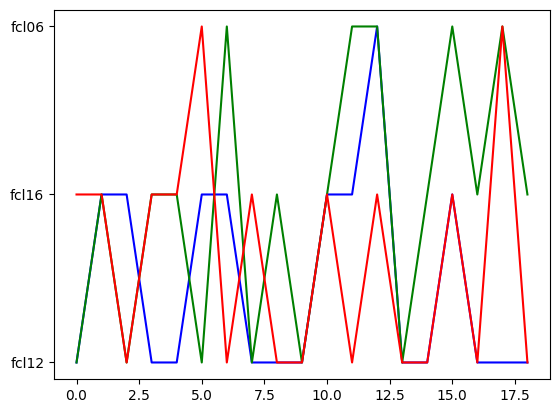

In [17]:
# plt.plot(df_best_LG.fcl)
# plt.plot(df_best_PL.fcl)
plt.plot(df_best_PL.loc[df_best_PL.calib=="calibME"].fcl.values, label = "calibME", color='blue')
plt.plot(df_best_PL.loc[df_best_PL.calib=="freelook"].fcl.values, label = "freelook", color='green')
plt.plot(df_best_PL.loc[df_best_PL.calib=="narrowranged"].fcl.values, label = "narrowranged", color='red')

In [9]:
import pingouin as pg
import pandas as pd

# Create ICC DataFrames
icc_data = icc_data_PL
df_icc_hor = pd.DataFrame({k: v["hor"] for k, v in icc_data.items()})
df_icc_ver = pd.DataFrame({k: v["ver"] for k, v in icc_data.items()})
df_icc_hor["subject"] = df_icc_ver["subject"] = subjects  # Add subject column

# Melt to long format
hor_long = df_icc_hor.melt(id_vars="subject", var_name="calibration", value_name="error")
ver_long = df_icc_ver.melt(id_vars="subject", var_name="calibration", value_name="error")

# Compute ICC
icc_hor_result = pg.intraclass_corr(data=hor_long, targets='subject', raters='calibration', ratings='error')
icc_ver_result = pg.intraclass_corr(data=ver_long, targets='subject', raters='calibration', ratings='error')

# Print ICC(3,1) results
print("\nICC(3,1) — Horizontal Gaze Error:")
print(icc_hor_result[icc_hor_result['Type'] == 'ICC3'])

print("\nICC(3,1) — Vertical Gaze Error:")
print(icc_ver_result[icc_ver_result['Type'] == 'ICC3'])


ICC(3,1) — Horizontal Gaze Error:
   Type          Description      ICC          F  df1  df2          pval  \
2  ICC3  Single fixed raters  0.88298  23.636608   18   36  9.688591e-15   

          CI95%  
2  [0.77, 0.95]  

ICC(3,1) — Vertical Gaze Error:
   Type          Description       ICC         F  df1  df2     pval  \
2  ICC3  Single fixed raters  0.590402  5.324254   18   36  0.00001   

         CI95%  
2  [0.33, 0.8]  


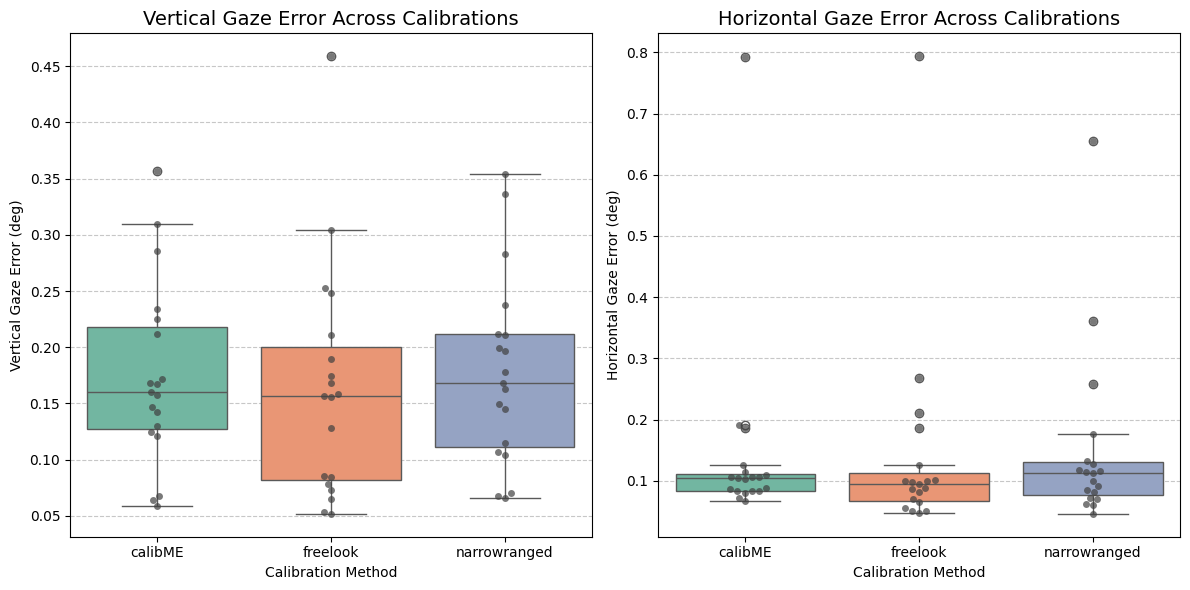

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Melt into long format
df_long_ver = df_icc_ver.melt(id_vars="subject", 
                               value_vars=["calibME", "freelook", "narrowranged"],
                               var_name="Calibration", 
                               value_name="Vertical Error")

df_long_hor = df_icc_hor.melt(id_vars="subject", 
                               value_vars=["calibME", "freelook", "narrowranged"],
                               var_name="Calibration", 
                               value_name="Horizontal Error")

plt.figure(figsize=(12, 6))

# --- Vertical Error Plot ---
plt.subplot(1, 2, 1)
sns.boxplot(x="Calibration", y="Vertical Error", hue="Calibration", data=df_long_ver, palette="Set2", legend=False)
sns.swarmplot(x="Calibration", y="Vertical Error", data=df_long_ver, color=".25", alpha=0.7)
plt.title("Vertical Gaze Error Across Calibrations", fontsize=14)
plt.ylabel("Vertical Gaze Error (deg)")
plt.xlabel("Calibration Method")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# --- Horizontal Error Plot ---
plt.subplot(1, 2, 2)
sns.boxplot(x="Calibration", y="Horizontal Error", hue="Calibration", data=df_long_hor, palette="Set2", legend=False)
sns.swarmplot(x="Calibration", y="Horizontal Error", data=df_long_hor, color=".25", alpha=0.7)
plt.title("Horizontal Gaze Error Across Calibrations", fontsize=14)
plt.ylabel("Horizontal Gaze Error (deg)")
plt.xlabel("Calibration Method")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
def sph2cart_batch_PL(phi, theta):
    phi = -np.deg2rad(phi) - np.pi / 2
    theta = np.deg2rad(theta) + np.pi / 2
    y = np.cos(theta)
    r = np.sin(theta)
    x = r * np.cos(phi)
    z = r * np.sin(phi)
    return np.stack([x, y, z], axis=0)  # shape: (3, N)

def rot2deg_GT(df_GT):
    return np.degrees(2*np.arctan(df_GT.LeftEyeHor_Rot.values)), -np.degrees(2*np.arctan(df_GT.LeftEyeVer_Rot.values))

sub_ix = subjects.index(sub)
sub = subjects[sub_ix]
calib = "calibME"
M = M_opt_all[calib][sub_ix]
df_GT =  pd.read_csv(glob.glob(os.path.join(GT_root, f"*{sub}*trial*"))[0])
x_GT_raw, y_GT_raw = rot2deg_GT(df_GT)
GT_cam_x, GT_cam_y = cart2sph_batch_PL(np.linalg.inv(M) @ sph2cart_batch_PL(x_GT_raw, y_GT_raw))
GT_cam_x -= np.nanmean(GT_cam_x)
GT_cam_y -= np.nanmean(GT_cam_y)

df_PL = pd.read_csv(os.path.join(root_results['fcl06'], pred_base_name[sub][calib]))
max_calib = len(df_PL)-len(df_GT)
pred_x, pred_y = gaze_extract_PL(df_PL[max_calib:])
GT_x, GT_y = gaze_extract_GT_v2(df_GT)
# plt.figure(figsize=(15, 5))
# plt.title(f"{calib_vid_name} - {max_calib}")
# plt.subplot(2, 1, 1)
# plt.plot(pred_x, label = "dPL camera corrdiante", color='blue', linewidth = 0.5)
# plt.plot(GT_cam_x, label = "GT camera corrdiante", color='green', linewidth = 0.5)
# plt.plot(GT_x, label = "GT", color='red', linewidth = 0.5)
# plt.ylabel('[°]')
# plt.legend()
# # plt.title('Horizontal Gaze')
# plt.subplot(2, 1, 2)
# plt.plot(pred_y, label = "dPL camera corrdiante", color='blue', linewidth = 0.5)
# plt.plot(GT_cam_y, label = "GT camera corrdiante", color='green', linewidth = 0.5)
# plt.plot(GT_y, label = "GT", color='red', linewidth = 0.5)
# plt.ylim([-30, 30])
# plt.ylabel('[°]')
# plt.legend()
# # plt.title('Vertical Gaze')
# plt.tight_layout()
# plt.show()

C:\Users\jzhao\AppData\Local\Temp\ipykernel_82032\3249967684.py:46: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

C:\Users\jzhao\AppData\Local\Temp\ipykernel_82032\3249967684.py:46: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



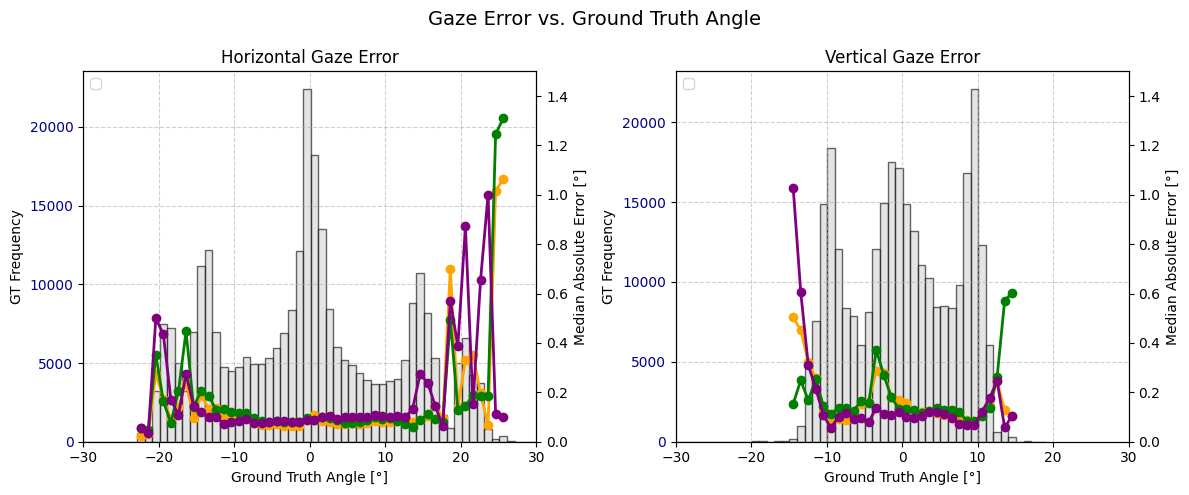

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_histogram(ax, GT, bins, title):
    ax.hist(GT, bins=bins, color='lightgray', edgecolor='black', alpha=0.6, zorder=0)
    ax.set(xlabel='Ground Truth Angle [°]', ylabel='GT Frequency', title=title, xlim=[-30, 30])
    ax.tick_params(axis='y', labelcolor='darkblue')
    ax.grid(ls='--', alpha=0.6)

def plot_median(ax, GT, err, bins, color, label):
    df = pd.DataFrame({'GT': GT, 'error': err})
    df['bin'] = pd.cut(df.GT, bins, include_lowest=True)
    stats = df.groupby('bin', observed=False)['error'].agg(['count', 'median'])
    stats = stats[stats['count'] >= 100]
    mids = stats.index.categories.mid[stats.index.codes]
    ax.set_ylim(0, 1.5)
    return ax.plot(mids, stats['median'], color=color, marker='o', lw=2, label=label)[0]

# ----- Preprocess GT once -----
GT_xs, GT_ys = [], []
for sub in df_paths['subject'].unique():
    mov_ranges = df_st_range_dicts.loc[sub]
    df_GT = pd.read_csv(df_paths[df_paths['subject'] == sub].iloc[0]['GT_path'])
    GT_x, GT_y = extract_range(*gaze_extract_GT_v2(df_GT), mov_ranges)
    GT_xs.append(GT_x)
    GT_ys.append(GT_y)

gaze_GT_all = (np.concatenate(GT_xs), np.concatenate(GT_ys))
GTs = [gaze_GT_all[0], gaze_GT_all[1]]
bin_edges = [np.arange(np.nanmin(G), np.nanmax(G) + 1, 1) for G in GTs]
titles = ["Horizontal", "Vertical"]
color_map = {"calibME": "orange", "freelook": "green", "narrowranged": "purple"}

# ----- Plot -----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Gaze Error vs. Ground Truth Angle", fontsize=14)

for i, (GT, bins, ax, title) in enumerate(zip(GTs, bin_edges, axes, titles)):
    plot_histogram(ax, GT, bins, f"{title} Gaze Error")
    twin = ax.twinx()
    twin.set_ylabel('Median Absolute Error [°]')
    for calib in calib_all:
        err = gaze_error_all[calib][i]
        plot_median(twin, GT, err, bins, color_map[calib], f"{calib} Median")
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

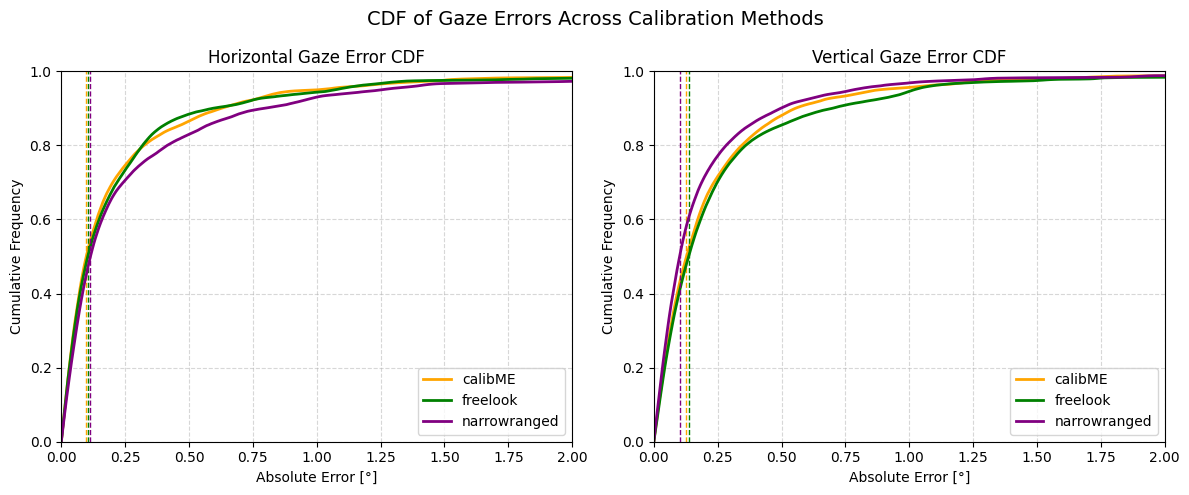

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cdf(ax, data, label, color):
    data = np.sort(data[~np.isnan(data)])
    cdf = np.linspace(0, 1, len(data))
    median = np.median(data)
    ax.plot(data, cdf, label=label, color=color, lw=2)
    ax.axvline(median, color=color, ls='--', lw=1)

colors = {"calibME": "orange", "freelook": "green", "narrowranged": "purple"}
titles = ["Horizontal Gaze Error CDF", "Vertical Gaze Error CDF"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for calib, color in colors.items():
    err_x, err_y = gaze_error_all[calib]
    for ax, err, title in zip(axes, [err_x, err_y], titles):
        plot_cdf(ax, err, calib, color)

for ax, title in zip(axes, titles):
    ax.set(xlim=(0, 2), ylim=(0, 1), xlabel='Absolute Error [°]', ylabel='Cumulative Frequency', title=title)
    ax.grid(ls='--', alpha=0.5)
    ax.legend()

fig.suptitle("CDF of Gaze Errors Across Calibration Methods", fontsize=14)
plt.tight_layout()
plt.show()

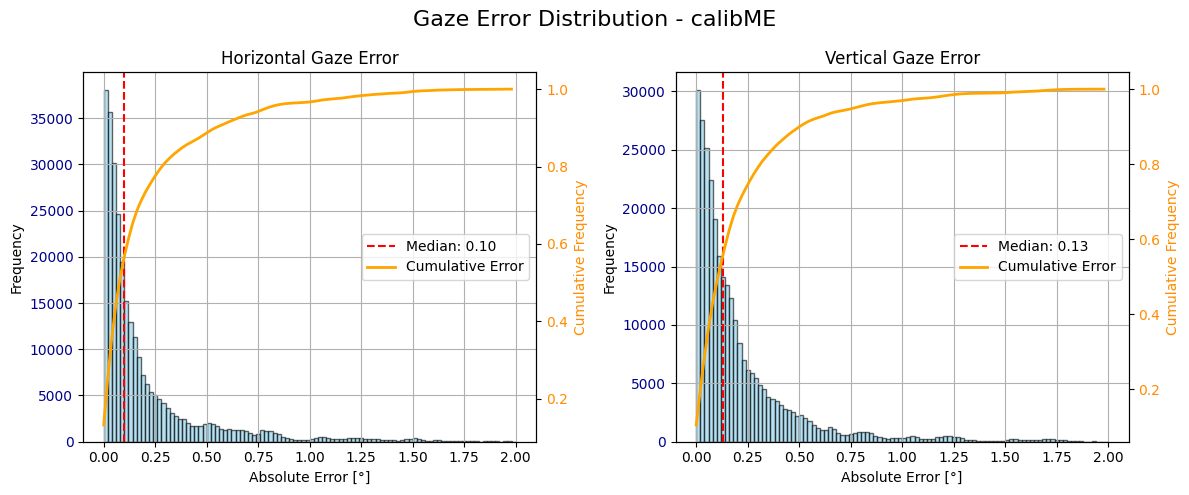

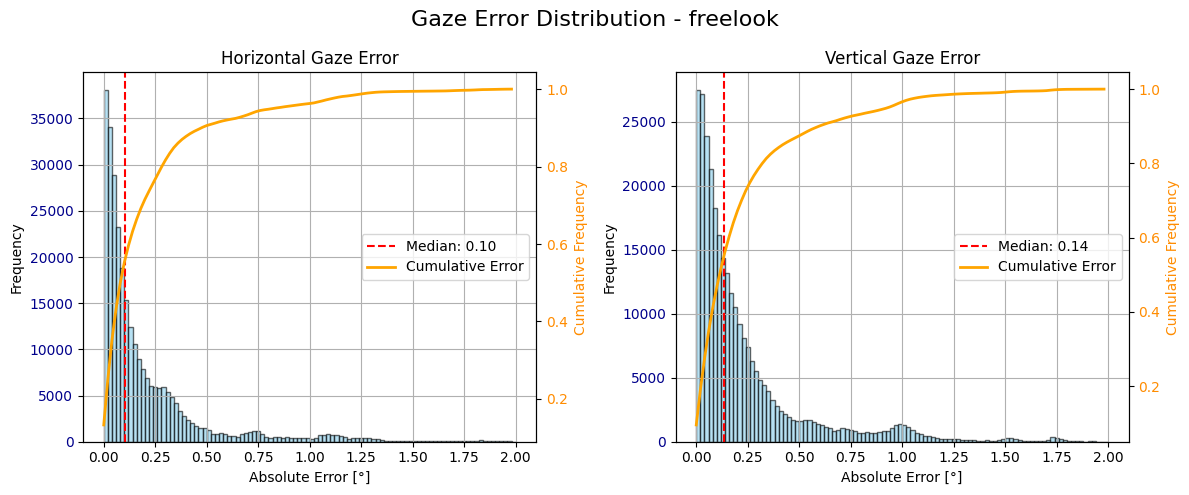

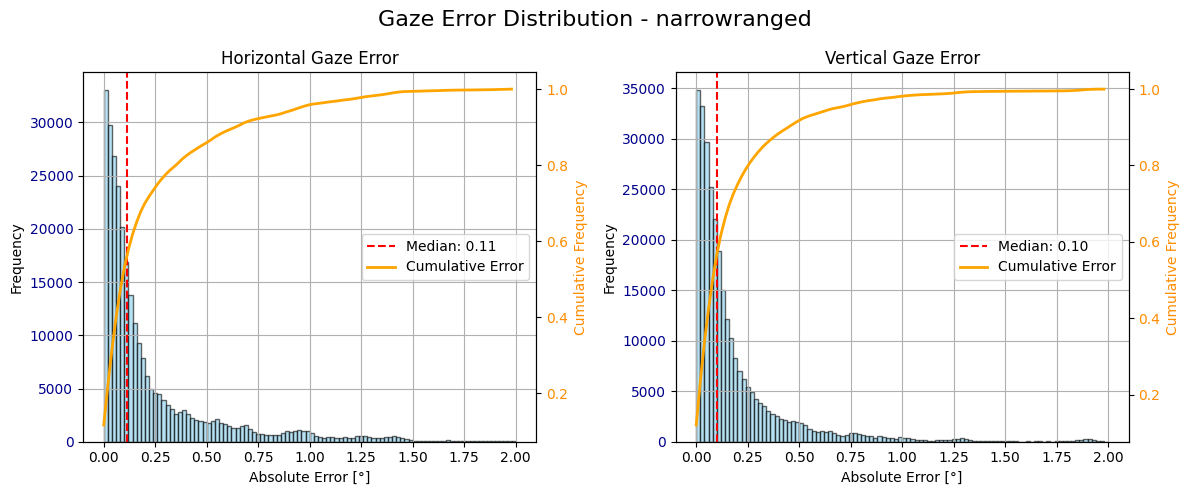

In [313]:
import matplotlib.pyplot as plt
import numpy as np

def plot_error_distribution(ax, data, title):
    data = data[~np.isnan(data)]
    median = np.nanmedian(data)
    count, bins, _ = ax.hist(data, bins=100, range=(0, 2), color='skyblue', edgecolor='black', alpha=0.6)
    ax.axvline(median, color='red', ls='--', lw=1.5, label=f'Median: {median:.2f}')
    ax.set(title=title, xlabel='Absolute Error [°]', ylabel='Frequency')
    ax.tick_params(axis='y', labelcolor='darkblue')
    ax.grid(True)

    cdf = np.cumsum(count / np.sum(count))
    ax_twin = ax.twinx()
    line, = ax_twin.plot(bins[:-1], cdf, color='orange', lw=2, label='Cumulative Error')
    ax_twin.set_ylabel('Cumulative Frequency', color='darkorange')
    ax_twin.tick_params(axis='y', labelcolor='darkorange')

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_twin.get_legend_handles_labels()
    ax.legend(h1 + [line], l1 + [l2[0]], loc='center right')

for calib in calib_all:
    err_x, err_y = gaze_error_all[calib]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    plot_error_distribution(ax1, err_x, 'Horizontal Gaze Error')
    plot_error_distribution(ax2, err_y, 'Vertical Gaze Error')
    fig.suptitle(f'Gaze Error Distribution - {calib}', fontsize=16)
    plt.tight_layout()
    plt.show()

Visualization

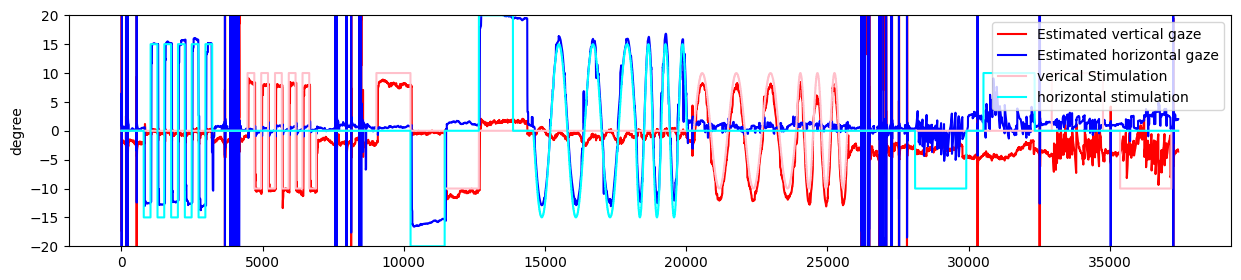

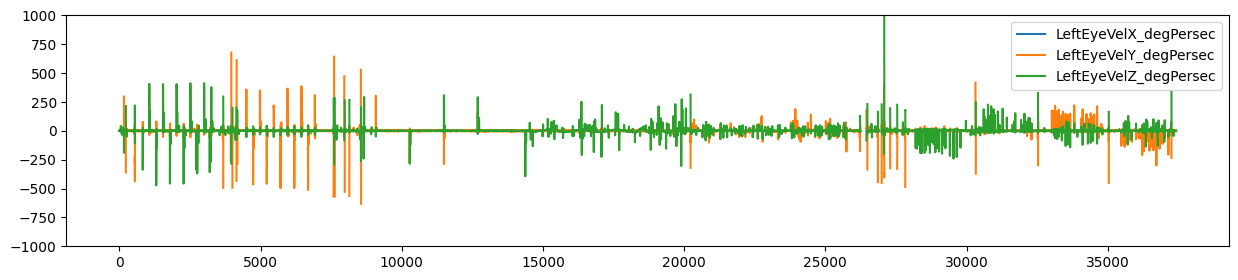

In [315]:

plt.figure(figsize = (15,3))
plt.plot(df_GT.LeftEyeVer_Deg, label = "Estimated vertical gaze", color = "red")
plt.plot(df_GT.LeftEyeHor_Deg, label = "Estimated horizontal gaze", color = "blue")
plt.plot(-df_GT.TargetVer_Units, label = "verical Stimulation", color = "pink")
plt.plot(df_GT.TargetHor_Units, label = "horizontal stimulation", color = "cyan")
plt.ylim([-20,20])
plt.ylabel('degree')
plt.legend()

plt.figure(figsize = (15,3))
plt.plot(df_GT.LeftEyeVelX_degPersec, label = "LeftEyeVelX_degPersec")
plt.plot(df_GT.LeftEyeVelY_degPersec, label = "LeftEyeVelY_degPersec")
plt.plot(df_GT.LeftEyeVelZ_degPersec, label = "LeftEyeVelZ_degPersec")
plt.ylim([-1000,1000])
# plt.plot(gaze_x_GT_mov, label = 'GT')
plt.legend()

### Digital Biomarker Extraction

In [588]:
import numpy as np, pandas as pd
from scipy.ndimage import label, gaussian_filter1d
from scipy.stats import linregress
from scipy.signal import medfilt, savgol_filter
from collections import defaultdict

# --- Utility Functions ---
def suppress_n(mask, n=30):
    labeled, _ = label(mask.astype(bool))
    for r in np.unique(labeled)[1:]:
        mask[np.where(labeled == r)[0][:n]] = False
    return mask

def interpolate_nans(gaze):
    x = gaze.copy()
    if not isinstance(x, np.ndarray): x = np.array(x)
    if not np.any(np.isnan(x)): return x
    mask = ~np.isnan(x)
    if not np.any(mask): return x
    x[np.isnan(x)] = np.interp(np.flatnonzero(np.isnan(x)), np.flatnonzero(mask), x[mask])
    return x

from scipy.interpolate import UnivariateSpline
def interpolate_sinusoidal_robust(signal, s=0.5):
    if np.count_nonzero(~np.isnan(signal)) < 2:
        return signal.copy()
    x = np.arange(len(signal))
    valid = ~np.isnan(signal)
    spline = UnivariateSpline(x[valid], signal[valid], s=s)
    interp = spline(x)
    # Fill leading and trailing NaNs with nearest known values
    first, last = np.argmax(valid), len(signal) - np.argmax(valid[::-1]) - 1
    interp[:first] = signal[valid][0]
    interp[last+1:] = signal[valid][-1]
    return np.where(valid, signal, interp)

def exclude_jitter(x, window=30, polyorder=3):
    return savgol_filter(x, window_length=window, polyorder=polyorder, mode='nearest')

def moving_average(signal, window_size=5):
    if window_size < 1:
        raise ValueError("window_size must be >= 1")
    return np.convolve(signal, np.ones(window_size) / window_size, mode='same')

def compute_amplitude(gaze, st, thr):
    x = gaze.copy()
    x[np.abs(x) > 20] = np.nan
    if np.sum(np.isnan(x))/len(x) > 0.80: return (np.nan, np.nan, np.nan)  #amp is computable more than velocity
    else:
        x = exclude_jitter(interpolate_nans(x))
        # vals = moving_average(x[suppress_n(st > thr) & ~np.isnan(x)], window_size=20)
        vals = x[suppress_n(st > thr) & ~np.isnan(x)]
        return (np.nanmedian(vals), *np.nanpercentile(vals, [25, 75]))

def compute_velocity(gaze, fps):
    x = gaze.copy()
    x[np.abs(x) > 20] = np.nan
    if np.sum(np.isnan(x))/len(x) > 0.8: return x, np.nan   #more than 80% of the data is NaN
    else:
        # x = exclude_jitter(interpolate_nans(x))
        # x = interpolate_nans(x)
        raw_vel =  fps * np.gradient(x, edge_order=2) if len(x) >= 3 else np.full_like(x, np.nan)
        raw_vel[np.abs(raw_vel) > 700] = np.nan
        raw_vel = moving_average(raw_vel, window_size=5)
        # raw_vel = inter]polate_nans(raw_vel)
    return raw_vel, np.nanmax(raw_vel)#np.nanpercentile(raw_vel, 99)

def compute_gain(stim, gaze, mask=None):
    x = gaze.copy()
    x[np.abs(x) > 20] = np.nan
    x = interpolate_sinusoidal_robust(exclude_jitter(x))
    if mask is None:
        valid = ~np.isnan(stim) & ~np.isnan(x)
    else:
        valid = (~np.isnan(stim) & ~np.isnan(x) & mask)
    return linregress(stim[valid], x[valid]).slope if valid.sum() >= 5 else np.nan
    
def compute_SPV(gaze, fs, fc=30):   #Fs is sampling frequency, fc is cutoff frequency
    x = gaze.copy()
    x[(x > np.nanquantile(x, 0.985)) | (x < np.nanquantile(x, 0.025))] = np.nan
    if np.sum(np.isnan(x))/len(x) > 0.8: return x, np.nan   #more than 80% of the data is NaN
    else:
        v = np.gradient(interpolate_nans(x), edge_order=2) * fs
        vf = gaussian_filter1d(v, sigma=fs / (2 * np.pi * fc), mode='nearest')
        vf[np.abs(np.gradient(vf, edge_order=2) * fs) > 700] = np.nan
        vf = interpolate_nans(vf)
        win = int(0.5 * fs)
        if win % 2 == 0: win += 1
        v_med = medfilt(vf, kernel_size=win)
    return v_med, np.nanmedian(v_med)

# --- Setup ---
fps = 120.82
marker_results = defaultdict(lambda: defaultdict(dict))
M_opt_all = M_opt_PL
thr_confidence = 0.96
calib_all = ["calibME"]
for sub in tqdm(subjects):
    for calib in calib_all:
        row = df_best_PL.query("subject == @sub and calib == @calib").iloc[0]
        df_GT, df_PL = pd.read_csv(row.GT_path), pd.read_csv(row.PL_path)[-len(pd.read_csv(row.GT_path)):]
        # GT_x, GT_y = gaze_extract_GT(df_GT)
        # GT_y = -GT_y
        GT_x, GT_y = gaze_extract_GT_v2(df_GT)
        ST_x, ST_y = df_GT.TargetHor_Units.values, df_GT.TargetVer_Units.values

        # --- Decode PL gaze ---
        normals = np.vstack([eval(x)['normal'] for x in df_PL['circle_3d']]).T.astype(np.float32)
        conf = df_PL['confidence'].values
        valid = ~np.isnan(GT_x) & ~np.isnan(GT_y) & ~np.isnan(normals).any(0)
        M = M_opt_all[calib][subjects.index(sub)]
        px, py = cart2sph_batch_PL(M @ normals[:, valid])
        px[conf[valid] < thr_confidence], py[conf[valid] < thr_confidence] = np.nan, np.nan
        px -= np.nanmean(px); py -= np.nanmean(py)
        PL_x, PL_y = np.full_like(GT_x, np.nan), np.full_like(GT_y, np.nan)
        PL_x[valid], PL_y[valid] = px, py

        esp = 50
        sac = st_range_dicts[sub]['saccades']
        sm = st_range_dicts[sub]['smooth_pursuit']
        okn = st_range_dicts[sub]['optokinetic_nystagmus']

        # --- Saccades ---
        sac_ranges = {
            'x': slice(sac['H'][0]-esp, sac['H'][1]+esp),
            'y': slice(sac['V'][0]-esp, sac['V'][1]+esp)
        }
        amp = {}
        vel = {}
        sac_GT_hor, sac_GT_ver = GT_x[sac_ranges['x']], GT_y[sac_ranges['y']]
        sac_PL_hor, sac_PL_ver = PL_x[sac_ranges['x']], PL_y[sac_ranges['y']]
        sac_ST_hor, sac_ST_ver  = ST_x[sac_ranges['x']], ST_y[sac_ranges['y']]
        amp['GT_right'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(sac_GT_hor, sac_ST_hor, 10)))
        amp['GT_left'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(-sac_GT_hor, -sac_ST_hor, 10)))
        amp['GT_up'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(sac_GT_ver, sac_ST_ver, 7)))
        amp['GT_down'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(-sac_GT_ver, -sac_ST_ver, 7)))
        #some right - left, up-down are not symetric, shouldn't mix them
        amp['GT_hor'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(np.abs(sac_GT_hor), np.abs(sac_ST_hor), 10)))
        amp['GT_ver'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(np.abs(sac_GT_ver), np.abs(sac_ST_ver), 7)))

        amp['PL_right'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(sac_PL_hor, sac_ST_hor, 10)))
        amp['PL_left'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(-sac_PL_hor, -sac_ST_hor, 10)))
        amp['PL_up'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(sac_PL_ver, sac_ST_ver, 7)))
        amp['PL_down'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(-sac_PL_ver, -sac_ST_ver, 7)))
        amp['PL_hor'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(np.abs(sac_PL_hor), np.abs(sac_ST_hor), 10)))
        amp['PL_ver'] = dict(zip(['median', 'Q1', 'Q3'], compute_amplitude(np.abs(sac_PL_ver), np.abs(sac_ST_ver), 7)))

        _, vel['GT_right'] = compute_velocity(sac_GT_hor, fps)
        _, vel['GT_left'] = compute_velocity(-sac_GT_hor, fps)
        _, vel['GT_up'] = compute_velocity(sac_GT_ver, fps)
        _, vel['GT_down'] = compute_velocity(-sac_GT_ver, fps)
        _, vel['GT_hor'] = compute_velocity(np.abs(sac_GT_hor), fps)
        _, vel['GT_ver'] = compute_velocity(np.abs(sac_GT_ver), fps)
        _, vel['PL_right'] = compute_velocity(sac_PL_hor, fps)
        _, vel['PL_left'] = compute_velocity(-sac_PL_hor, fps)
        _, vel['PL_up'] = compute_velocity(sac_PL_ver, fps)
        _, vel['PL_down'] = compute_velocity(-sac_PL_ver, fps)
        _, vel['PL_hor'] = compute_velocity(np.abs(sac_PL_hor), fps)
        _, vel['PL_ver'] = compute_velocity(np.abs(sac_PL_ver), fps)

        # --- Smooth Pursuit ---
        sm_ranges = {
            'x': slice(sm['H'][0], sm['H'][1]),
            'y': slice(sm['V'][0], sm['V'][1]),
            'x_slow': slice(sm['H'][0], sm['H'][0] + int(30 * fps)),
            'y_slow': slice(sm['V'][0], sm['V'][0] + int(30 * fps)),
            'x_fast': slice(sm['H'][0] + int(30 * fps), sm['H'][0] + int(30 * fps) + int(15 * fps)),
            'y_fast': slice(sm['V'][0] + int(30 * fps), sm['V'][0] + int(30 * fps) + int(15 * fps)),
        }
        # Horizontally cropped signals
        sm_GT_x, sm_GT_y = GT_x[sm_ranges['x']], GT_y[sm_ranges['y']]
        sm_ST_x, sm_ST_y = ST_x[sm_ranges['x']], ST_y[sm_ranges['y']]
        sm_PL_x, sm_PL_y = PL_x[sm_ranges['x']], PL_y[sm_ranges['y']]

        sm_slow_GT_x, sm_slow_GT_y = GT_x[sm_ranges['x_slow']], GT_y[sm_ranges['y_slow']]
        sm_fast_GT_x, sm_fast_GT_y = GT_x[sm_ranges['x_fast']], GT_y[sm_ranges['y_fast']]
        sm_slow_ST_x, sm_slow_ST_y = ST_x[sm_ranges['x_slow']], ST_y[sm_ranges['y_slow']]
        sm_fast_ST_x, sm_fast_ST_y = ST_x[sm_ranges['x_fast']], ST_y[sm_ranges['y_fast']]
        sm_slow_PL_x, sm_slow_PL_y = PL_x[sm_ranges['x_slow']], PL_y[sm_ranges['y_slow']]
        sm_fast_PL_x, sm_fast_PL_y = PL_x[sm_ranges['x_fast']], PL_y[sm_ranges['y_fast']]


        sp = {}
        sp['GT_hor'] = compute_gain(sm_ST_x, sm_GT_x)
        sp['GT_ver'] = compute_gain(sm_ST_y, sm_GT_y)
        sp['GT_slow_hor'] = compute_gain(sm_slow_ST_x, sm_slow_GT_x)
        sp['GT_slow_ver'] = compute_gain(sm_slow_ST_y, sm_slow_GT_y)
        sp['GT_fast_hor'] = compute_gain(sm_fast_ST_x, sm_fast_GT_x)
        sp['GT_fast_ver'] = compute_gain(sm_fast_ST_y, sm_fast_GT_y)
        sp['GT_right'] = compute_gain(sm_ST_x, sm_GT_x, sm_ST_x > 0)
        sp['GT_left'] = compute_gain(sm_ST_x, sm_GT_x, sm_ST_x < 0)
        sp['GT_up'] = compute_gain(sm_ST_y, sm_GT_y, sm_ST_y > 0)
        sp['GT_down'] = compute_gain(sm_ST_y, sm_GT_y, sm_ST_y < 0)

        sp['GT_slow_right'] = compute_gain(sm_slow_ST_x, sm_slow_GT_x, sm_slow_ST_x > 0)
        sp['GT_slow_left'] = compute_gain(sm_slow_ST_x, sm_slow_GT_x, sm_slow_ST_x < 0)
        sp['GT_slow_up'] = compute_gain(sm_slow_ST_y, sm_slow_GT_y, sm_slow_ST_y > 0)
        sp['GT_slow_down'] = compute_gain(sm_slow_ST_y, sm_slow_GT_y, sm_slow_ST_y < 0)
        sp['GT_fast_right'] = compute_gain(sm_fast_ST_x, sm_fast_GT_x, sm_fast_ST_x > 0)
        sp['GT_fast_left'] = compute_gain(sm_fast_ST_x, sm_fast_GT_x, sm_fast_ST_x < 0)
        sp['GT_fast_up'] = compute_gain(sm_fast_ST_y, sm_fast_GT_y, sm_fast_ST_y > 0)
        sp['GT_fast_down'] = compute_gain(sm_fast_ST_y, sm_fast_GT_y, sm_fast_ST_y < 0)

        sp['PL_hor'] = compute_gain(sm_ST_x, sm_PL_x)
        sp['PL_ver'] = compute_gain(sm_ST_y, sm_PL_y)
        sp['PL_slow_hor'] = compute_gain(sm_slow_ST_x, sm_slow_PL_x)
        sp['PL_slow_ver'] = compute_gain(sm_slow_ST_y, sm_slow_PL_y)
        sp['PL_fast_hor'] = compute_gain(sm_fast_ST_x, sm_fast_PL_x)
        sp['PL_fast_ver'] = compute_gain(sm_fast_ST_y, sm_fast_PL_y)
        sp['PL_right'] = compute_gain(sm_ST_x, sm_PL_x, sm_ST_x > 0)
        sp['PL_left'] = compute_gain(sm_ST_x, sm_PL_x, sm_ST_x < 0)
        sp['PL_up'] = compute_gain(sm_ST_y, sm_PL_y, sm_ST_y > 0)
        sp['PL_down'] = compute_gain(sm_ST_y, sm_PL_y, sm_ST_y < 0)

        sp['PL_slow_right'] = compute_gain(sm_slow_ST_x, sm_slow_PL_x, sm_slow_ST_x > 0)
        sp['PL_slow_left'] = compute_gain(sm_slow_ST_x, sm_slow_PL_x, sm_slow_ST_x < 0)
        sp['PL_slow_up'] = compute_gain(sm_slow_ST_y, sm_slow_PL_y, sm_slow_ST_y > 0)
        sp['PL_slow_down'] = compute_gain(sm_slow_ST_y, sm_slow_PL_y, sm_slow_ST_y < 0)
        sp['PL_fast_right'] = compute_gain(sm_fast_ST_x, sm_fast_PL_x, sm_fast_ST_x > 0)
        sp['PL_fast_left'] = compute_gain(sm_fast_ST_x, sm_fast_PL_x, sm_fast_ST_x < 0)
        sp['PL_fast_up'] = compute_gain(sm_fast_ST_y, sm_fast_PL_y, sm_fast_ST_y > 0)
        sp['PL_fast_down'] = compute_gain(sm_fast_ST_y, sm_fast_PL_y, sm_fast_ST_y < 0)

        # --- OKN ---
        okn_ranges = {
            'x': slice(okn['H'][0], okn['H'][1]),
            'y': slice(okn['V'][0], okn['V'][1]),
        }

        okn_GT_x, okn_GT_y = GT_x[okn_ranges['x']], GT_y[okn_ranges['y']]
        okn_ST_x, okn_ST_y = ST_x[okn_ranges['x']], ST_y[okn_ranges['y']]
        okn_PL_x, okn_PL_y = PL_x[okn_ranges['x']], PL_y[okn_ranges['y']]

        spv = {}
        _, spv['GT_hor'] = compute_SPV(np.abs(okn_GT_x), fps)
        _, spv['PL_hor'] = compute_SPV(np.abs(okn_PL_x), fps)
        _, spv['GT_ver'] = compute_SPV(np.abs(okn_GT_y), fps)
        _, spv['PL_ver'] = compute_SPV(np.abs(okn_PL_y), fps)

        _, spv['GT_up'] = compute_SPV(okn_GT_y[okn_ST_y > 0], fps)
        _, spv['PL_up'] = compute_SPV(okn_PL_y[okn_ST_y > 0], fps)
        _, spv['GT_down'] = compute_SPV(okn_GT_y[okn_ST_y < 0], fps)
        _, spv['PL_down'] = compute_SPV(okn_PL_y[okn_ST_y < 0], fps)
        _, spv['GT_right'] = compute_SPV(okn_GT_x[okn_ST_x > 0], fps)
        _, spv['PL_right'] = compute_SPV(okn_PL_x[okn_ST_x > 0], fps)
        _, spv['GT_left'] = compute_SPV(okn_GT_x[okn_ST_x < 0], fps)
        _, spv['PL_left'] = compute_SPV(okn_PL_x[okn_ST_x < 0], fps)

        sac_ranges = {
            'x': slice(sac['H'][0]-esp, sac['H'][1]+esp),
            'y': slice(sac['V'][0]-esp, sac['V'][1]+esp)
        }

        marker_results[sub][calib] = {
            'saccades': {
                'amplitude': amp,
                'velocity': vel,
                'plot_data': {
                    'x': {'GT': sac_GT_hor,'ST': sac_ST_hor,'PL': sac_PL_hor},
                    'y': {'GT': sac_GT_ver,'ST': sac_ST_ver,'PL': sac_PL_ver},
                }
            },
            'smooth_pursuit': {
                **sp,
                'plot_data': {
                    'x': {'GT': sm_GT_x, 'ST': sm_ST_x, 'PL': sm_PL_x},
                    'y': {'GT': sm_GT_y, 'ST': sm_ST_y, 'PL': sm_PL_y}
                }
            },
            'optokinetic_nystagmus': {
                **spv,
                'plot_data': {
                    'x': {'GT': okn_GT_x, 'ST': okn_ST_x, 'PL': okn_PL_x},
                    'y': {'GT': okn_GT_y, 'ST': okn_ST_y, 'PL': okn_PL_y}
                }
            }
        }

100%|██████████| 19/19 [00:35<00:00,  1.87s/it]


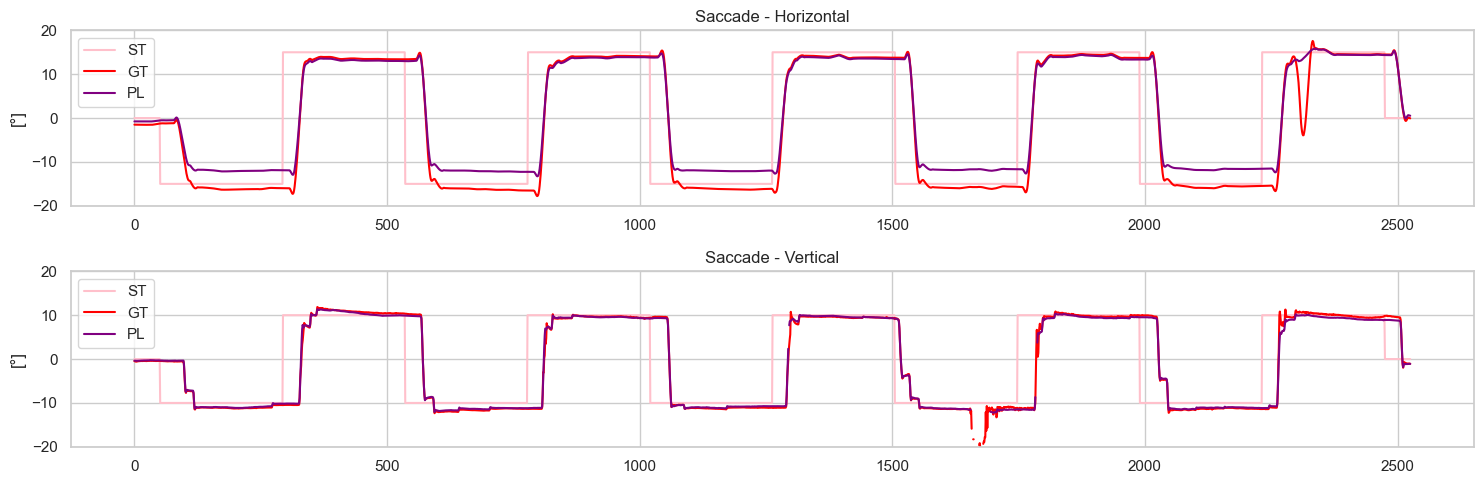

right amplitude: GT: {'median': 13.955011070278822, 'Q1': 13.480895861771165, 'Q3': 14.26257737082529}, PL: {'median': 13.666581741267194, 'Q1': 13.125861207190265, 'Q3': 13.991132542555468}
left amplitude: GT: {'median': 15.933540130600207, 'Q1': 15.556560341010252, 'Q3': 16.187503443150746}, PL: {'median': 11.871792427293023, 'Q1': 11.607543868190044, 'Q3': 12.037205048267083}
up amplitude: GT: {'median': 9.690719294621582, 'Q1': 9.479393107593005, 'Q3': 10.226611546483335}, PL: {'median': 9.546459903232106, 'Q1': 9.34290760269008, 'Q3': 9.886861009052929}
down amplitude: GT: {'median': 11.232370263111555, 'Q1': 11.071397452207183, 'Q3': 11.376307608898976}, PL: {'median': 11.072039597743673, 'Q1': 10.817274903423694, 'Q3': 11.277801946799416}


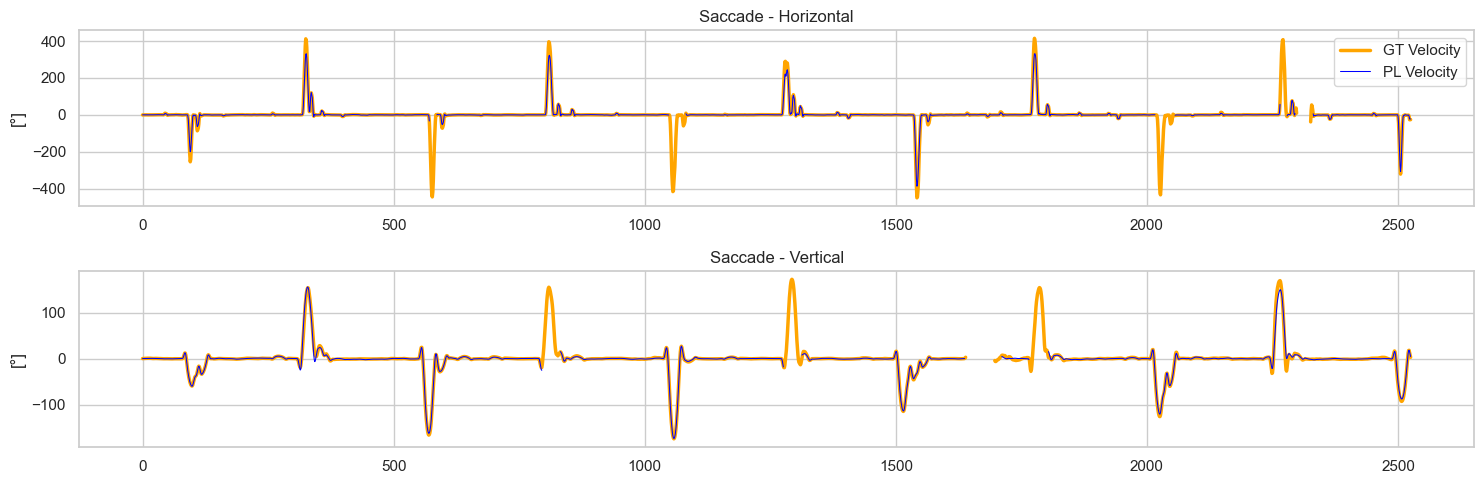

right velocity: GT: 415.19739280758785, PL: 331.66747641734304
left velocity: GT: 450.363596445093, PL: 387.3852838308227
up velocity: GT: 508.4181318424524, PL: 375.08813681366087
down velocity: GT: 369.5579944309527, PL: 362.9404221448559


In [597]:
from scipy.signal import savgol_filter

# Top GT-PL mismatches in Saccade Amplitude:
#     Sample         GT         PL Direction  abs_error
# 53      17  15.933540  11.871792      Left   4.061748
# 67      12  15.125901  16.739577     Right   1.613676
# 48      12  15.463679  16.837474      Left   1.373795
# 12      13  11.242155  12.103002        Up   0.860847
# 42       6  12.740477  13.570651      Left   0.830174

# Top GT-PL mismatches in Saccade Velocity:
#     Sample          GT          PL Direction   abs_error
# 26       7  670.938411   18.197306      Down  652.741106
# 7        7  654.904532  267.224928        Up  387.679604
# 6        6  685.270410  357.881884        Up  327.388526
# 31      12  660.571771  408.593779      Down  251.977993
# 17      17  671.018233  441.978414        Up  229.039819

# subject 7 has lots of NaN value which will be excluded 
sub = subjects[17]
sac_plot = marker_results[sub][calib]['saccades']['plot_data']
def exclude_jitter(x, window=30, polyorder=3):
    return savgol_filter(x, window_length=window, polyorder=polyorder, mode='nearest')

sac_plot = marker_results[sub][calib]['saccades']['plot_data']
GT_x = sac_plot['x']['GT'].copy()
PL_x = sac_plot['x']['PL'].copy()
GT_y = sac_plot['y']['GT'].copy()
PL_y = sac_plot['y']['PL'].copy()
GT_x[np.abs(GT_x) > 20] = np.nan
GT_y[np.abs(GT_y) > 20] = np.nan
PL_x[np.abs(PL_x) > 20] = np.nan
PL_y[np.abs(PL_y) > 20] = np.nan
plt.figure(figsize=(15, 5))


# for i, axis in enumerate(['x', 'y']):
ax = plt.subplot(2, 1, 1)
ax.plot(sac_plot['x']['ST'], label='ST', color='cyan' if i == 0 else 'pink')
# ax.plot(sac_plot['x']['GT'], label='GT', color='blue' if i == 0 else 'red')
# ax.plot(sac_plot['x']['PL'], label='PL', color='green' if i == 0 else 'purple')
ax.plot(exclude_jitter(interpolate_nans(GT_x)), label='GT', color='blue' if i == 0 else 'red')
ax.plot(exclude_jitter(interpolate_nans(PL_x)), label='PL', color='green' if i == 0 else 'purple')
ax.set(ylim=[-20, 20], title=f"Saccade - Horizontal", ylabel='[°]')
ax.legend()

ax = plt.subplot(2, 1, 2)
ax.plot(sac_plot['y']['ST'], label='ST', color='cyan' if i == 0 else 'pink')
ax.plot(sac_plot['y']['GT'], label='GT', color='blue' if i == 0 else 'red')
ax.plot(sac_plot['y']['PL'], label='PL', color='green' if i == 0 else 'purple')
# ax.plot(exclude_jitter(GT_y), label='GT', color='blue' if i == 0 else 'red')
# ax.plot(exclude_jitter(PL_y), label='PL', color='green' if i == 0 else 'purple')
ax.set(ylim=[-20, 20], title=f"Saccade - Vertical", ylabel='[°]')
ax.legend()
plt.tight_layout(); plt.show()
print(f"right amplitude: GT: {marker_results[sub][calib]['saccades']['amplitude']['GT_right']}, PL: {marker_results[sub][calib]['saccades']['amplitude']['PL_right']}")
print(f"left amplitude: GT: {marker_results[sub][calib]['saccades']['amplitude']['GT_left']}, PL: {marker_results[sub][calib]['saccades']['amplitude']['PL_left']}")
print(f"up amplitude: GT: {marker_results[sub][calib]['saccades']['amplitude']['GT_up']}, PL: {marker_results[sub][calib]['saccades']['amplitude']['PL_up']}")
print(f"down amplitude: GT: {marker_results[sub][calib]['saccades']['amplitude']['GT_down']}, PL: {marker_results[sub][calib]['saccades']['amplitude']['PL_down']}")

sac_plot = marker_results[sub][calib]['saccades']['plot_data']
plt.figure(figsize=(15, 5))
# for i, axis, GT_ax, PL_ax in enumerate(zip(['x', 'y'], [GT_x, GT_y], [PL_x, PL_y])):
ax = plt.subplot(2, 1, 1)
GT_velocity, _ = compute_velocity((GT_x), fps)
PL_velocity, _ = compute_velocity((PL_x), fps)
# ax.plot(sac_plot[axis]['GT']*10, label='GT', color='purple')
ax.plot(GT_velocity, label='GT Velocity', color='orange', linewidth=2.5)
ax.plot(PL_velocity, label='PL Velocity', color='blue', linewidth=0.75)
# ax.plot(smooth_gaze(sac_plot[axis]['PL']), label='PL', color='green' if i == 0 else 'purple')
ax.set(title=f"Saccade - Horizontal", ylabel='[°]')
# ax.set_xlim([500, 1800])
ax.legend()

ax = plt.subplot(2, 1, 2)
GT_velocity, _ = compute_velocity(exclude_jitter(GT_y), fps)
PL_velocity, _ = compute_velocity(exclude_jitter(PL_y), fps)
# ax.plot(sac_plot[axis]['GT']*10, label='GT', color='purple')
ax.plot(GT_velocity, label='GT Velocity', color='orange', linewidth=2.5)
ax.plot(PL_velocity, label='PL Velocity', color='blue', linewidth=0.75)
# ax.plot(smooth_gaze(sac_plot[axis]['PL']), label='PL', color='green' if i == 0 else 'purple')
ax.set(title=f"Saccade - Vertical", ylabel='[°]')
# ax.set_xlim([500, 1800])
plt.tight_layout(); plt.show()

print(f"right velocity: GT: {marker_results[sub][calib]['saccades']['velocity']['GT_right']}, PL: {marker_results[sub][calib]['saccades']['velocity']['PL_right']}")
print(f"left velocity: GT: {marker_results[sub][calib]['saccades']['velocity']['GT_left']}, PL: {marker_results[sub][calib]['saccades']['velocity']['PL_left']}")
print(f"up velocity: GT: {marker_results[sub][calib]['saccades']['velocity']['GT_up']}, PL: {marker_results[sub][calib]['saccades']['velocity']['PL_up']}")
print(f"down velocity: GT: {marker_results[sub][calib]['saccades']['velocity']['GT_down']}, PL: {marker_results[sub][calib]['saccades']['velocity']['PL_down']}")




right: GT: 1.0250472041166603, PL: 0.9115406096162814
left: GT: 0.9734913429286441, PL: 0.7641392921195675
up: GT: 1.0601665016296156, PL: 1.0335159209816212
down: GT: 1.122294766681836, PL: 1.0999170263237166


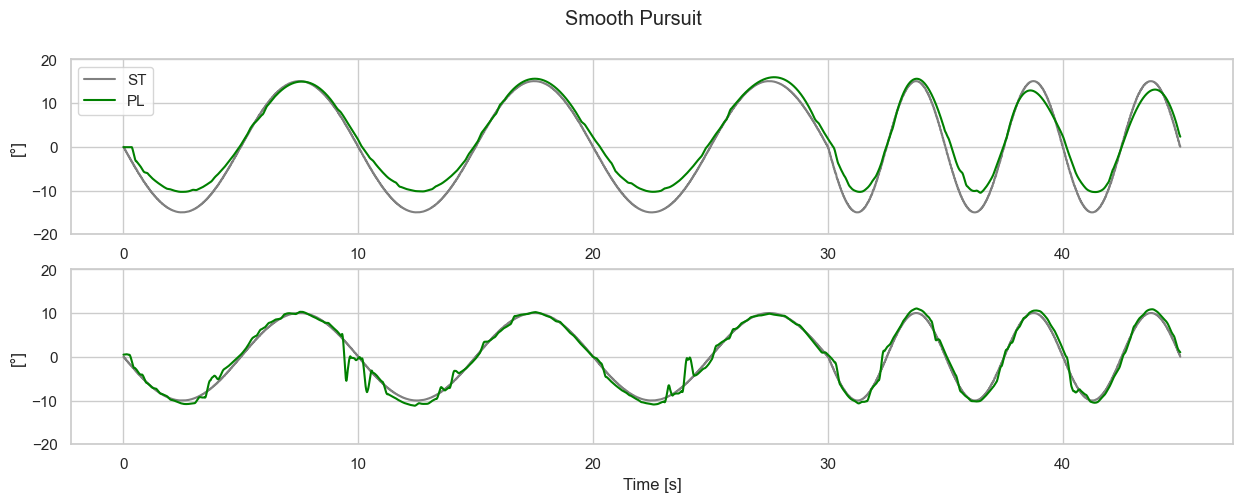

In [478]:
# --- Smooth Pursuit Plot ---
sub = subjects[17]  #17
# plt.plot(gaze_x_GT_all)
# Top GT-PL mismatches in Smooth Pursuit Gain:
#     Sample        GT        PL Direction  abs_error
# 74      17  1.025760  0.436951     Right   0.588810
# 55      17  0.973454  0.764524      Left   0.208930
# 65       8  1.004638  0.915829     Right   0.088809
# 13      13  0.929964  1.014684        Up   0.084720
# 26       7  1.044974  0.967153      Down   0.077820

sp_plot = marker_results[sub][calib]['smooth_pursuit']['plot_data']
plt.figure(figsize=(15, 5))
plt.suptitle("Smooth Pursuit")
plt.subplot(2, 1, 1)
tp = np.arange(sp_plot['x']['ST'].shape[0]) / fps

GT_x = sp_plot['x']['GT'].copy()
PL_x = sp_plot['x']['PL'].copy()
GT_y = sp_plot['y']['GT'].copy()
PL_y = sp_plot['y']['PL'].copy()
GT_x[GT_x > 20] = np.nan
GT_y[GT_y > 20] = np.nan
PL_x[PL_x > 20] = np.nan
PL_y[PL_y > 20] = np.nan

from scipy.interpolate import UnivariateSpline
def interpolate_sinusoidal_robust(signal, s=0.5):
    if np.count_nonzero(~np.isnan(signal)) < 2:
        return signal.copy()
    x = np.arange(len(signal))
    valid = ~np.isnan(signal)
    spline = UnivariateSpline(x[valid], signal[valid], s=s)
    interp = spline(x)
    # Fill leading and trailing NaNs with nearest known values
    first, last = np.argmax(valid), len(signal) - np.argmax(valid[::-1]) - 1
    interp[:first] = signal[valid][0]
    interp[last+1:] = signal[valid][-1]
    return np.where(valid, signal, interp)

plt.plot(tp, sp_plot['x']['ST'], label='ST', color='gray')
# plt.plot(tp, exclude_jitter(GT_x), label='GT', color='blue')
# plt.plot(tp, sp_plot['x']['PL'], label='PL', color='lightgreen')
plt.plot(tp, interpolate_sinusoidal_robust(exclude_jitter(PL_x)), label='PL', color='green')
plt.ylim([-20, 20])
plt.legend()
plt.ylabel('[°]')
plt.subplot(2, 1, 2)
tp = np.arange(sp_plot['y']['ST'].shape[0]) / fps
plt.plot(tp, sp_plot['y']['ST'], label='ST', color='gray')
# plt.plot(tp, exclude_jitter(GT_y), label='GT', color='blue')
# plt.plot(tp, sp_plot['y']['PL'], label='PL', color='lightgreen')
plt.plot(tp, interpolate_sinusoidal_robust(exclude_jitter(PL_y)), label='PL', color='green')
plt.ylim([-20, 20])
plt.xlabel("Time [s]")
plt.ylabel('[°]')

print(f"right: GT: {marker_results[sub][calib]['smooth_pursuit']['GT_right']}, PL: {marker_results[sub][calib]['smooth_pursuit']['PL_right']}")
print(f"left: GT: {marker_results[sub][calib]['smooth_pursuit']['GT_left']}, PL: {marker_results[sub][calib]['smooth_pursuit']['PL_left']}")
print(f"up: GT: {marker_results[sub][calib]['smooth_pursuit']['GT_up']}, PL: {marker_results[sub][calib]['smooth_pursuit']['PL_up']}")
print(f"down: GT: {marker_results[sub][calib]['smooth_pursuit']['GT_down']}, PL: {marker_results[sub][calib]['smooth_pursuit']['PL_down']}")

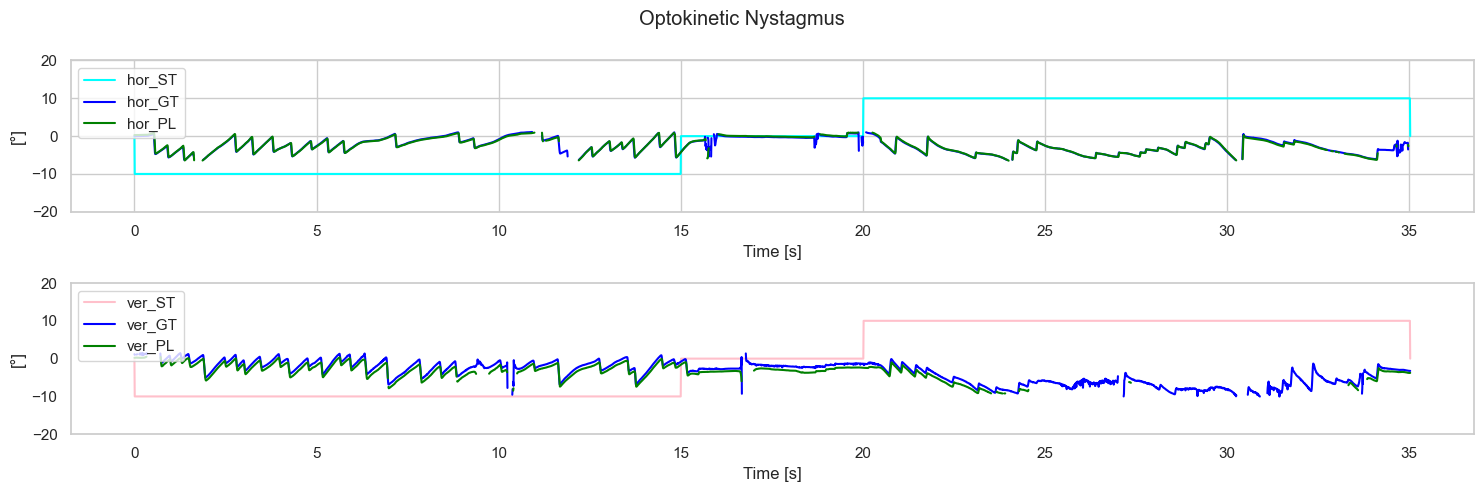

In [ ]:
# Top GT-PL mismatches in OKN SPV:
#     Sample        GT         PL Direction  abs_error
# 6        6 -4.256730   0.471415        Up   4.728145
# 55      17  9.275898   7.364418      Left   1.911481
# 74      17 -9.589566  -7.990230     Right   1.599335
# 4        4 -7.429324  -8.485040        Up   1.055716
# 46       8  9.578999  10.340851      Left   0.761852

def compute_SPV(x, fs, fc=30):   #Fs is sampling frequency, fc is cutoff frequency
    if len(x) < 3: return x, np.nan
    v = np.gradient(interpolate_nans(x), edge_order=2) * fs
    vf = gaussian_filter1d(v, sigma=fs / (2 * np.pi * fc), mode='nearest')
    vf[np.abs(np.gradient(vf, edge_order=2) * fs) > 700] = np.nan
    vf = interpolate_nans(vf)
    win = int(0.5 * fs)
    if win % 2 == 0: win += 1
    v_med = medfilt(vf, kernel_size=win)
    return v_med, np.nanmedian(v_med)

sub = subjects[6]
okn_plot = marker_results[sub][calib]['optokinetic_nystagmus']['plot_data']
plt.figure(figsize=(15, 5))
plt.suptitle("Optokinetic Nystagmus")
plt.subplot(2, 1, 1)
GT_x = okn_plot['x']['GT'].copy()
PL_x = okn_plot['x']['PL'].copy()
GT_x[(GT_x > np.nanquantile(GT_x, 0.985)) | (GT_x < np.nanquantile(GT_x, 0.025))] = np.nan
PL_x[(PL_x > np.nanquantile(PL_x, 0.985)) | (PL_x < np.nanquantile(PL_x, 0.025))] = np.nan
# GT_x, _ = compute_SPV(okn_plot['x']['GT'], fps)
# PL_x, _ = compute_SPV(okn_plot['x']['PL'], fps)
tp_okn = np.arange(okn_plot['x']['ST'].shape[0]) / fps
plt.plot(tp_okn, okn_plot['x']['ST'], label='hor_ST', color='cyan')
plt.plot(tp_okn, GT_x, label='hor_GT', color='blue')
plt.plot(tp_okn, PL_x, label='hor_PL', color='green')
# plt.plot(tp_okn, okn_plot['x']['GT'], label='hor_GT', color='blue')
# plt.plot(tp_okn, okn_plot['x']['PL'], label='hor_PL', color='green')
plt.ylabel('[°]')
plt.ylim([-20, 20])
plt.xlabel("Time [s]")
plt.legend()

plt.subplot(2, 1, 2)
GT_y = okn_plot['y']['GT'].copy()
PL_y = okn_plot['y']['PL'].copy()
GT_y[(GT_y > np.nanquantile(GT_y, 0.985)) | (GT_y < np.nanquantile(GT_y, 0.025))] = np.nan
PL_y[(PL_y > np.nanquantile(PL_y, 0.985)) | (PL_y < np.nanquantile(PL_y, 0.025))] = np.nan
# GT_y, _ = compute_SPV(okn_plot['y']['GT'], fps)
# PL_y, _ = compute_SPV(okn_plot['y']['PL'], fps)
tp_okn = np.arange(okn_plot['y']['ST'].shape[0]) / fps
plt.plot(tp_okn, okn_plot['y']['ST'], label='ver_ST', color='pink')
plt.plot(tp_okn, GT_y, label='ver_GT', color='blue')
plt.plot(tp_okn, PL_y, label='ver_PL', color='green')
# plt.plot(tp_okn, okn_plot['y']['GT'], label='ver_GT', color='red')
# plt.plot(tp_okn, okn_plot['y']['PL'], label='ver_PL', color='purple')
plt.xlabel("Time [s]")
plt.ylim([-20, 20])
plt.ylabel('[°]')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

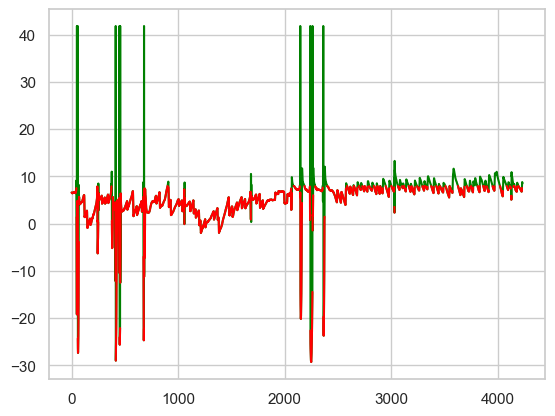

In [ ]:
GT_y = okn_plot['y']['GT'].copy()
plt.plot(GT_y, label = "GT vertical gaze", color = "green")
GT_y[GT_y > np.nanquantile(GT_y, 0.80)] = np.nan
GT_y[GT_y < np.nanquantile(GT_y, 0.2)] = np.nan
plt.plot(GT_y, label = "GT vertical gaze", color = "red")

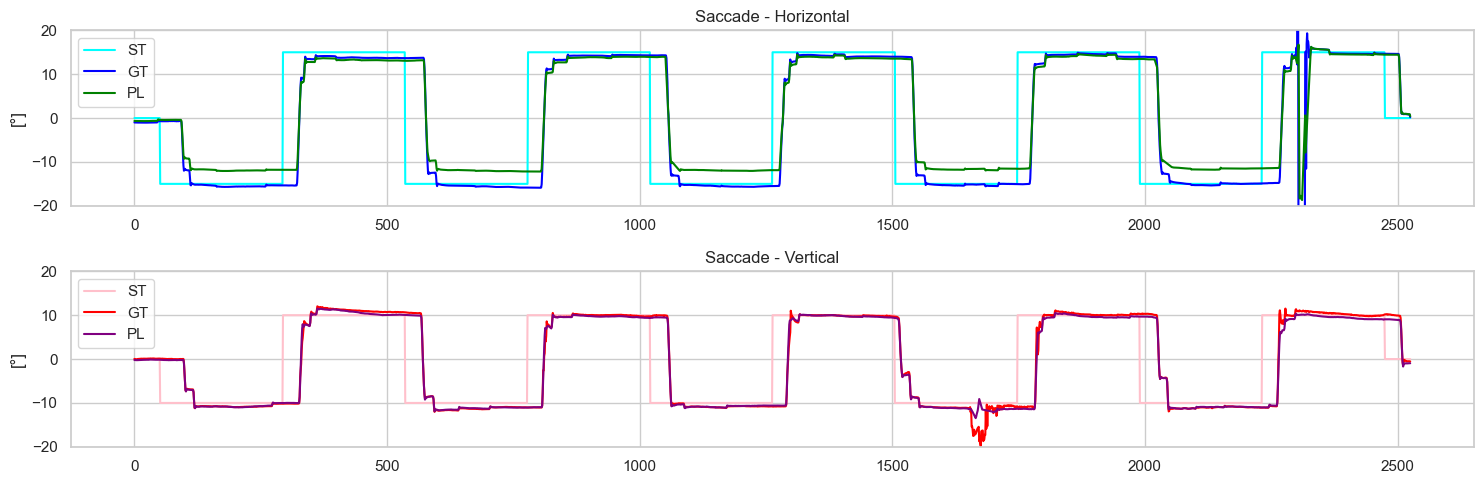

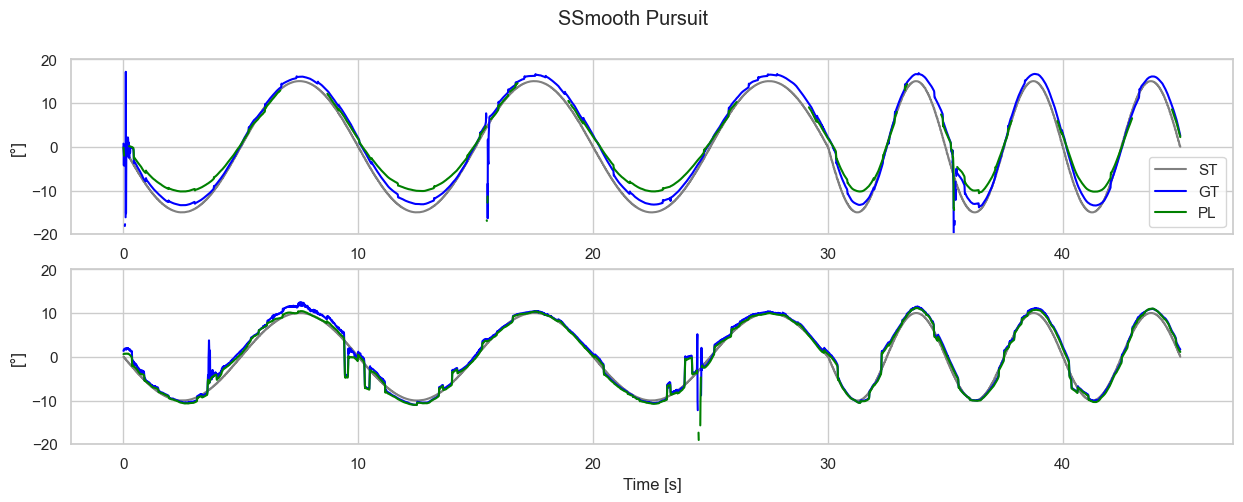

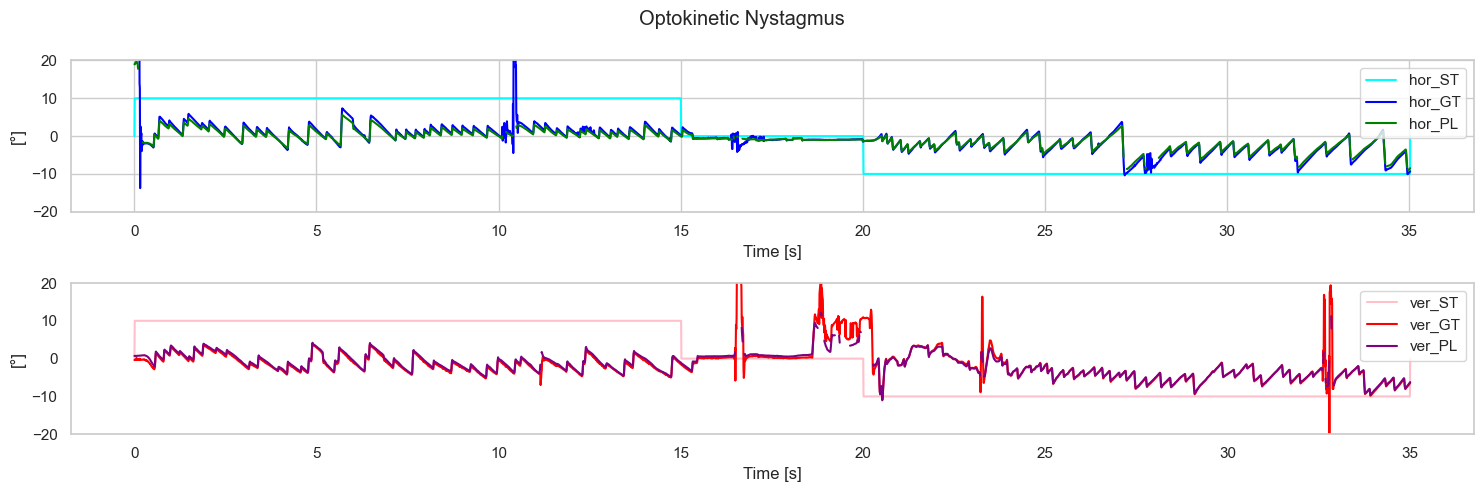

In [333]:
marker_results['ffilipopulus']['calibME'].keys()
# --- Plotting Saccade ---
# sub = 'jzhao'
sub = subjects[17]
sac_plot = marker_results[sub][calib]['saccades']['plot_data']
plt.figure(figsize=(15, 5))
for i, axis in enumerate(['x', 'y']):
    ax = plt.subplot(2, 1, i+1)
    ax.plot(sac_plot[axis]['ST'], label='ST', color='cyan' if i == 0 else 'pink')
    ax.plot(sac_plot[axis]['GT'], label='GT', color='blue' if i == 0 else 'red')
    ax.plot(sac_plot[axis]['PL'], label='PL', color='green' if i == 0 else 'purple')
    ax.set(ylim=[-20, 20], title=f"Saccade - {'Horizontal' if axis == 'x' else 'Vertical'}", ylabel='[°]')
    ax.legend()
plt.tight_layout(); plt.show()

# --- Smooth Pursuit Plot ---
sp_plot = marker_results[sub][calib]['smooth_pursuit']['plot_data']
plt.figure(figsize=(15, 5))
plt.suptitle("SSmooth Pursuit")
plt.subplot(2, 1, 1)
tp = np.arange(sp_plot['x']['ST'].shape[0]) / fps
plt.plot(tp, sp_plot['x']['ST'], label='ST', color='gray')
plt.plot(tp, sp_plot['x']['GT'], label='GT', color='blue')
plt.plot(tp, sp_plot['x']['PL'], label='PL', color='green')
plt.ylim([-20, 20])
plt.legend()
plt.ylabel('[°]')
plt.subplot(2, 1, 2)
tp = np.arange(sp_plot['y']['ST'].shape[0]) / fps
plt.plot(tp, sp_plot['y']['ST'], label='ST', color='gray')
plt.plot(tp, sp_plot['y']['GT'], label='GT', color='blue')
plt.plot(tp, sp_plot['y']['PL'], label='PL', color='green')
plt.ylim([-20, 20])
plt.xlabel("Time [s]")
plt.ylabel('[°]')

# plt.plot(gaze_x_GT_all)
okn_plot = marker_results[sub][calib]['optokinetic_nystagmus']['plot_data']
plt.figure(figsize=(15, 5))
plt.suptitle("Optokinetic Nystagmus")
plt.subplot(2, 1, 1)
tp_okn = np.arange(okn_plot['x']['ST'].shape[0]) / fps
plt.plot(tp_okn, -okn_plot['x']['ST'], label='hor_ST', color='cyan')
plt.plot(tp_okn, -okn_plot['x']['GT'], label='hor_GT', color='blue')
plt.plot(tp_okn, -okn_plot['x']['PL'], label='hor_PL', color='green')
plt.ylabel('[°]')
plt.ylim([-20, 20])
plt.xlabel("Time [s]")
plt.legend()

plt.subplot(2, 1, 2)
tp_okn = np.arange(okn_plot['y']['ST'].shape[0]) / fps
plt.plot(tp_okn, -okn_plot['y']['ST'], label='ver_ST', color='pink')
plt.plot(tp_okn, -okn_plot['y']['GT'], label='ver_GT', color='red')
plt.plot(tp_okn, -okn_plot['y']['PL'], label='ver_PL', color='purple')
plt.xlabel("Time [s]")
plt.ylim([-20, 20])
plt.ylabel('[°]')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [589]:
calib = "calibME"
sac_amp_keys = marker_results[sub][calib]['saccades']['amplitude'].keys()
sac_vel_keys = marker_results[sub][calib]['saccades']['velocity'].keys()
sm_keys = marker_results[sub][calib]['smooth_pursuit'].keys()
okn_keys = marker_results[sub][calib]['optokinetic_nystagmus'].keys()
# marker_results[sub][calib]['smooth_pursuit']['plot_data']
sac_amp_all = dict()
sac_vel_all = dict()
sm_all = dict()
okn_all = dict()
for key in sac_amp_keys:
    sac_amp_all[key] = []
    for sub in subjects:
        sac_amp_all[key].append(marker_results[sub][calib]['saccades']['amplitude'][key]['median'])

for key in sac_vel_keys:
    sac_vel_all[key] = []
    for sub in subjects:
        sac_vel_all[key].append(marker_results[sub][calib]['saccades']['velocity'][key])

for key in sm_keys:
    if key == 'plot_data':
        continue
    sm_all[key] = []
    for sub in subjects:
        sm_all[key].append(marker_results[sub][calib]['smooth_pursuit'][key])
    
for key in okn_keys:
    if key == 'plot_data':
        continue
    okn_all[key] = []
    for sub in subjects:
        okn_all[key].append(marker_results[sub][calib]['optokinetic_nystagmus'][key])

df_sac_amp_all = pd.DataFrame(sac_amp_all)
df_sac_vel_all = pd.DataFrame(sac_vel_all)
df_sm_all = pd.DataFrame(sm_all)
df_okn_all = pd.DataFrame(okn_all)


Top GT-PL mismatches in Saccade Amplitude:
    Sample         GT         PL Direction  abs_error
53      17  15.933540  11.871792      Left   4.061748
67      12  15.125901  16.739577     Right   1.613676
48      12  15.463679  16.837474      Left   1.373795
12      13  11.242155  12.103002        Up   0.860847
42       6  12.740477  13.570651      Left   0.830174

Top GT-PL mismatches in Saccade Velocity:
    Sample          GT          PL Direction   abs_error
16      17  508.418132  375.088137        Up  133.329995
72      17  415.197393  331.667476     Right   83.529916
53      17  450.363596  387.385284      Left   62.978313
48      12  515.240408  568.389594      Left   53.149187
67      12  541.333518  588.243541     Right   46.910023

Top GT-PL mismatches in Smooth Pursuit Gain:
     Sample        GT        PL   Direction  abs_error
141       8  1.021463  0.747610  Fast_right   0.273854
150      17  1.030445  0.808068  Fast_right   0.222377
131      17  1.009322  0.793023   Fa

C:\Users\jzhao\AppData\Local\Temp\ipykernel_11952\521511130.py:50: UserWarning: 
The palette list has fewer values (4) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=df_merged, x='GT', y='PL', hue='Direction',



Top GT-PL mismatches in OKN SPV:
    Sample         GT        PL Direction  abs_error
6        6  -4.153150  0.471415        Up   4.624566
55      17   9.084325  7.338918      Left   1.745407
74      17  -9.438180 -7.990230     Right   1.447950
17      17 -10.089480 -9.078656        Up   1.010824
27       8   9.327598  8.560983      Down   0.766615


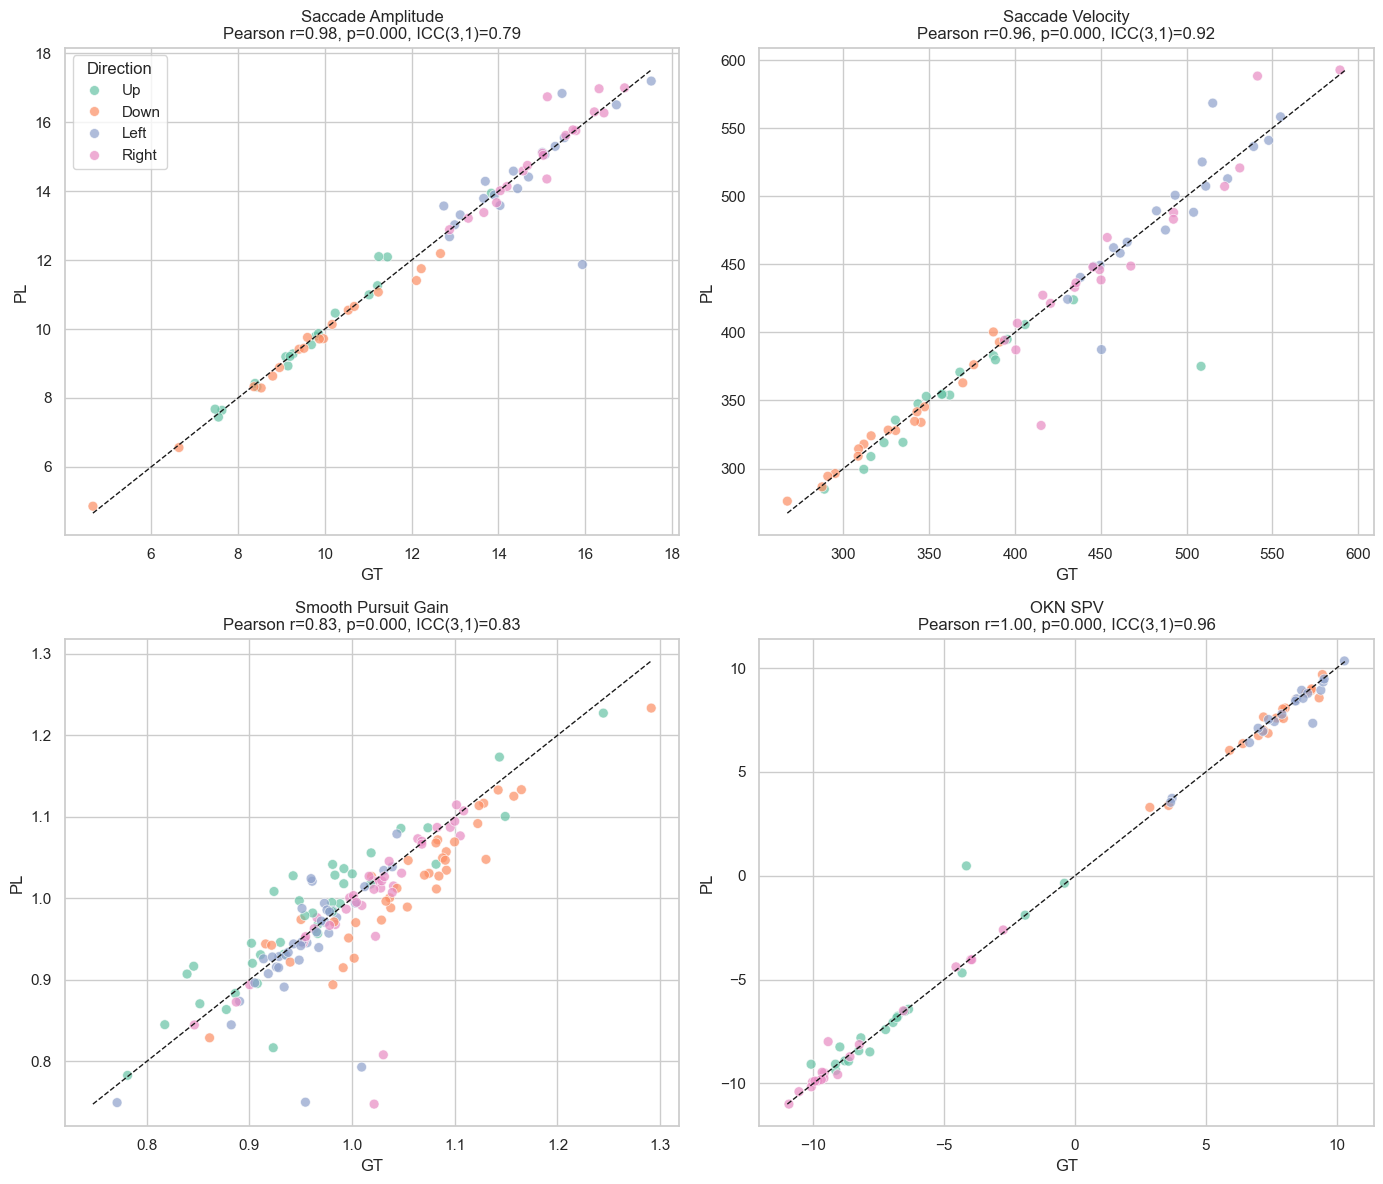

In [590]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr
import pingouin as pg

# --- Config ---
# exclude_idx = [7,17]
exclude_idx = []

plot_data = {
    "Saccade Amplitude": df_sac_amp_all.drop(index=exclude_idx),
    "Saccade Velocity": df_sac_vel_all.drop(index=exclude_idx),
    "Smooth Pursuit Gain": df_sm_all.drop(index=exclude_idx),
    "OKN SPV": df_okn_all.drop(index=exclude_idx)
}

directions_dict = {
    "Saccade Amplitude": ['up', 'down', 'left', 'right'],
    "Saccade Velocity": ['up', 'down', 'left', 'right'],
    "Smooth Pursuit Gain": ['slow_up', 'slow_down', 'slow_left', 'slow_right','fast_up', 'fast_down', 'fast_left', 'fast_right'],
    "OKN SPV": ['up', 'down', 'left', 'right']
}

palette = sns.color_palette("Set2", 4)
outlier_dict = {}

# --- Plotting ---
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.flatten()

for i, (title, df) in enumerate(plot_data.items()):
    directions = directions_dict[title]
    merged = []

    for dir_name in directions:
        gt_col = f'GT_{dir_name}'
        pl_col = f'PL_{dir_name}'
        if gt_col in df.columns and pl_col in df.columns:
            temp = df[[gt_col, pl_col]].dropna().copy()
            temp.columns = ['GT', 'PL']
            temp['Direction'] = dir_name.capitalize()
            temp['Sample'] = temp.index  #  track original sample
            merged.append(temp)

    df_merged = pd.concat(merged, ignore_index=True)

    # Scatter plot
    ax = axs[i]
    sns.scatterplot(data=df_merged, x='GT', y='PL', hue='Direction',
                    palette=palette, ax=ax, s=50, alpha=0.7)

    min_val = df_merged[['GT', 'PL']].min().min()
    max_val = df_merged[['GT', 'PL']].max().max()
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

    # Pearson & ICC
    r, p = pearsonr(df_merged['GT'], df_merged['PL'])
    df_icc = df_merged[['GT', 'PL']].copy()
    df_icc['subject'] = df_merged['Sample']
    df_long = df_icc.melt(id_vars='subject', var_name='rater', value_name='score')
    icc_val = pg.intraclass_corr(data=df_long, targets='subject', raters='rater', ratings='score') \
                .query("Type == 'ICC3'")['ICC'].values[0]

    ax.set_title(f"{title}\nPearson r={r:.2f}, p={p:.3f}, ICC(3,1)={icc_val:.2f}")
    ax.set_xlabel("GT")
    ax.set_ylabel("PL")
    ax.grid(True)

    if i == 0:
        ax.legend(title="Direction")
    else:
        ax.get_legend().remove()

    # --- Get top mismatches
    df_merged["abs_error"] = (df_merged["GT"] - df_merged["PL"]).abs()
    top_mismatches = df_merged.sort_values("abs_error", ascending=False).head(5)
    print(f"\nTop GT-PL mismatches in {title}:")
    print(top_mismatches[['Sample', 'GT', 'PL', 'Direction', 'abs_error']])

    outlier_dict[title] = top_mismatches['Sample'].tolist()

plt.tight_layout()
plt.show()

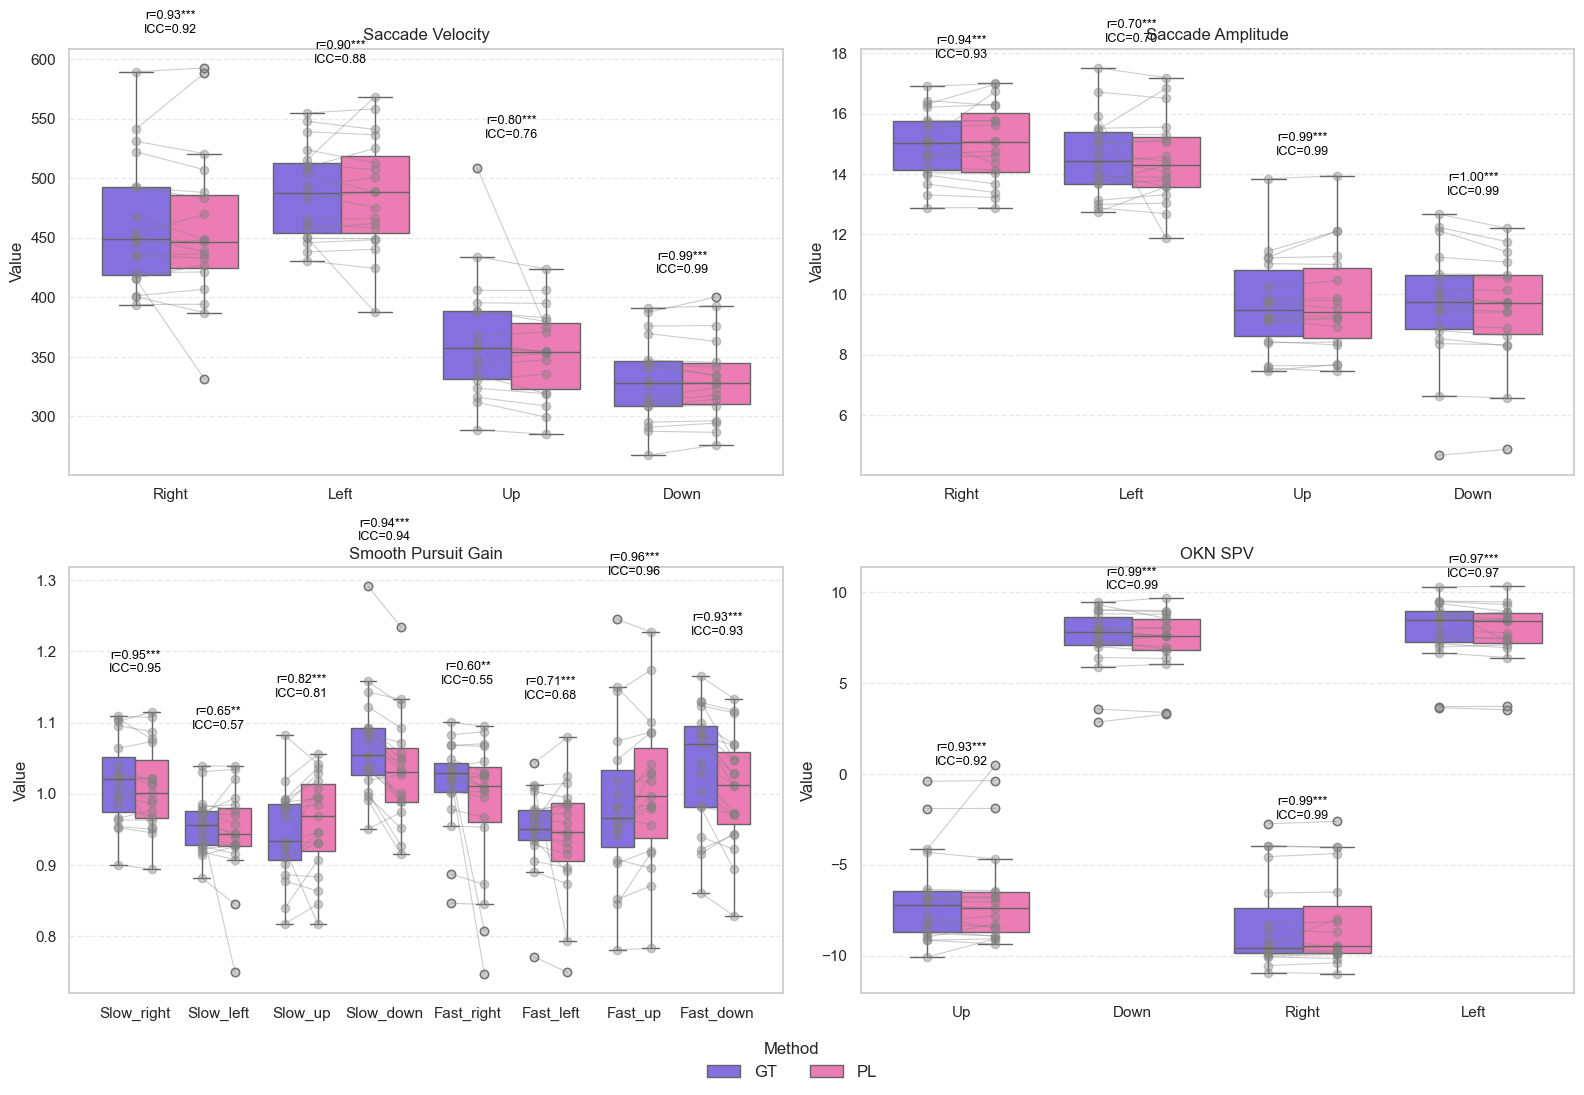

{'Saccade Velocity': {'Right': {'r': 0.9328240833570363,
   'p': 5.9037792945617964e-09,
   'icc3': 0.9190225599281564},
  'Left': {'r': 0.9043418902994376,
   'p': 1.0789517473172479e-07,
   'icc3': 0.8840973887366945},
  'Up': {'r': 0.7978228145568708,
   'p': 7.279554087829281e-05,
   'icc3': 0.7610081513628111},
  'Down': {'r': 0.9857481341400953,
   'p': 8.184639260044979e-14,
   'icc3': 0.9855390341942689}},
 'Saccade Amplitude': {'Right': {'r': 0.9383782168304485,
   'p': 2.889817216272518e-09,
   'icc3': 0.9280991042135611},
  'Left': {'r': 0.7048076739234356,
   'p': 0.0007525175464514933,
   'icc3': 0.70304578670281},
  'Up': {'r': 0.9901498658855226,
   'p': 4.320557864966806e-15,
   'icc3': 0.9874658373730544},
  'Down': {'r': 0.9957405885290571,
   'p': 5.3749601966026856e-18,
   'icc3': 0.9928838556465093}},
 'Smooth Pursuit Gain': {'Slow_right': {'r': 0.952450806427484,
   'p': 3.34831120439974e-10,
   'icc3': 0.9520465210112906},
  'Slow_left': {'r': 0.6518812925292066,

In [605]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import pingouin as pg

# --- Data config ---
plot_config = {
    "Saccade Velocity": (df_sac_vel_all, ['right', 'left', 'up', 'down']),
    "Saccade Amplitude": (df_sac_amp_all, ['right', 'left', 'up', 'down']),
    "Smooth Pursuit Gain": (df_sm_all, ['slow_right', 'slow_left', 'slow_up', 'slow_down', 'fast_right', 'fast_left', 'fast_up', 'fast_down']),
    "OKN SPV": (df_okn_all, ['up', 'down', 'right', 'left']),
}

# --- Custom color palette ---
custom_palette = {
    "GT": "#785EF0",  # Azumus (a violet-ish blue)
    "PL": "#FF69B4"   # Pink (Hot Pink)
}

# --- Plot setup ---
sns.set(style="whitegrid")
fig, axs = plt.subplots(2, 2, figsize=(16, 11))
axs = axs.flatten()

def find_low_correlation_indices(df_pair, top_k=5):
    diffs = (df_pair['GT'] - df_pair['PL']).abs()
    return diffs.sort_values(ascending=False).head(top_k).index.tolist()

def format_sigstar(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

corr_matrics = {}

for ax, (title, (df, metrics)) in zip(axs, plot_config.items()):
    all_data = []
    corr_matrics[title] = {}

    for m in metrics:
        gt_col, pl_col = f'GT_{m}', f'PL_{m}'
        if gt_col in df.columns and pl_col in df.columns:
            temp = df[[gt_col, pl_col]].dropna().copy()
            temp.columns = ['GT', 'PL']
            melted = temp.melt(var_name="Method", value_name="Value")
            melted["Direction"] = m.capitalize()
            melted["Original Index"] = temp.index.tolist() * 2
            all_data.append(melted)

    if all_data:
        df_plot = pd.concat(all_data, ignore_index=True)
        sns.boxplot(
            data=df_plot,
            x="Direction",
            y="Value",
            hue="Method",
            palette=custom_palette,
            ax=ax,
            showfliers=True
        )

        # Annotations per direction
        directions = df_plot["Direction"].unique()
        for i, d in enumerate(directions):
            sub_df = df_plot[df_plot["Direction"] == d]
            gt = sub_df[sub_df["Method"] == "GT"]["Value"].values
            pl = sub_df[sub_df["Method"] == "PL"]["Value"].values
            orig_idx = sub_df[sub_df["Method"] == "GT"]["Original Index"].values
            if len(gt) != len(pl):
                continue

            # Pearson + ICC
            r, p = pearsonr(gt, pl)
            df_temp = pd.DataFrame({'GT': gt, 'PL': pl, 'idx': orig_idx})
            df_long = df_temp.melt(id_vars='idx', var_name='rater', value_name='score')
            df_long['subject'] = df_long['idx']
            icc = pg.intraclass_corr(data=df_long, targets='subject', raters='rater', ratings='score')
            icc3 = icc.query("Type == 'ICC3'")['ICC'].values[0]

            # Low correlation samples
            corr_matrics[title][d] = {"r": r, "p": p, "icc3": icc3}

            # Text label
            text = f"r={r:.2f}{format_sigstar(p)}\nICC={icc3:.2f}"
            max_val = sub_df["Value"].max()
            ax.text(i, max_val + 0.05 * abs(max_val), text, ha='center', fontsize=9, color='black')

        # Connect samples with lines
        for direction in directions:
            dir_data = df_plot[df_plot['Direction'] == direction]
            for idx in dir_data['Original Index'].unique():
                pair = dir_data[dir_data['Original Index'] == idx]
                if len(pair) == 2:
                    gt_val = pair[pair['Method'] == 'GT']['Value'].values[0]
                    pl_val = pair[pair['Method'] == 'PL']['Value'].values[0]
                    xpos = list(df_plot['Direction'].unique()).index(direction)
                    ax.plot([xpos - 0.2, xpos + 0.2], [gt_val, pl_val], color='gray', alpha=0.4, linewidth=0.8, linestyle='-', marker='o')

        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("Value")
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)

# Global legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False, fontsize=12, title="Method")
for ax in axs:
    ax.legend_.remove()

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

corr_matrics

In [ ]:
def analyze_GT_vs_PL(df):
    from scipy.stats import pearsonr
    import pingouin as pg

    results = []
    # Match GT_... and PL_... columns
    gt_cols = [col for col in df.columns if col.startswith("GT_")]
    for gt_col in gt_cols:
        suffix = gt_col[3:]  # e.g., 'right', 'ver', etc.
        pl_col = f"PL_{suffix}"
        if pl_col not in df.columns:
            continue
        pair = df[[gt_col, pl_col]].dropna()
        n = len(pair)
        if n < 3:
            results.append({
                'metric': suffix,
                'n': n,
                'r': np.nan,
                'p': np.nan,
                'icc3': np.nan
            })
            continue
        # Pearson
        r, p = pearsonr(pair[gt_col], pair[pl_col])
        
        # ICC3
        df_icc = pair.rename(columns={gt_col: 'GT', pl_col: 'PL'}).reset_index()
        df_long = df_icc.melt(id_vars='index', var_name='rater', value_name='score')
        df_long['subject'] = df_long['index']
        icc_val = pg.intraclass_corr(
            data=df_long,
            targets='subject',
            raters='rater',
            ratings='score'
        ).query("Type == 'ICC3'")['ICC'].values[0]

        results.append({
            'metric': suffix,
            'n': n,
            'r': r,
            'p': p,
            'icc3': icc_val
        })

    return pd.DataFrame(results)

df_sac_amp_stats = analyze_GT_vs_PL(df_sac_amp_all).assign(domain='saccade_amplitude')
df_sac_vel_stats = analyze_GT_vs_PL(df_sac_vel_all).assign(domain='saccade_velocity')
df_sm_stats = analyze_GT_vs_PL(df_sm_all).assign(domain='smooth_pursuit')
df_okn_stats = analyze_GT_vs_PL(df_okn_all).assign(domain='okn_spv')
# df_sm_stats[df_sm_stats['metric'].isin(['hor', 'ver', 'left', 'right', 'up', 'down'])].drop(columns=['n'])
df_sac_amp_stats[df_sac_amp_stats['metric'].isin(['hor', 'ver', 'left', 'right', 'up', 'down'])].drop(columns=['n'])

,metric,r,p,icc3,domain
0,right,0.868970,1.381790e-06,0.839285,saccade_amplitude
1,left,0.653466,2.412344e-03,0.627499,saccade_amplitude
2,up,0.942955,1.523295e-09,0.937303,saccade_amplitude
3,down,0.986415,8.920041e-15,0.982829,saccade_amplitude
4,hor,0.461831,4.652635e-02,0.393533,saccade_amplitude
5,ver,0.973078,2.854821e-12,0.972860,saccade_amplitude


In [ ]:
# df_sac_amp_all.loc[:,['GT_hor', 'PL_hor']].dropna().corr(method='pearson').iloc[0, 1]
# df_sac_amp_all.loc[:, ['GT_hor', 'PL_hor']].corr()

,GT_hor,PL_hor
GT_hor,1.000000,0.461831
PL_hor,0.461831,1.000000


In [351]:
df_combined = pd.concat([
    df_okn_stats[df_okn_stats['metric'].isin(['hor', 'ver'])],
    df_sm_stats[df_sm_stats['metric'].isin(['hor', 'ver'])],
    df_sac_vel_stats[df_sac_vel_stats['metric'].isin(['hor', 'ver'])],
    df_sac_amp_stats[df_sac_amp_stats['metric'].isin(['hor', 'ver'])]
], ignore_index=True)

df_combined

,metric,n,r,p,icc3,domain
0,hor,19,0.991510,1.668424e-16,0.991474,okn_spv
1,ver,19,0.971598,4.476270e-12,0.968216,okn_spv
2,hor,19,0.400418,8.935276e-02,0.325853,smooth_pursuit
3,ver,19,0.925571,1.376447e-08,0.921636,smooth_pursuit
4,hor,19,0.606667,5.886658e-03,0.585403,saccade_velocity
5,ver,19,0.327232,1.714559e-01,0.243788,saccade_velocity
6,hor,19,0.461831,4.652635e-02,0.393533,saccade_amplitude
7,ver,19,0.973078,2.854821e-12,0.972860,saccade_amplitude


In [146]:
from scipy.stats import pearsonr
import pingouin as pg
import pandas as pd

# Drop NaNs for valid comparison
pair = df_sac_vel_all[['GT_up', 'PL_up']].dropna()

# Sample size check
n = len(pair)
print(f"Number of valid samples: {n}")

# Pearson correlation
r, p = pearsonr(pair['GT_up'], pair['PL_up'])
print(f"Pearson r: {r:.4f}, p-value: {p:.4g}")

# ICC(3,1)
df_icc = pair.rename(columns={'GT_up': 'GT', 'PL_up': 'PL'}).reset_index()
df_long = df_icc.melt(id_vars='index', var_name='rater', value_name='score')
df_long['subject'] = df_long['index']
icc_result = pg.intraclass_corr(
    data=df_long,
    targets='subject',
    raters='rater',
    ratings='score'
)
icc3 = icc_result.query("Type == 'ICC3'")['ICC'].values[0]
print(f"ICC(3,1): {icc3:.4f}")



Number of valid samples: 19
Pearson r: 0.4959, p-value: 0.03081
ICC(3,1): 0.4580


In [76]:
def analyze_GT_vs_PL_v2(df):
    from scipy.stats import pearsonr
    import pingouin as pg

    results = []
    cols = df.columns

    # Match all keys ending in _GT
    gt_keys = [col for col in cols if col.endswith('_GT')]
    
    for gt_key in gt_keys:
        pl_key = gt_key.replace('_GT', '_PL')
        if pl_key not in df.columns:
            continue

        pair = df[[gt_key, pl_key]].dropna()
        n = len(pair)

        if n < 3:
            results.append({
                'metric': gt_key.replace('_GT', ''),
                'n': n, 'r': np.nan, 'p': np.nan, 'icc3': np.nan
            })
            continue

        r, p = pearsonr(pair[gt_key], pair[pl_key])

        df_icc = pair.rename(columns={gt_key: 'GT', pl_key: 'PL'}).reset_index()
        df_long = df_icc.melt(id_vars='index', var_name='rater', value_name='score')
        df_long['subject'] = df_long['index']

        icc_val = pg.intraclass_corr(
            data=df_long,
            targets='subject',
            raters='rater',
            ratings='score'
        ).query("Type == 'ICC3'")['ICC'].values[0]

        results.append({
            'metric': gt_key.replace('_GT', ''),
            'n': n,
            'r': r,
            'p': p,
            'icc3': icc_val
        })
    return pd.DataFrame(results)
df_sm_stats      = analyze_GT_vs_PL(df_sm_all).assign(domain='smooth_pursuit')
df_okn_stats     = analyze_GT_vs_PL_v2(df_okn_all).assign(domain='optokinetic_nystagmus')
df_all_stats = pd.concat([df_sac_amp_stats, df_sac_vel_stats, df_sm_stats, df_okn_stats], ignore_index=True)
df_all_stats

,metric,n,r,p,icc3,domain
0,right,19.0,0.866443,1.610903e-06,0.837262,saccade_amplitude
1,left,19.0,0.652416,2.465065e-03,0.626601,saccade_amplitude
2,up,19.0,0.942598,1.604288e-09,0.936865,saccade_amplitude
3,down,19.0,0.986335,9.373831e-15,0.982923,saccade_amplitude
4,hor,19.0,0.455254,5.015671e-02,0.390591,saccade_amplitude
5,ver,19.0,0.979057,3.445817e-13,0.976006,saccade_amplitude
6,right,19.0,0.467027,4.380285e-02,0.173939,saccade_velocity
7,left,19.0,0.870762,1.237023e-06,0.478112,saccade_velocity
8,up,19.0,-0.124300,6.121537e-01,-0.046011,saccade_velocity
9,down,19.0,0.372699,1.160651e-01,0.191934,saccade_velocity


In [31]:
GT_root = r"D:\jzhao\DeepVOG-project\datasets\Gaze_EyeSeeCam\integrated\GT"
GT_trial_folders = glob.glob(os.path.join(GT_root, "*trial*"))
subjects = []
for GT_trial_folder in GT_trial_folders:
    subjects.append(os.path.basename(GT_trial_folder).split("_")[0])

In [ ]:
print("\n------ Results ------")
# for sub in marker_results:
#     for calib in marker_results[sub]:

# calib = "narrowranged"
calib = "calibME"
for sub in subjects:
    print(f"\nSubject: {sub} | Calibration: {calib}")
    print("--- Saccade: Amplitudes & Velocities ---")

    # Amplitudes
    print("\nAmplitude stats:")
    for lbl, stats in marker_results[sub][calib]['saccades']['amplitude'].items():
        print(f"{lbl:<10}: {stats['median']:.2f} (Q1–Q3: {stats['Q1']:.2f}–{stats['Q3']:.2f})")

    # Velocities
    print("\nVelocity stats:")
    for lbl, stats in marker_results[sub][calib]['saccades']['velocity'].items():
        print(f"{lbl:<10}: {stats:.2f}")

    # Smooth Pursuit Gains
    print("\n--- Smooth Pursuit Gains ---")
    sp = marker_results[sub][calib]['smooth_pursuit']
    for speed in ['slow', 'fast']:
        for axis in ['Hor', 'Ver']:
            x = sp.get(f"{axis}_{speed}_GT", np.nan)
            pl = sp.get(f"{axis}_{speed}_PL", np.nan)
            print(f"{axis} {speed.title():<5} | GT: {x:.2f} | PL: {pl:.2f}")

    print("\nDirectional Gains:")
    for direction in ['Right', 'Left', 'Up', 'Down']:
        for speed in ['slow', 'fast']:
            key = f"{direction}_{speed}"
            x = sp.get(f"{key}_GT", np.nan)
            pl = sp.get(f"{key}_PL", np.nan)
            print(f"{direction:<5} {speed:<5} | GT: {x:.2f} | PL: {pl:.2f}")

    # Optokinetic Nystagmus
    print("\n--- Optokinetic Nystagmus SPV ---")
    okn = marker_results[sub][calib]['optokinetic_nystagmus']
    for dirn in ['right', 'left', 'up', 'down']:
        x = okn.get(f"GT_{dirn}", np.nan)
        pl = okn.get(f"PL_{dirn}", np.nan)
        print(f"{dirn:<5} | GT: {x:.2f} | PL: {pl:.2f}")


------ Results ------

Subject: ekierig | Calibration: calibME
--- Saccade: Amplitudes & Velocities ---

Amplitude stats:
GT right  : 12.87 (Q1–Q3: 12.23–13.06)
GT left   : 15.52 (Q1–Q3: 15.30–15.63)
GT up     : 9.13 (Q1–Q3: 8.90–9.53)
GT down   : 9.42 (Q1–Q3: 8.90–9.84)
PL right  : 12.89 (Q1–Q3: 12.21–13.08)
PL left   : 15.56 (Q1–Q3: 15.31–15.71)
PL up     : 8.91 (Q1–Q3: 8.68–9.36)
PL down   : 9.43 (Q1–Q3: 8.90–9.74)

Velocity stats:
GT right  : 537.92
GT left   : 619.36
GT up     : 476.58
GT down   : 441.37
PL right  : 533.42
PL left   : 623.53
PL up     : 465.70
PL down   : 447.44

--- Smooth Pursuit Gains ---
Hor Slow  | GT: 0.97 | PL: 0.97
Ver Slow  | GT: 1.06 | PL: 1.06
Hor Fast  | GT: 0.96 | PL: 0.96
Ver Fast  | GT: 0.96 | PL: 0.94

Directional Gains:
Right slow  | GT: 1.02 | PL: 1.02
Right fast  | GT: 1.00 | PL: 0.99
Left  slow  | GT: 0.93 | PL: 0.93
Left  fast  | GT: 0.93 | PL: 0.93
Up    slow  | GT: 0.99 | PL: 1.05
Up    fast  | GT: 1.14 | PL: 1.17
Down  slow  | GT: 1.30 | P